# Proyecto final: Estimación del riesgo de diabetes en pacientes mexicanos
### Algoritmos de Aprendizaje Automático - Entrega final

**Autor:** Alan Adelfo Del Angel Figueroa (T02814389) - Universidad Tecmilenio Campus Cumbres

Este notebook tiene dos partes:

* **Parte I - Avance de proyecto (corregido).** Se conservan, sin cambios de contenido, todas las celdas del
  avance corregido (limpieza, EDA, fuga de información, partición por hogar, baseline, modelos iniciales, umbral,
  interpretabilidad y trazabilidad). Así la entrega final parte exactamente de la línea base anterior.
  El único cambio es agregar la ruta `../data/Diabetes_Mexico.csv` a la lista de rutas de búsqueda del archivo.
* **Parte II - Entrega final.** Verificación del avance, bitácora de cambios, pipeline consolidado, ingeniería de
  características, validación cruzada repetida, ensamble, SVM, selección de características, ajuste de
  hiperparámetros, registro de experimentos, selección y evaluación del modelo final, umbral, interpretabilidad,
  sesgos, riesgos, serialización, inferencia con validación de entradas, monitoreo, trazabilidad y ficha del modelo.

El problema, el dataset, la variable objetivo (`riesgo_diabetes_cat`: 0 = bajo, 1 = moderado, 2 = alto) y el
criterio de éxito (detectar el **riesgo alto** sin usar la glucosa ni la HbA1c, superando claramente al
`DummyClassifier`) son los mismos del avance.


# Parte I. Avance de Proyecto (corregido): Estimación del riesgo de diabetes en pacientes mexicanos
### Algoritmos de Aprendizaje Automático

Dataset: `Diabetes_Mexico.csv` (adaptación de encuesta nacional de salud, tipo ENSANUT)

**Versión corregida:** interpretación de `riesgo_diabetes_cat` alineada con el glosario oficial
(0 = bajo, 1 = moderado, 2 = alto) y modelo mejorado (ver sección de correcciones más abajo).

## Selección del conjunto de datos

| Elemento | Información |
|---|---|
| Nombre del dataset | Diabetes_Mexico.csv |
| Fuente | Encuesta de salud de tipo poblacional en México (estructura compatible con ENSANUT), proporcionada para fines académicos del curso |
| Liga de acceso | Archivo proporcionado por la institución educativa (uso académico) |
| Fecha de consulta | 01 de septiembre de 2026 |
| Número de observaciones | 2,549 registros (2,055 hogares distintos) |
| Número de variables | 24 variables originales |
| Formato original del archivo | CSV (valores separados por comas, con notación decimal en coma en algunas columnas) |
| Variable objetivo | `riesgo_diabetes_cat` (**0 = riesgo bajo, 1 = riesgo moderado, 2 = riesgo alto**) |

El dataset cumple con las condiciones necesarias: incluye una variable objetivo categórica
relacionada con el riesgo de diabetes, contiene variables numéricas y categóricas, tiene
suficientes registros para particionar en entrenamiento/validación/prueba, permite procesos
de limpieza, codificación y escalamiento, y cuenta con variables clínicamente relacionadas con
el riesgo metabólico de un paciente.

## Pregunta de análisis

> **¿Cómo pueden utilizarse los datos demográficos, antropométricos y bioquímicos
> complementarios de los pacientes para estimar su nivel de riesgo de diabetes (bajo, moderado
> o alto) bajo las condiciones clínicas más relevantes consideradas, sin depender directamente
> del resultado del examen de glucosa, de manera que se apoyen acciones de priorización y
> prevención mediante un modelo reproducible de aprendizaje automático?**

La pregunta conserva el enfoque en clasificación (multiclase), en riesgo de una condición de
salud, en apoyo a la toma de decisiones (priorización en vez de decisiones automáticas) y en
reproducibilidad (semilla fija, pipeline documentado, particiones registradas).

## Correcciones y mejoras de esta versión

**Correcciones**

1. **Significado de la variable objetivo.** `riesgo_diabetes_cat` se interpretaba como
   *0 = sin riesgo, 1 = diagnosticado, 2 = en riesgo*. Según el glosario, la interpretación correcta es
   **0 = riesgo bajo, 1 = riesgo moderado, 2 = riesgo alto**. Se corrigieron etiquetas, gráficas, tablas,
   reportes y textos interpretativos.
2. **Glosario de variables** incorporado al notebook (`sexo`, `folio_i`, `folio_int`, `muestra_suero`, etc.).
3. **Umbral de glucosa.** El texto anterior decía "sin riesgo = glucosa ≤ 100". En los datos, el riesgo
   bajo llega como máximo a 99 mg/dL y el valor 100 ya pertenece al riesgo alto (umbral **≥ 100**).
4. **Valor centinela en `edad`.** Existen 4 registros con `edad = -7975` (código de dato faltante). Antes
   solo se ocultaban en un histograma, pero **seguían entrando al modelo** y distorsionaban la mediana
   y el escalamiento. Ahora se convierten en `NaN` y se imputan dentro del pipeline.
5. **Ruta del archivo** con búsqueda de varias ubicaciones (Colab o carpeta local).
6. **Matriz de confusión** completa de 3×3 (antes el código solo mostraba las clases 0 y 2).
7. **Análisis de umbral** enfocado en la clase de interés (riesgo alto vs. resto), usando la
   probabilidad de la clase 2 en lugar de "algún riesgo".

**Mejoras**

1. **Partición agrupada por hogar** (`folio_i` identifica al hogar): personas de un mismo hogar comparten
   hábitos y entorno; si quedaran repartidas entre entrenamiento y prueba se inflaría el desempeño.
2. **Validación cruzada estratificada y agrupada** (5 pliegues) para comparar modelos con más
   estabilidad, ya que el conjunto de validación tiene solo 1 caso de riesgo moderado.
3. Se agregan **Random Forest** y **Gradient Boosting** a los modelos iniciales.
4. **Ablación de variables:** ¿cuánto aportan las variables baratas (edad, sexo, IMC) frente a
   los bioquímicos? Es la pregunta central del proyecto.
5. **Interpretabilidad** con los coeficientes de la regresión logística.
6. **Trazabilidad**: versiones de librerías y semilla.

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve,
                              ConfusionMatrixDisplay, classification_report)

import sklearn

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams.update({'font.size': 11})
sns.set_style('whitegrid')

# Interpretación CORRECTA de la variable objetivo (según glosario)
ETIQ = {0: 'Bajo', 1: 'Moderado', 2: 'Alto'}
ORDEN = [0, 1, 2]
NOMBRES_CLASES = [ETIQ[i] for i in ORDEN]
PAL = {'Bajo': '#4C9F70', 'Moderado': '#E8A33D', 'Alto': '#D9534F'}

## Glosario de variables

Significado de cada variable según el glosario del dataset. La columna *Rol* indica cómo se usa en este
proyecto y se justifica en las secciones siguientes.

Nota sobre `sexo`: el glosario lo describe como 1 = masculino, 2 = femenino, pero el archivo CSV ya
trae el texto "Hombre"/"Mujer". La limpieza acepta ambas versiones.

In [2]:
glosario = pd.DataFrame([
    ['folio_i',      'Identificador único del hogar',                          'Identificador / grupo de partición'],
    ['folio_int',    'Identificador único del individuo',                      'Identificador (se excluye)'],
    ['sexo',         'Sexo del individuo (1 = masculino, 2 = femenino)',       'Predictora'],
    ['edad',         'Edad en años',                                           'Predictora'],
    ['Ciudad',       'Ciudad de residencia (267 categorías)',                  'Se excluye (alta cardinalidad); se usa entidad_cve'],
    ['Peso',         'Peso corporal (kg)',                                     'Auxiliar para calcular imc_calc'],
    ['Estatura',     'Estatura (cm)',                                          'Auxiliar para calcular imc_calc'],
    ['imc',          'Índice de masa corporal (original, casi vacío)',         'Se excluye; se recalcula como imc_calc'],
    ['muestra_suero','Se tomó muestra de suero (1 = sí, 0 = no)',              'Se excluye (constante = 1)'],
    ['ac_urico',     'Nivel de ácido úrico en sangre',                         'Predictora'],
    ['albu',         'Concentración de albúmina en sangre',                    'Predictora'],
    ['col_hdl',      'Nivel de colesterol HDL',                                'Predictora'],
    ['col_ldl',      'Nivel de colesterol LDL',                                'Predictora'],
    ['colest',       'Nivel de colesterol total',                              'Predictora'],
    ['creat',        'Nivel de creatinina',                                    'Predictora'],
    ['glu_suero',    'Concentración de glucosa en suero',                      'Se excluye (fuga de información)'],
    ['insulina',     'Nivel de insulina en sangre',                            'Predictora'],
    ['trig',         'Nivel de triglicéridos',                                 'Predictora'],
    ['hb1ac',        'Hemoglobina glucosilada (HbA1c)',                        'Se excluye (fuga de información, 90% faltante)'],
    ['ponde_venosa', 'Ponderador de muestra venosa',                           'Se excluye (diseño muestral)'],
    ['estrato',      'Estrato muestral',                                       'Se excluye (diseño muestral)'],
    ['est_sel',      'Unidad primaria de muestreo',                            'Se excluye (diseño muestral)'],
    ['ponde_hemo',   'Ponderador de muestra de hemoglobina',                   'Se excluye (diseño muestral)'],
    ['riesgo_diabetes_cat', 'Categoría de riesgo de diabetes: 0 = bajo, 1 = moderado, 2 = alto', 'OBJETIVO'],
], columns=['Variable', 'Significado', 'Rol en el proyecto'])
glosario

,Variable,Significado,Rol en el proyecto
0,folio_i,Identificador único del hogar,Identificador / grupo de partición
1,folio_int,Identificador único del individuo,Identificador (se excluye)
2,sexo,"Sexo del individuo (1 = masculino, 2 = femenino)",Predictora
3,edad,Edad en años,Predictora
4,Ciudad,Ciudad de residencia (267 categorías),Se excluye (alta cardinalidad); se usa entidad...
5,Peso,Peso corporal (kg),Auxiliar para calcular imc_calc
6,Estatura,Estatura (cm),Auxiliar para calcular imc_calc
7,imc,"Índice de masa corporal (original, casi vacío)",Se excluye; se recalcula como imc_calc
8,muestra_suero,"Se tomó muestra de suero (1 = sí, 0 = no)",Se excluye (constante = 1)
9,ac_urico,Nivel de ácido úrico en sangre,Predictora


## Carga y exploración inicial

In [3]:
# Busca el archivo en Colab (/content), en la carpeta actual o en la carpeta de subidas
RUTAS = ['/content/Diabetes_Mexico.csv', 'Diabetes_Mexico.csv', '../data/Diabetes_Mexico.csv',
         'data/Diabetes_Mexico.csv', '/mnt/user-data/uploads/Diabetes_Mexico.csv']
ruta = next((r for r in RUTAS if os.path.exists(r)), None)
if ruta is None:
    raise FileNotFoundError(f"No se encontró Diabetes_Mexico.csv en: {RUTAS}")

df = pd.read_csv(ruta)
print("Archivo cargado desde:", ruta)
print("Dimensiones (filas, columnas):", df.shape)
df.head()

Archivo cargado desde: Diabetes_Mexico.csv
Dimensiones (filas, columnas): (2549, 24)


,folio_i,folio_int,sexo,edad,Ciudad,Peso,Estatura,imc,muestra_suero,ac_urico,...,creat,glu_suero,insulina,trig,hb1ac,ponde_venosa,estrato,est_sel,ponde_hemo,riesgo_diabetes_cat
0,2024_01001010,2024_01001010_01,Mujer,89.0,AGUASCALIENTES,NaN,NaN,NaN,1.0,"4,1",...,"0,62",166.0,"4,7",107.0,NaN,"2245,917738",3.0,13.0,"2888,530238",2
1,2024_01001012,2024_01001012_01,Mujer,71.0,AGUASCALIENTES,NaN,NaN,32.0,1.0,"4,3",...,"0,64",98.0,"9,6",132.0,NaN,"2245,917738",3.0,13.0,"2888,530238",1
2,2024_01001016,2024_01001016_02,Mujer,57.0,AGUASCALIENTES,"80,25","170,6",NaN,1.0,"4,9",...,"0,6",128.0,"4,7",263.0,6.0,"4047,445276",3.0,13.0,NaN,2
3,2024_01001016,2024_01001016_05,Mujer,20.0,AGUASCALIENTES,"68,6","166,2",NaN,1.0,"4,9",...,"0,63",112.0,"10,1",238.0,NaN,"13079,14232",3.0,13.0,"13776,80526",2
4,2024_01001031,2024_01001031_01,Hombre,74.0,AGUASCALIENTES,NaN,NaN,NaN,1.0,"6,4",...,"1,09",97.0,"10,2",135.0,NaN,"5292,158204",3.0,13.0,"5824,779445",0


In [4]:
df.tail()

,folio_i,folio_int,sexo,edad,Ciudad,Peso,Estatura,imc,muestra_suero,ac_urico,...,creat,glu_suero,insulina,trig,hb1ac,ponde_venosa,estrato,est_sel,ponde_hemo,riesgo_diabetes_cat
2544,2024_32056012,2024_32056012_01,Mujer,66.0,ZACATECAS,NaN,NaN,NaN,1.0,"4,8",...,"0,72",89.0,"6,4",179.0,NaN,"6532,590705",3.0,323.0,"9897,955004",0
2545,2024_32056022,2024_32056022_02,Mujer,51.0,ZACATECAS,"97,6","171,2",NaN,1.0,"5,8",...,"0,69",98.0,"35,2",126.0,NaN,"13055,89557",3.0,323.0,NaN,0
2546,2024_32056024,2024_32056024_01,Hombre,45.0,ZACATECAS,"90,95","172,4",NaN,1.0,"6,7",...,"0,82",94.0,"17,8",119.0,NaN,"6394,811934",3.0,323.0,NaN,0
2547,2024_32056024,2024_32056024_02,Mujer,38.0,ZACATECAS,"69,3","152,8",NaN,1.0,"4,6",...,"0,56",88.0,"10,7",132.0,5.0,"13189,49573",3.0,323.0,"20012,01206",0
2548,2024_32056029,2024_32056029_01,Hombre,44.0,ZACATECAS,"76,85","164,4",NaN,1.0,"6,5",...,"0,67",136.0,"3,7",73.0,NaN,"63723,9608",3.0,323.0,NaN,2


In [5]:
print("Nombres de columnas:")
print(list(df.columns))
print()
print("Tipos de datos detectados al cargar:")
print(df.dtypes)

Nombres de columnas:
['folio_i', 'folio_int', 'sexo', 'edad', 'Ciudad', 'Peso', 'Estatura', 'imc', 'muestra_suero', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest', 'creat', 'glu_suero', 'insulina', 'trig', 'hb1ac', 'ponde_venosa', 'estrato', 'est_sel', 'ponde_hemo', 'riesgo_diabetes_cat']

Tipos de datos detectados al cargar:
folio_i                    str
folio_int                  str
sexo                       str
edad                   float64
Ciudad                     str
Peso                       str
Estatura                   str
imc                    float64
muestra_suero          float64
ac_urico                   str
albu                       str
col_hdl                    str
col_ldl                float64
colest                 float64
creat                      str
glu_suero              float64
insulina                   str
trig                   float64
hb1ac                  float64
ponde_venosa               str
estrato                float64
est_sel          

In [6]:
print("Número de valores únicos por variable:")
print(df.nunique())

Número de valores únicos por variable:
folio_i                2055
folio_int              2549
sexo                      2
edad                     77
Ciudad                  267
Peso                    961
Estatura                413
imc                      17
muestra_suero             1
ac_urico                 89
albu                     44
col_hdl                  72
col_ldl                 171
colest                  228
creat                   148
glu_suero               241
insulina                400
trig                    381
hb1ac                     8
ponde_venosa           2294
estrato                   3
est_sel                  91
ponde_hemo             1480
riesgo_diabetes_cat       3
dtype: int64


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
folio_i,2549,2055,2024_01001016,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
folio_int,2549,2549,2024_01001010_01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sexo,2549,2,Mujer,1547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,2524.0,NaN,NaN,NaN,35.763074,319.672846,-7975.0,34.0,47.5,62.0,95.0
Ciudad,2549,267,AGUASCALIENTES,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Peso,1829,961,"222,22",11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estatura,1829,413,157,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imc,35.0,NaN,NaN,NaN,29.971429,7.633077,15.0,25.0,30.0,32.5,56.0
muestra_suero,2549.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ac_urico,2549,89,"4,8",95,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
print("Valores faltantes por columna:")
print(df.isna().sum())
print()
print("Registros duplicados (fila completa):", df.duplicated().sum())
print("folio_int (individuo) es único:", df['folio_int'].is_unique)
print("Hogares distintos (folio_i):", df['folio_i'].nunique())
print("Filas que comparten hogar con otra persona (folio_i repetido):", df['folio_i'].duplicated().sum())

Valores faltantes por columna:
folio_i                   0
folio_int                 0
sexo                      0
edad                     25
Ciudad                    0
Peso                    720
Estatura                720
imc                    2514
muestra_suero             0
ac_urico                  0
albu                      0
col_hdl                   0
col_ldl                   0
colest                    0
creat                     0
glu_suero                 0
insulina                  0
trig                      0
hb1ac                  2308
ponde_venosa             99
estrato                   0
est_sel                   0
ponde_hemo              980
riesgo_diabetes_cat       0
dtype: int64

Registros duplicados (fila completa): 0
folio_int (individuo) es único: True
Hogares distintos (folio_i): 2055
Filas que comparten hogar con otra persona (folio_i repetido): 494


In [9]:
print("Distribución de la variable objetivo (0 = bajo, 1 = moderado, 2 = alto):")
cnt = df['riesgo_diabetes_cat'].value_counts().sort_index()
pd.DataFrame({'Categoría': [ETIQ[i] for i in cnt.index],
              'Cantidad': cnt.values,
              'Proporción (%)': (cnt.values / len(df) * 100).round(2)}, index=cnt.index)

Distribución de la variable objetivo (0 = bajo, 1 = moderado, 2 = alto):


,Categoría,Cantidad,Proporción (%)
riesgo_diabetes_cat,,,
0,Bajo,1697,66.58
1,Moderado,12,0.47
2,Alto,840,32.95


## Análisis de la calidad de los datos

In [10]:
# 1) Conversión de columnas numéricas almacenadas como texto (coma decimal)
coma_cols = ['Peso','Estatura','ac_urico','albu','col_hdl','creat','insulina','ponde_venosa','ponde_hemo']
for c in coma_cols:
    df[c] = df[c].astype(str).str.replace(',', '.', regex=False)
    df[c] = pd.to_numeric(df[c], errors='coerce')

# 2) Edad: valores fuera de un rango razonable (p. ej. -7975, código de dato faltante) -> NaN
edad_invalida = (df['edad'] < 0) | (df['edad'] > 120)
print("Edades inválidas convertidas a NaN:", int(edad_invalida.sum()), "->", sorted(float(v) for v in df.loc[edad_invalida, 'edad'].unique()))
df.loc[edad_invalida, 'edad'] = np.nan

# 3) Sexo: acepta 1/2 (glosario) o Hombre/Mujer (archivo)
sexo_map = {'1': 'Hombre', '1.0': 'Hombre', '2': 'Mujer', '2.0': 'Mujer', 'Hombre': 'Hombre', 'Mujer': 'Mujer'}
df['sexo'] = df['sexo'].astype(str).map(sexo_map)
assert df['sexo'].notna().all(), "Hay valores de sexo no reconocidos"

# 4) IMC recalculado (la variable original tiene 98.6% de valores faltantes)
df['imc_calc'] = df['Peso'] / (df['Estatura']/100)**2

# 5) Entidad federativa extraída del folio (sustituye a Ciudad, con demasiadas categorías)
df['entidad_cve'] = df['folio_i'].astype(str).str.split('_').str[1].str[:2]

print("\nConversión completada.")
print(df[coma_cols + ['imc_calc','entidad_cve','sexo','edad']].dtypes)
print("\nRango de edad tras la limpieza:", df['edad'].min(), "-", df['edad'].max())

Edades inválidas convertidas a NaN: 4 -> [-7975.0]

Conversión completada.
Peso            float64
Estatura        float64
ac_urico        float64
albu            float64
col_hdl         float64
creat           float64
insulina        float64
ponde_venosa    float64
ponde_hemo      float64
imc_calc        float64
entidad_cve      object
sexo                str
edad            float64
dtype: object

Rango de edad tras la limpieza: 20.0 - 95.0


No se eliminan registros del dataset: los problemas identificados se resuelven mediante
conversión de tipos, sustitución de códigos inválidos por valores faltantes, imputación dentro
del pipeline y selección justificada de columnas.

## Análisis exploratorio de datos

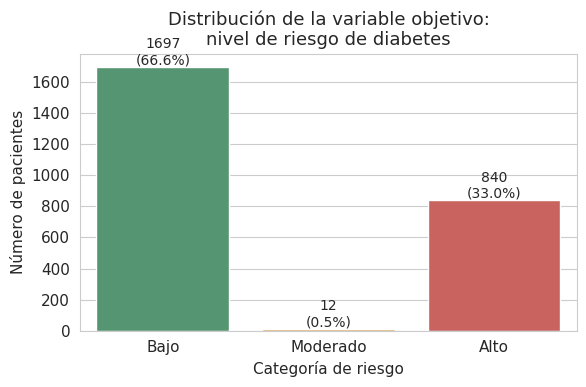

In [11]:
df['riesgo_label'] = df['riesgo_diabetes_cat'].map(ETIQ)

plt.figure(figsize=(6,4))
counts = df['riesgo_diabetes_cat'].value_counts().reindex(ORDEN)
ax = sns.barplot(x=NOMBRES_CLASES, y=counts.values, hue=NOMBRES_CLASES, palette=PAL, legend=False)
for i, v in enumerate(counts.values):
    ax.text(i, v+15, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=10)
plt.title('Distribución de la variable objetivo:\nnivel de riesgo de diabetes', fontsize=13)
plt.ylabel('Número de pacientes')
plt.xlabel('Categoría de riesgo')
plt.tight_layout()
plt.show()

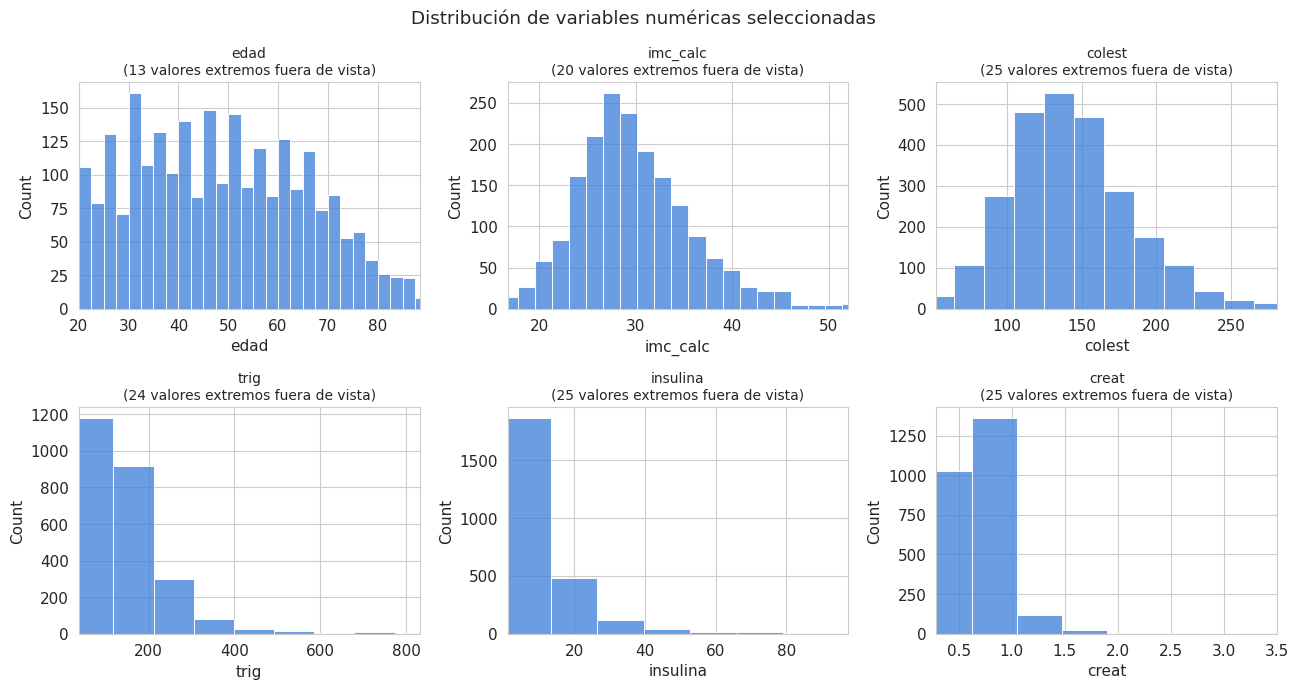

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(13,7))
plot_vars = ['edad','imc_calc','colest','trig','insulina','creat']

for ax, col in zip(axes.flat, plot_vars):
    serie = df[col].dropna()

    # Recorte de la vista a los percentiles 0.5 y 99.5 para que valores extremos aislados
    # no aplasten la forma de la distribución (los datos no se eliminan).
    low, high = serie.quantile([0.005, 0.995])
    n_excluidos = ((serie < low) | (serie > high)).sum()

    sns.histplot(serie, bins=30, ax=ax, color='#3B7DD8')
    ax.set_xlim(low, high)
    ax.set_title(f"{col}" + (f"\n({n_excluidos} valores extremos fuera de vista)" if n_excluidos > 0 else ""),
                 fontsize=10)

plt.suptitle('Distribución de variables numéricas seleccionadas')
plt.tight_layout()
plt.show()

La edad ya no muestra el valor centinela (-7975) tras la limpieza y cubre un rango amplio propio de
una encuesta poblacional de adultos. El IMC recalculado se concentra entre 25 y 33 kg/m²
(sobrepeso y obesidad), consistente con un perfil de riesgo metabólico. Triglicéridos e insulina
muestran sesgo hacia la derecha (colas largas de valores altos), típico de marcadores bioquímicos.

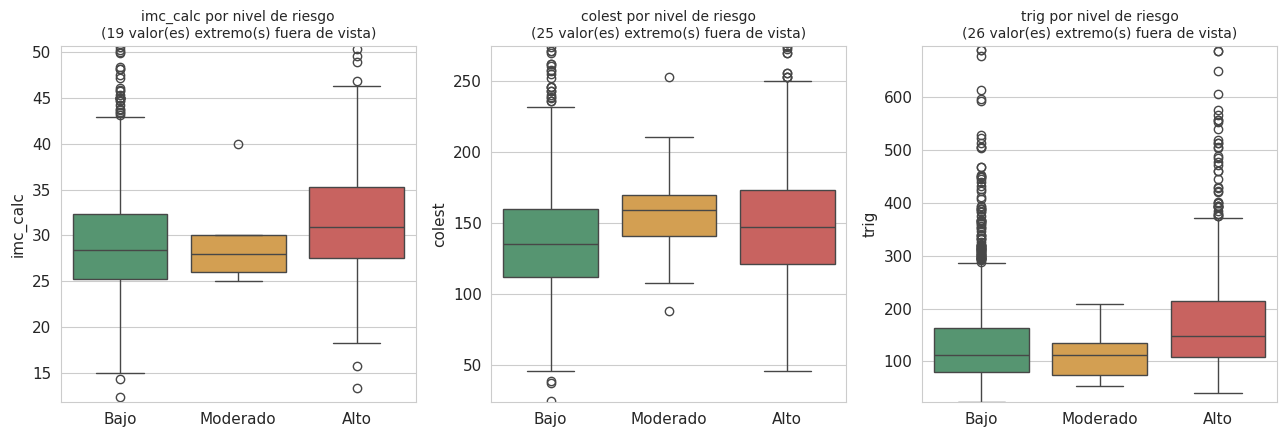

Medianas por nivel de riesgo:


,imc_calc,colest,trig
riesgo_label,,,
Bajo,28.4,135.0,113.0
Moderado,28.0,159.5,111.5
Alto,30.9,147.0,149.0


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13,4.5))
box_vars = ['imc_calc','colest','trig']

for ax, col in zip(axes, box_vars):
    sns.boxplot(x='riesgo_label', y=col, hue='riesgo_label', data=df, ax=ax,
                order=NOMBRES_CLASES, palette=PAL, legend=False)

    # Recorte del eje Y al percentil 99 para que valores extremos aislados
    # no aplasten la caja donde está la mayoría de los datos.
    # El dato original no se elimina del análisis, solo se ajusta la vista.
    low = df[col].quantile(0.0)
    high = df[col].quantile(0.99)
    n_excluidos = (df[col] > high).sum()
    ax.set_ylim(max(low, 0) * 0.95, high * 1.05)

    titulo = f'{col} por nivel de riesgo'
    if n_excluidos > 0:
        titulo += f'\n({n_excluidos} valor(es) extremo(s) fuera de vista)'
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

print("Medianas por nivel de riesgo:")
df.groupby('riesgo_label')[box_vars].median().reindex(NOMBRES_CLASES).round(1)

El grupo de **riesgo alto** muestra medianas más altas que el de **riesgo bajo** en IMC (30.9 vs. 28.4 kg/m²),
colesterol total (147 vs. 135 mg/dL) y triglicéridos (149 vs. 113 mg/dL), lo cual es consistente con la
literatura clínica sobre síndrome metabólico; la diferencia más marcada es la de triglicéridos. La superposición
entre grupos es considerable, por lo que estas variables por sí solas no separan las clases: se requiere un
modelo que combine varias señales a la vez. El grupo de riesgo moderado tiene solo 12 pacientes, por lo que su caja
no es estadísticamente confiable.

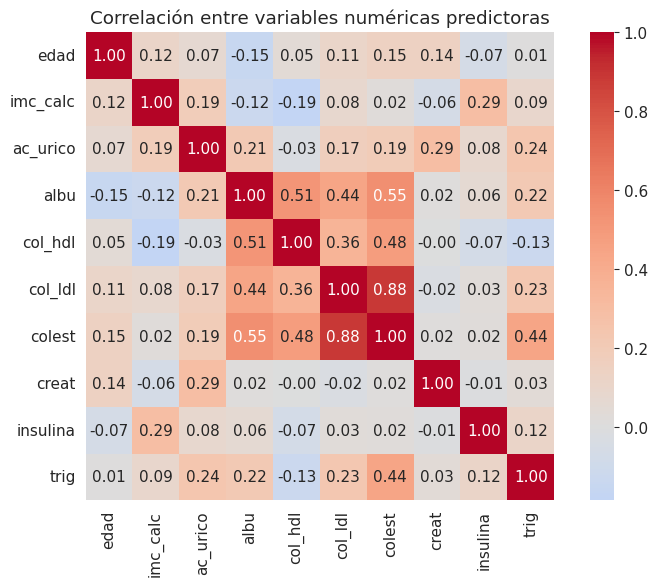

In [14]:
plt.figure(figsize=(8,6))
num_cols_eda = ['edad','imc_calc','ac_urico','albu','col_hdl','col_ldl','colest','creat','insulina','trig']
corr = df[num_cols_eda].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlación entre variables numéricas predictoras')
plt.tight_layout()
plt.show()

Proporción porcentual de pacientes por sexo:
sexo
Mujer     60.69
Hombre    39.31
Name: proportion, dtype: float64 




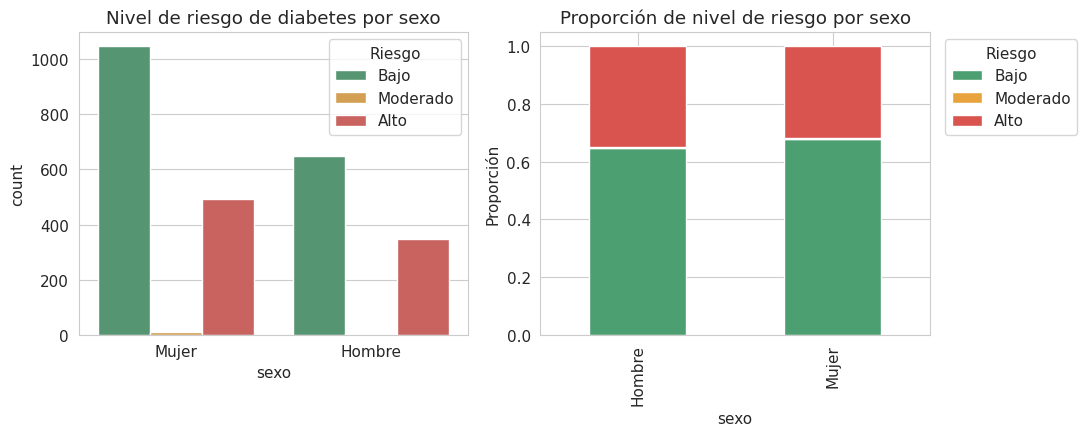

In [15]:
print("Proporción porcentual de pacientes por sexo:")
print((df['sexo'].value_counts(normalize=True)*100).round(2), "\n\n")

fig, axes = plt.subplots(1,2, figsize=(11,4.5))
sns.countplot(x='sexo', hue='riesgo_label', hue_order=NOMBRES_CLASES,
              data=df, ax=axes[0], palette=PAL)
axes[0].set_title('Nivel de riesgo de diabetes por sexo')
axes[0].legend(title='Riesgo')
prop = pd.crosstab(df['sexo'], df['riesgo_label'], normalize='index')[NOMBRES_CLASES]
prop.plot(kind='bar', stacked=True, ax=axes[1], color=[PAL[n] for n in NOMBRES_CLASES])
axes[1].set_title('Proporción de nivel de riesgo por sexo')
axes[1].set_ylabel('Proporción')
axes[1].legend(title='Riesgo', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:
# ¿Los faltantes de Peso/Estatura están relacionados con el nivel de riesgo?
faltantes = (df[['Peso','Estatura','imc_calc','edad']].isna()
             .groupby(df['riesgo_label']).mean().mul(100).round(1)
             .reindex(NOMBRES_CLASES))
faltantes.columns = ['% sin Peso','% sin Estatura','% sin IMC calculable','% sin edad']
faltantes

,% sin Peso,% sin Estatura,% sin IMC calculable,% sin edad
riesgo_label,,,,
Bajo,21.9,21.9,21.9,1.1
Moderado,25.0,25.0,25.0,0.0
Alto,41.1,41.1,41.1,1.2


**Faltantes informativos.** La proporción de pacientes sin peso/estatura (y por tanto sin IMC) es
claramente mayor en el grupo de riesgo alto que en el de riesgo bajo. Esto probablemente refleja una
característica del levantamiento (por ejemplo, personas a quienes no se les pudo medir) y no una condición
clínica, por lo que **no se usa el indicador de "dato faltante" como predictora**: el modelo aprendería un
artefacto de la encuesta. Los faltantes se imputan con la mediana dentro del pipeline, y se documenta la
limitación: el IMC imputado es menos informativo para estos pacientes.

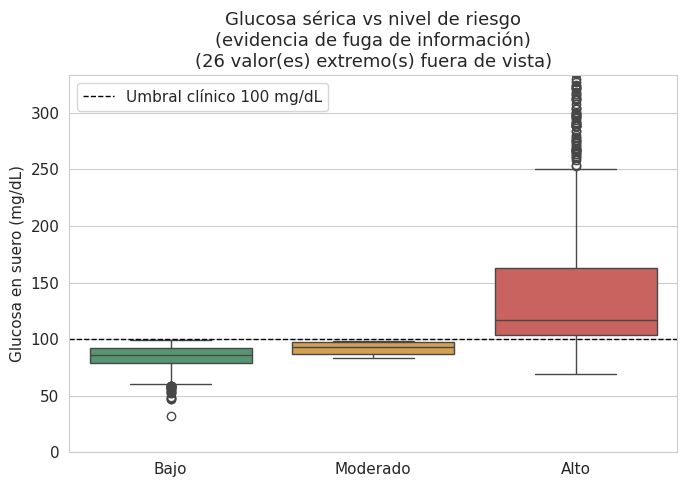

In [17]:
plt.figure(figsize=(7,5))
sns.boxplot(x='riesgo_label', y='glu_suero', hue='riesgo_label', data=df,
            order=NOMBRES_CLASES, palette=PAL, legend=False)

# Recorte del eje Y al percentil 99 para que un valor extremo aislado
# no aplaste la vista del umbral clínico. El dato original no se
# elimina del análisis, solo se ajusta el rango visible.
high = df['glu_suero'].quantile(0.99)
n_excluidos = (df['glu_suero'] > high).sum()
plt.ylim(0, high * 1.05)

plt.axhline(100, color='black', linestyle='--', linewidth=1, label='Umbral clínico 100 mg/dL')
titulo = 'Glucosa sérica vs nivel de riesgo\n(evidencia de fuga de información)'
if n_excluidos > 0:
    titulo += f'\n({n_excluidos} valor(es) extremo(s) fuera de vista)'
plt.title(titulo, fontsize=13)
plt.ylabel('Glucosa en suero (mg/dL)')
plt.xlabel('')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación (relevante para la sección de fuga de información).** **Todas** las personas de
riesgo **bajo** tienen glucosa sérica menor a 100 mg/dL (máximo 99), los 12 pacientes de riesgo **moderado**
también están por debajo de 100 (83 a 98 mg/dL) y la gran mayoría de las personas de riesgo **alto**
(96%) tiene glucosa de 100 mg/dL o más. Esto evidencia que la variable objetivo fue construida, en gran
medida, a partir de un umbral clínico directo sobre `glu_suero`. Esta observación es la base del análisis de
fuga de información y de la decisión de excluir `glu_suero` (y `hb1ac`, por la misma lógica diagnóstica)
del conjunto de predictoras.

## Revisión del desbalance de clases

In [18]:
counts = df['riesgo_diabetes_cat'].value_counts().sort_index()
props = df['riesgo_diabetes_cat'].value_counts(normalize=True).sort_index()
balance_tbl = pd.DataFrame({'Cantidad': counts, 'Proporción (%)': (props*100).round(2)})
balance_tbl.index = [f'{ETIQ[i]} ({i})' for i in balance_tbl.index]
balance_tbl

,Cantidad,Proporción (%)
Bajo (0),1697,66.58
Moderado (1),12,0.47
Alto (2),840,32.95


El desbalance es fuerte: una regla trivial que siempre prediga "riesgo bajo" ya alcanzaría cerca de
66.6% de accuracy sin identificar a ningún paciente de riesgo. Por ello se usan precision, recall y F1
(macro y por clase) y ROC-AUC one-vs-rest, y se maneja el desbalance con `class_weight='balanced'` en lugar
de remuestreo (que, de aplicarse, debería hacerse solo sobre el entrenamiento).

**Nota sobre la clase "moderado" (12 casos, 0.5%).** El glosario la define como riesgo moderado, pero no
documenta con qué criterio se asignó. En los datos, los 12 casos tienen glucosa normal (83 a 98 mg/dL), por
lo que la glucosa no los distingue de la clase "bajo"; con tan pocos casos ningún modelo puede aprender un patrón
confiable para ella. Todos los resultados se reportan de forma transparente, pero la métrica principal de
decisión es la detección del **riesgo alto** (clase 2), y las métricas *macro* deben leerse con cautela porque
promedian una clase casi imposible de predecir. Se recomienda confirmar con la fuente del dataset el criterio
de la clase moderada.

## Identificación de posibles fugas de información

Se revisaron especialmente las variables `glu_suero` y `hb1ac` por ser marcadores utilizados
clínicamente para definir el diagnóstico o riesgo de diabetes (criterios estándar de
glucosa en ayuno y hemoglobina glucosilada).

In [19]:
tmp = df.copy()
tmp['glu_suero'] = pd.to_numeric(tmp['glu_suero'], errors='coerce')
tmp['Rango de glucosa (mg/dL)'] = pd.cut(tmp['glu_suero'], [0, 100, 126, np.inf], right=False,
                                         labels=['< 100 (normal)', '100 a 125', '>= 126'])
crosstab = pd.crosstab(tmp['Rango de glucosa (mg/dL)'], tmp['riesgo_diabetes_cat'].map(ETIQ))[NOMBRES_CLASES]
display_tbl = crosstab.copy()
print("Pacientes por rango de glucosa y nivel de riesgo:")
print(crosstab)

alto = tmp[tmp['riesgo_diabetes_cat'] == 2]
print(f"\nRiesgo ALTO con glucosa >= 100: {(alto['glu_suero'] >= 100).sum()} de {len(alto)} "
      f"({(alto['glu_suero'] >= 100).mean()*100:.1f}%)")
print("Riesgo BAJO con glucosa >= 100:", int(((tmp['riesgo_diabetes_cat']==0) & (tmp['glu_suero']>=100)).sum()))
print("Riesgo MODERADO con glucosa >= 100:", int(((tmp['riesgo_diabetes_cat']==1) & (tmp['glu_suero']>=100)).sum()))
print("\nHbA1c (solo disponible en {:.1f}% de los registros):".format(tmp['hb1ac'].notna().mean()*100))
print(tmp.groupby('riesgo_label')['hb1ac'].agg(['count','mean','min','max']).reindex(NOMBRES_CLASES).round(2))

Pacientes por rango de glucosa y nivel de riesgo:
riesgo_diabetes_cat       Bajo  Moderado  Alto
Rango de glucosa (mg/dL)                      
< 100 (normal)            1697        12    33
100 a 125                    0         0   454
>= 126                       0         0   353

Riesgo ALTO con glucosa >= 100: 807 de 840 (96.1%)
Riesgo BAJO con glucosa >= 100: 0
Riesgo MODERADO con glucosa >= 100: 0

HbA1c (solo disponible en 9.5% de los registros):
              count  mean  min   max
riesgo_label                        
Bajo            130  5.00  5.0   5.0
Moderado          2  5.00  5.0   5.0
Alto            109  6.79  5.0  12.0


**Conclusión.** Se detecta fuga de información directa en `glu_suero` (y, por la misma lógica
diagnóstica, en `hb1ac`). Ninguna de las dos estaría disponible al momento de priorizar a un
paciente, porque para tenerlas ya se habría realizado la prueba que el modelo busca evitar, y su uso
inflaría artificialmente las métricas. Ambas se excluyen. Los demás marcadores bioquímicos
conservados son complementarios y no constituyen, por sí mismos, el criterio diagnóstico.

## Separación de variables predictoras y variable objetivo

In [20]:
num_cols = ['edad','imc_calc','ac_urico','albu','col_hdl','col_ldl','colest','creat','insulina','trig']
cat_cols = ['sexo','entidad_cve']
target = 'riesgo_diabetes_cat'

X = df[num_cols + cat_cols].copy()
y = df[target].copy()
grupos = df['folio_i'].copy()   # el hogar se usa SOLO para particionar, no como predictora

print("X shape:", X.shape)
print("Columnas de X:", list(X.columns))
print()
print("Codificación de la variable objetivo:")
codif = pd.DataFrame({
    'Valor original': ['Riesgo bajo', 'Riesgo moderado', 'Riesgo alto'],
    'Codificación': [0, 1, 2]
})
codif

X shape: (2549, 12)
Columnas de X: ['edad', 'imc_calc', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest', 'creat', 'insulina', 'trig', 'sexo', 'entidad_cve']

Codificación de la variable objetivo:


,Valor original,Codificación
0,Riesgo bajo,0
1,Riesgo moderado,1
2,Riesgo alto,2


## Estrategia de partición

Los pacientes de un mismo hogar (`folio_i`) comparten hábitos alimenticios, actividad física y entorno,
por lo que sus registros no son independientes. Si una familia quedara repartida entre entrenamiento y
prueba, el modelo podría "reconocer" al hogar y el desempeño se vería inflado. Por eso la partición es
**estratificada por la variable objetivo y agrupada por hogar** (`StratifiedGroupKFold`).

In [21]:
def separar_por_hogar(X, y, grupos, n_splits, seed=RANDOM_STATE):
    """Separa un pliegue (~1/n_splits de los datos) manteniendo hogares completos y
    proporciones de clase similares."""
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    idx_resto, idx_aparte = next(sgkf.split(X, y, grupos))
    return (X.iloc[idx_resto], X.iloc[idx_aparte],
            y.iloc[idx_resto], y.iloc[idx_aparte],
            grupos.iloc[idx_resto], grupos.iloc[idx_aparte])

# Paso 1: ~14.3% para prueba (1 de 7 pliegues). Paso 2: del resto, 1 de 6 pliegues para validación (~14.3% del total)
X_tmp, X_test, y_tmp, y_test, g_tmp, g_test = separar_por_hogar(X, y, grupos, n_splits=7)
X_train, X_val, y_train, y_val, g_train, g_val = separar_por_hogar(X_tmp, y_tmp, g_tmp, n_splits=6)

# Verificación: ningún hogar aparece en más de una partición
assert not (set(g_train) & set(g_val)) and not (set(g_train) & set(g_test)) and not (set(g_val) & set(g_test))
print("Ningún hogar se comparte entre entrenamiento, validación y prueba.\n")

print("Entrenamiento:", X_train.shape, " Validación:", X_val.shape, " Prueba:", X_test.shape, "\n")
resumen = pd.DataFrame({
    'Entrenamiento': y_train.value_counts().sort_index(),
    'Validación': y_val.value_counts().sort_index(),
    'Prueba': y_test.value_counts().sort_index()
}).fillna(0).astype(int)
resumen.index = [ETIQ[i] for i in resumen.index]
resumen.loc['Total'] = resumen.sum()
resumen['% del total'] = (resumen[['Entrenamiento','Validación','Prueba']].sum(axis=1) / len(df) * 100).round(1)
resumen

Ningún hogar se comparte entre entrenamiento, validación y prueba.

Entrenamiento: (1820, 12)  Validación: (364, 12)  Prueba: (365, 12) 



,Entrenamiento,Validación,Prueba,% del total
Bajo,1211,243,243,66.6
Moderado,9,1,2,0.5
Alto,600,120,120,33.0
Total,1820,364,365,100.0


Se utilizó una proporción aproximada de **71 / 14 / 14** (entrenamiento / validación / prueba), con
**estratificación** por la variable objetivo y **agrupación por hogar**. La proporción exacta 70/15/15 no
es posible con pliegues enteros de `StratifiedGroupKFold`; la diferencia es de un punto porcentual.
Se fijó la semilla (`random_state=42`) para que la partición sea reproducible.

El conjunto de entrenamiento se usa para ajustar los modelos; el de validación, para confirmar el
desempeño sin tocar el conjunto de prueba; el de prueba se reserva para una evaluación final de
generalización en una fase posterior. Todas las transformaciones de preprocesamiento se ajustan únicamente con
los datos de entrenamiento, dentro de un `Pipeline`.

**Limitación:** el riesgo moderado tiene solo 12 casos en total, así que la validación y la prueba contienen
apenas 1 y 2 de ellos. Por eso la comparación principal de modelos se hace con validación cruzada sobre
el entrenamiento (siguientes secciones).

## Pipeline de preprocesamiento

In [22]:
def crear_preprocesador(num, cat):
    """Imputación + escalamiento (numéricas) e imputación + One-Hot (categóricas).
    sparse_output=False para que también sirva con modelos que requieren matrices densas."""
    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat)
    ])

preprocesador = crear_preprocesador(num_cols, cat_cols)
preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Modelo baseline

In [23]:
baseline = Pipeline([('pre', preprocesador),
                      ('clf', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))])
baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_val)

print("Configuración: DummyClassifier(strategy='stratified')")
print("Accuracy en validación:", round(accuracy_score(y_val, pred_base), 3))
print("F1-score macro en validación:", round(f1_score(y_val, pred_base, average='macro', zero_division=0), 3))

Configuración: DummyClassifier(strategy='stratified')
Accuracy en validación: 0.56
F1-score macro en validación: 0.336


Se utilizó `DummyClassifier` con estrategia `stratified`, que genera predicciones
respetando la proporción observada de cada clase en el entrenamiento, sin utilizar ninguna
variable predictora. Este baseline es indispensable porque, dado el fuerte desbalance, incluso
una regla trivial puede alcanzar una accuracy aparentemente razonable; el baseline permite
verificar si los modelos de aprendizaje automático aportan una mejora real y no solo están
aprovechando la distribución de clases.

## Entrenamiento de modelos iniciales

Se comparan cinco modelos con el mismo preprocesamiento, partición y semilla:

- **DummyClassifier**: baseline sin variables.
- **Regresión logística multinomial**: línea base interpretable.
- **Árbol de decisión** poco profundo: relaciones no lineales, fácil de explicar.
- **Random Forest** y **Gradient Boosting** (`HistGradientBoostingClassifier`): modelos de ensamble que
  suelen capturar mejor interacciones entre marcadores. Todos usan pesos balanceados por clase.

No se realizó todavía una búsqueda extensa de hiperparámetros.

In [24]:
modelos = {
    'DummyClassifier': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
    'Regresión logística': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Árbol de decisión': DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE,
                                            class_weight='balanced_subsample', n_jobs=-1),
    'Gradient Boosting': HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200,
                                                        random_state=RANDOM_STATE, class_weight='balanced')
}

pipelines_ajustados = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([('pre', preprocesador), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    pipelines_ajustados[nombre] = pipe

print("Modelos entrenados:", list(pipelines_ajustados.keys()))

Modelos entrenados: ['DummyClassifier', 'Regresión logística', 'Árbol de decisión', 'Random Forest', 'Gradient Boosting']


## Evaluación de los modelos

**Métrica principal de decisión.** El objetivo de negocio es priorizar a los pacientes de **riesgo alto**
sin perder casos (recall alto en la clase 2) y con una separación de clases razonable (ROC-AUC de la clase 2 contra el
resto). Además se reportan las métricas *macro* (que incluyen la clase moderada, casi imposible de aprender con 12 casos).

In [25]:
def calcular_metricas(nombre, y_true, proba):
    """Métricas globales (macro) y de la clase de interés (2 = riesgo alto)."""
    pred = proba.argmax(axis=1)          # las columnas de proba corresponden a las clases 0, 1, 2
    y_alto = (np.asarray(y_true) == 2).astype(int)
    return [nombre,
            accuracy_score(y_true, pred),
            precision_score(y_true, pred, average='macro', zero_division=0),
            recall_score(y_true, pred, average='macro', zero_division=0),
            f1_score(y_true, pred, average='macro', zero_division=0),
            roc_auc_score(y_true, proba, multi_class='ovr', average='macro'),
            recall_score(y_true, pred, labels=[2], average=None, zero_division=0)[0],
            f1_score(y_true, pred, labels=[2], average=None, zero_division=0)[0],
            roc_auc_score(y_alto, proba[:, 2])]

COLUMNAS_METRICAS = ['Modelo','Accuracy','Precision (macro)','Recall (macro)','F1-score (macro)',
                     'ROC-AUC (macro, ovr)','Recall (Alto)','F1-score (Alto)','ROC-AUC (Alto)']

### Validación cruzada agrupada sobre el entrenamiento

Cada paciente recibe una predicción de un modelo que **no lo vio** ni vio a su hogar durante el
entrenamiento (5 pliegues estratificados y agrupados por hogar). Al juntar las predicciones de
todos los pliegues se evalúa con ~1,800 pacientes y 9 casos de riesgo moderado en lugar de los 364
y 1 caso de la validación, lo que da una comparación mucho más estable.

In [26]:
cv_agrupado = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

filas_cv = []
for nombre, modelo in modelos.items():
    pipe_cv = Pipeline([('pre', crear_preprocesador(num_cols, cat_cols)), ('clf', modelo)])
    proba_cv = cross_val_predict(pipe_cv, X_train, y_train, groups=g_train, cv=cv_agrupado, method='predict_proba')
    filas_cv.append(calcular_metricas(nombre, y_train, proba_cv))

tabla_cv = pd.DataFrame(filas_cv, columns=COLUMNAS_METRICAS)
mejor_nombre = tabla_cv.sort_values('ROC-AUC (Alto)', ascending=False).iloc[0]['Modelo']
print("Validación cruzada agrupada (5 pliegues) sobre el conjunto de entrenamiento")
print("Modelo con mejor ROC-AUC de la clase Alto:", mejor_nombre)
tabla_cv.round(3)

Validación cruzada agrupada (5 pliegues) sobre el conjunto de entrenamiento
Modelo con mejor ROC-AUC de la clase Alto: Random Forest


,Modelo,Accuracy,Precision (macro),Recall (macro),F1-score (macro),"ROC-AUC (macro, ovr)",Recall (Alto),F1-score (Alto),ROC-AUC (Alto)
0,DummyClassifier,0.558,0.334,0.335,0.334,0.502,0.330,0.331,0.502
1,Regresión logística,0.617,0.441,0.416,0.422,0.692,0.635,0.571,0.735
2,Árbol de decisión,0.579,0.428,0.397,0.401,0.601,0.637,0.548,0.691
3,Random Forest,0.695,0.443,0.452,0.446,0.658,0.615,0.573,0.755
4,Gradient Boosting,0.676,0.434,0.445,0.437,0.654,0.630,0.566,0.748


### Evaluación en el conjunto de validación

In [27]:
filas = []
for nombre, pipe in pipelines_ajustados.items():
    filas.append(calcular_metricas(nombre, y_val, pipe.predict_proba(X_val)))

tabla_metricas = pd.DataFrame(filas, columns=COLUMNAS_METRICAS)
tabla_metricas.round(3)

,Modelo,Accuracy,Precision (macro),Recall (macro),F1-score (macro),"ROC-AUC (macro, ovr)",Recall (Alto),F1-score (Alto),ROC-AUC (Alto)
0,DummyClassifier,0.560,0.335,0.336,0.336,0.503,0.333,0.335,0.505
1,Regresión logística,0.621,0.447,0.407,0.424,0.736,0.575,0.552,0.708
2,Árbol de decisión,0.582,0.429,0.406,0.403,0.612,0.683,0.567,0.716
3,Random Forest,0.681,0.433,0.441,0.436,0.722,0.600,0.556,0.754
4,Gradient Boosting,0.670,0.432,0.444,0.434,0.769,0.650,0.567,0.737


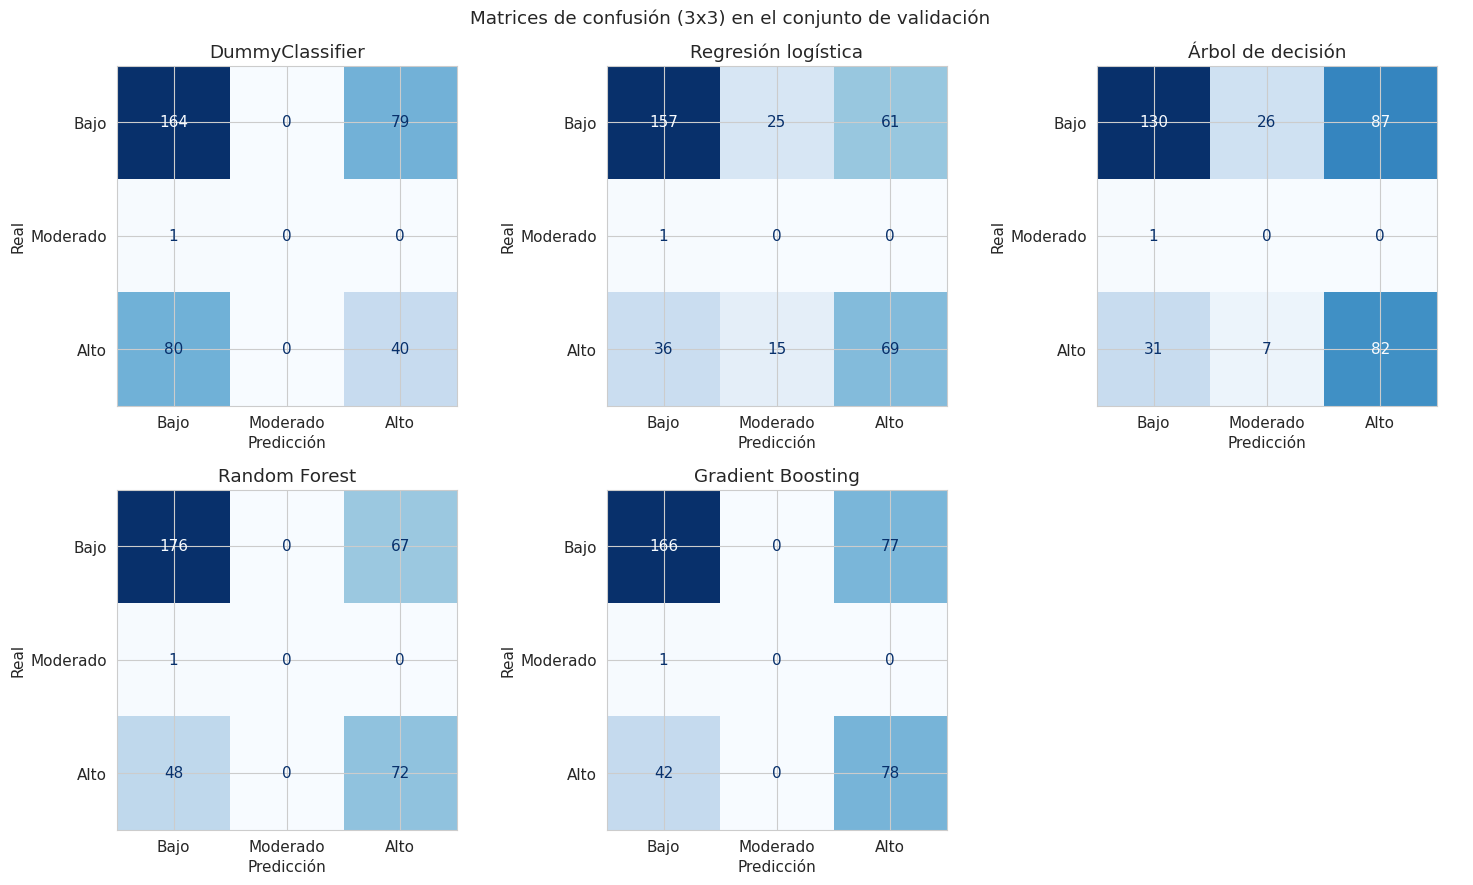

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15,9))
for ax, (nombre, pipe) in zip(axes.flat, pipelines_ajustados.items()):
    pred = pipe.predict(X_val)
    cm = confusion_matrix(y_val, pred, labels=ORDEN)
    disp = ConfusionMatrixDisplay(cm, display_labels=NOMBRES_CLASES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
axes.flat[-1].axis('off')
plt.suptitle('Matrices de confusión (3x3) en el conjunto de validación')
plt.tight_layout()
plt.show()

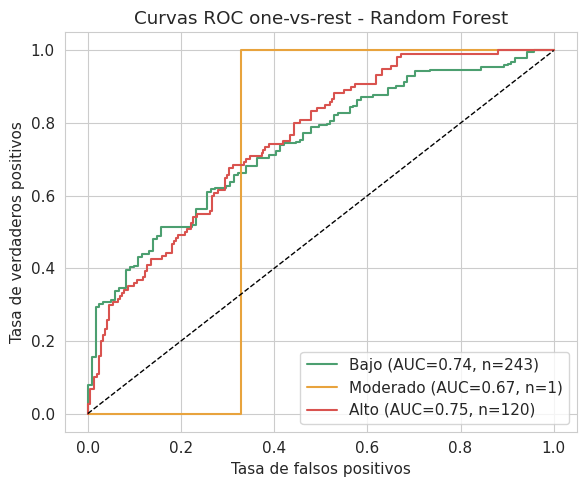

Modelo seleccionado por ROC-AUC (Alto) en validación cruzada: Random Forest


In [29]:
y_val_bin = label_binarize(y_val, classes=ORDEN)
mejor_pipe = pipelines_ajustados[mejor_nombre]
proba = mejor_pipe.predict_proba(X_val)

plt.figure(figsize=(6,5))
for i, lab in enumerate(NOMBRES_CLASES):
    if y_val_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], proba[:, i])
    auc_i = roc_auc_score(y_val_bin[:, i], proba[:, i])
    n_i = int(y_val_bin[:, i].sum())
    plt.plot(fpr, tpr, label=f'{lab} (AUC={auc_i:.2f}, n={n_i})', color=PAL[lab])
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title(f'Curvas ROC one-vs-rest - {mejor_nombre}')
plt.legend()
plt.tight_layout()
plt.show()
print("Modelo seleccionado por ROC-AUC (Alto) en validación cruzada:", mejor_nombre)

**Qué mide cada métrica.** La *accuracy* es la proporción total de aciertos, pero con
clases desbalanceadas puede ser engañosa. La *precision* mide, de los casos que el modelo
etiquetó como una clase, cuántos realmente lo eran (evita falsas alarmas). El *recall* mide, de
los casos que realmente pertenecen a una clase, cuántos el modelo logró identificar (evita
omisiones). El *F1-score* combina precision y recall en un solo número. El *ROC-AUC* mide la
capacidad del modelo para separar clases a distintos umbrales de decisión, calculado en
esquema one-vs-rest y promediado (macro) entre las tres clases.

**Por qué precision, recall y F1 son relevantes aquí.** El objetivo de negocio es identificar
correctamente a quienes tienen riesgo alto (recall alto en la clase 2), sin generar
demasiadas falsas alarmas que saturen la capacidad de atención (precision razonable). Elegir un
modelo solo por accuracy podría favorecer a uno que casi nunca predice la clase de riesgo.

**Resultado.** En la validación cruzada agrupada (la comparación más estable), los cuatro modelos con variables superan
al baseline en la capacidad de separar el riesgo alto: ROC-AUC de la clase "alto" entre 0.69 y 0.76 frente a 0.50 del
`DummyClassifier`. **Random Forest obtiene el mejor ROC-AUC de la clase alto (0.755)**, seguido de Gradient Boosting (0.748),
regresión logística (0.735) y árbol de decisión (0.691). En el conjunto de validación el patrón se mantiene (Random Forest 0.754).
El recall de la clase alto ronda 0.62 a 0.64 en todos los modelos, así que la diferencia entre ellos es modesta (alrededor de 0.02 de AUC entre los tres mejores).

Dos precauciones al leer las tablas: (1) las métricas *macro* mezclan la clase moderada, que ningún modelo
detecta (recall 0 en validación cruzada; la regresión logística y el árbol incluso etiquetan como "moderado" a más de 160 pacientes sin
acertar ninguno de los 9 casos reales, efecto de los pesos balanceados con tan pocos ejemplos), por eso el
ranking por ROC-AUC macro no coincide con el de la clase alto; (2) la validación tiene 1 solo caso moderado, así que su ROC-AUC macro
es muy ruidoso. Por ello el modelo se selecciona por el ROC-AUC de la clase **alto** en validación cruzada:
**Random Forest**. La regresión logística queda como alternativa interpretable con desempeño cercano.

## Análisis de los errores de clasificación

In [30]:
pred_mejor = mejor_pipe.predict(X_val)
print(f"Reporte de clasificación - {mejor_nombre} (conjunto de validación)")
print(classification_report(y_val, pred_mejor, labels=ORDEN, target_names=NOMBRES_CLASES, zero_division=0))

Reporte de clasificación - Random Forest (conjunto de validación)
              precision    recall  f1-score   support

        Bajo       0.78      0.72      0.75       243
    Moderado       0.00      0.00      0.00         1
        Alto       0.52      0.60      0.56       120

    accuracy                           0.68       364
   macro avg       0.43      0.44      0.44       364
weighted avg       0.69      0.68      0.69       364



| Tipo de error | Interpretación en este proyecto |
|---|---|
| Falso positivo | Paciente clasificado como **riesgo alto** que en realidad no lo es: prueba confirmatoria o seguimiento adicional innecesario (costo económico/logístico, bajo riesgo clínico). |
| Falso negativo | Paciente de **riesgo alto** clasificado como bajo o moderado: se queda sin seguimiento preventivo. Es el error más costoso para la organización. |

Dado que un falso negativo tiene un costo potencial más alto que un falso positivo en este
contexto (perder la oportunidad de una intervención temprana), el **recall de la clase "alto"** es la métrica
que más se debe vigilar, incluso si ello implica aceptar una precisión algo menor. Ningún modelo logra identificar de forma
confiable la clase "moderado", dada su extrema escasez (12 casos en total).

## Análisis del umbral de decisión

Para la decisión operativa se colapsa el problema a una vista binaria auxiliar: **riesgo alto (1) vs.
riesgo bajo o moderado (0)**, usando la probabilidad que el modelo asigna a la clase "alto". Se muestra
también qué porcentaje de los pacientes quedaría señalado para prueba confirmatoria, dato clave para
dimensionar la capacidad de atención.

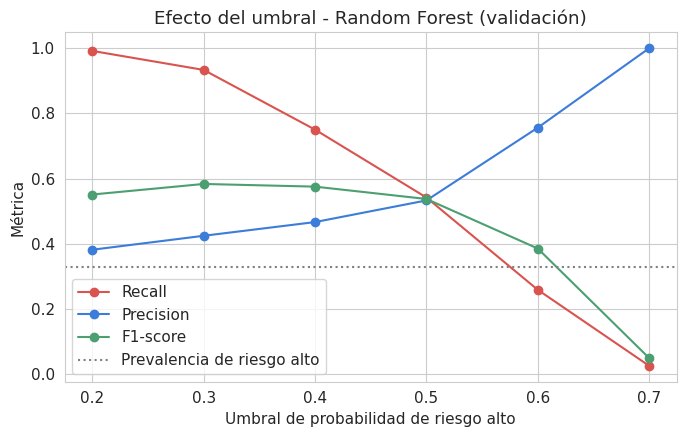

Efecto del umbral (riesgo alto vs. resto):


,Umbral,Precision,Recall,F1-score,% de pacientes señalados
0,0.2,0.381,0.992,0.551,85.714
1,0.3,0.424,0.933,0.583,72.527
2,0.4,0.466,0.750,0.575,53.022
3,0.5,0.533,0.542,0.537,33.516
4,0.6,0.756,0.258,0.385,11.264
5,0.7,1.000,0.025,0.049,0.824


In [31]:
y_val_alto = (y_val == 2).astype(int)
proba_alto = mejor_pipe.predict_proba(X_val)[:, 2]

umbrales = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
filas_umbral = []
for u in umbrales:
    pred_u = (proba_alto >= u).astype(int)
    filas_umbral.append([u,
                         precision_score(y_val_alto, pred_u, zero_division=0),
                         recall_score(y_val_alto, pred_u, zero_division=0),
                         f1_score(y_val_alto, pred_u, zero_division=0),
                         pred_u.mean()*100])

tabla_umbral = pd.DataFrame(filas_umbral, columns=['Umbral','Precision','Recall','F1-score','% de pacientes señalados'])

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(tabla_umbral['Umbral'], tabla_umbral['Recall'], marker='o', label='Recall', color='#D9534F')
ax.plot(tabla_umbral['Umbral'], tabla_umbral['Precision'], marker='o', label='Precision', color='#3B7DD8')
ax.plot(tabla_umbral['Umbral'], tabla_umbral['F1-score'], marker='o', label='F1-score', color='#4C9F70')
ax.axhline(y_val_alto.mean(), color='gray', linestyle=':', label='Prevalencia de riesgo alto')
ax.set_xlabel('Umbral de probabilidad de riesgo alto')
ax.set_ylabel('Métrica')
ax.set_title(f'Efecto del umbral - {mejor_nombre} (validación)')
ax.legend()
plt.tight_layout()
plt.show()

print("Efecto del umbral (riesgo alto vs. resto):")
tabla_umbral.round(3)

En validación la prevalencia de riesgo alto es 33%, y el modelo no asigna probabilidades extremas, por lo que el
umbral cambia mucho el equilibrio (las probabilidades de un Random Forest con pesos balanceados no están calibradas, así que 0.50 no es un punto de corte "neutral"):

- **Umbral 0.30:** detecta ~93% de los casos de riesgo alto, pero señalaría a ~73% de los pacientes para prueba confirmatoria, con precision de 0.42.
- **Umbral 0.40:** recall de ~75% señalando ~53% de los pacientes; F1 similar al del umbral 0.30.
- **Umbral 0.50:** solo ~54% de los casos de riesgo alto detectados, con ~34% de pacientes señalados y precision de 0.53.
- **Umbral ≥ 0.60:** se pierden aproximadamente 3 de cada 4 casos de riesgo alto (recall ≤ 0.26).

Esto demuestra que la clasificación final depende de una **decisión operativa** (cuántos casos de riesgo se aceptan
perder frente a cuántas pruebas confirmatorias se pueden realizar) y no solo del algoritmo. En esta fase no se
selecciona un umbral definitivo; esa decisión debe tomarse en conjunto con el área de salud, considerando su
capacidad real de dar seguimiento a los casos señalados. Con ~120 casos de riesgo alto en validación, estos porcentajes tienen un margen de error de varios puntos.

## ¿Cuánto aportan las variables económicas frente a los bioquímicos?

La necesidad organizacional es priorizar con variables **más simples y baratas** que una prueba de glucosa.
Los marcadores bioquímicos (lípidos, insulina, creatinina, etc.) también requieren una muestra de sangre,
así que conviene medir cuánto mejoran realmente la predicción respecto a variables que se obtienen
en una consulta básica. Se repite la validación cruzada agrupada con la regresión logística (rápida e
interpretable) sobre tres conjuntos de variables.

In [32]:
conjuntos = {
    'A. Consulta básica (edad, sexo, IMC, entidad)': (['edad','imc_calc'], ['sexo','entidad_cve']),
    'B. A + perfil de lípidos (HDL, LDL, colesterol, triglicéridos)': (['edad','imc_calc','col_hdl','col_ldl','colest','trig'], ['sexo','entidad_cve']),
    'C. Completo (B + ácido úrico, albúmina, creatinina, insulina)': (num_cols, cat_cols),
}

filas_abl = []
for nombre_conjunto, (nc, cc) in conjuntos.items():
    pipe_abl = Pipeline([('pre', crear_preprocesador(nc, cc)),
                         ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'))])
    proba_abl = cross_val_predict(pipe_abl, X_train, y_train, groups=g_train, cv=cv_agrupado, method='predict_proba')
    m = calcular_metricas(nombre_conjunto, y_train, proba_abl)
    filas_abl.append([nombre_conjunto, len(nc) + len(cc), m[6], m[7], m[8]])

tabla_ablacion = pd.DataFrame(filas_abl, columns=['Conjunto de variables','Nº de variables','Recall (Alto)','F1-score (Alto)','ROC-AUC (Alto)'])
tabla_ablacion.round(3)

,Conjunto de variables,Nº de variables,Recall (Alto),F1-score (Alto),ROC-AUC (Alto)
0,"A. Consulta básica (edad, sexo, IMC, entidad)",4,0.550,0.503,0.661
1,"B. A + perfil de lípidos (HDL, LDL, colesterol...",8,0.622,0.547,0.700
2,"C. Completo (B + ácido úrico, albúmina, creati...",12,0.635,0.571,0.735


El ROC-AUC de la clase alto sube de **0.66** con variables de consulta básica (edad, sexo, IMC y entidad) a **0.70** al agregar el
perfil de lípidos y a **0.735** con el conjunto completo; el recall de riesgo alto pasa de 0.55 a 0.63. Es decir, las variables baratas
ya contienen señal por encima del azar (0.50), pero los marcadores bioquímicos aportan una mejora adicional real, en dos escalones de tamaño similar (lípidos, y ácido úrico, albúmina, creatinina e insulina).

Implicación para la organización: un tamizaje que use **solo** variables de consulta básica tendría un desempeño
limitado, mientras que el modelo completo solo tiene sentido donde ya exista una muestra de sangre (como en este dataset). Es una comparación
con un único modelo y validación cruzada; conviene repetirla con el modelo final.

## Interpretabilidad: coeficientes de la regresión logística

Para explicar qué variables empujan la probabilidad de **riesgo alto**, se revisan los coeficientes de
la regresión logística multinomial (variables numéricas estandarizadas, por lo que su magnitud es
comparable). Un coeficiente positivo aumenta la probabilidad de riesgo alto; uno negativo la disminuye.

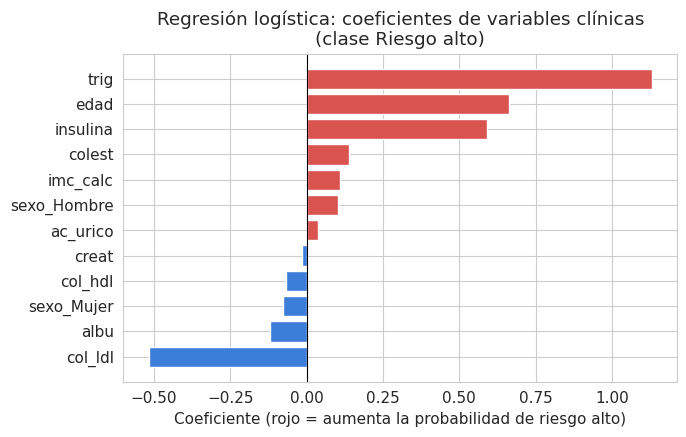

Coeficientes de variables clínicas (ordenados):
trig           1.131
edad           0.664
insulina       0.590
colest         0.140
imc_calc       0.110
sexo_Hombre    0.103
ac_urico       0.036
creat         -0.016
col_hdl       -0.068
sexo_Mujer    -0.077
albu          -0.119
col_ldl       -0.518

Entidades federativas: 31 coeficientes, rango [-1.99, 0.85]


In [33]:
pipe_lr = pipelines_ajustados['Regresión logística']
nombres_vars = pipe_lr.named_steps['pre'].get_feature_names_out()
clf_lr = pipe_lr.named_steps['clf']
coef_alto = pd.Series(clf_lr.coef_[list(clf_lr.classes_).index(2)], index=nombres_vars)
coef_alto.index = [n.replace('num__','').replace('cat__','') for n in coef_alto.index]

# Las 31 entidades tienen pocos pacientes cada una (~80), por lo que sus coeficientes son inestables;
# se grafican por separado de las variables clínicas.
es_entidad = coef_alto.index.str.startswith('entidad_cve')
coef_clinicas = coef_alto[~es_entidad].sort_values()

plt.figure(figsize=(7,4.5))
plt.barh(coef_clinicas.index, coef_clinicas.values,
         color=['#D9534F' if v > 0 else '#3B7DD8' for v in coef_clinicas.values])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Regresión logística: coeficientes de variables clínicas\n(clase Riesgo alto)')
plt.xlabel('Coeficiente (rojo = aumenta la probabilidad de riesgo alto)')
plt.tight_layout()
plt.show()

print("Coeficientes de variables clínicas (ordenados):")
print(coef_clinicas.sort_values(ascending=False).round(3).to_string())
print(f"\nEntidades federativas: {es_entidad.sum()} coeficientes, rango "
      f"[{coef_alto[es_entidad].min():.2f}, {coef_alto[es_entidad].max():.2f}]")

**Lectura de los coeficientes.** Los triglicéridos son la variable clínica con mayor efecto positivo sobre la probabilidad de riesgo alto
(+1.13), seguidos de la edad (+0.66) y la insulina (+0.59), lo cual es clínicamente coherente con el síndrome metabólico. El IMC tiene un coeficiente
pequeño (+0.11) porque su información se solapa con la de la insulina y los triglicéridos, con los que está correlacionado.

**Precauciones.** (1) El colesterol LDL aparece con signo negativo (-0.52) y el colesterol total con signo positivo, pero ambos
están altamente correlacionados (r = 0.88): con variables tan correlacionadas los signos individuales no deben interpretarse por separado. (2) Los
coeficientes de las 31 entidades federativas (rango de -1.99 a +0.85) se basan en ~80 pacientes por entidad en promedio, por lo que son inestables y
no deben leerse como una comparación entre estados. (3) Son asociaciones, no relaciones causales. Estas explicaciones provienen de la regresión logística;
el modelo seleccionado es el Random Forest, cuya interpretación (importancia por permutación o SHAP) queda como siguiente paso.

## Trazabilidad

In [34]:
import platform
trazabilidad = pd.DataFrame([
    ['Dataset', 'Diabetes_Mexico.csv (' + str(df.shape[0]) + ' registros, ' + str(df['folio_i'].nunique()) + ' hogares)'],
    ['Variable objetivo', 'riesgo_diabetes_cat (0 = bajo, 1 = moderado, 2 = alto)'],
    ['Semilla', RANDOM_STATE],
    ['Partición', 'StratifiedGroupKFold por hogar (folio_i): ' + f'{len(X_train)} / {len(X_val)} / {len(X_test)}'],
    ['Comparación de modelos', 'Validación cruzada agrupada de 5 pliegues sobre entrenamiento'],
    ['Modelo seleccionado', mejor_nombre],
    ['Variables excluidas por fuga', 'glu_suero, hb1ac'],
    ['Python', platform.python_version()],
    ['scikit-learn', sklearn.__version__],
    ['pandas / numpy', pd.__version__ + ' / ' + np.__version__],
], columns=['Elemento', 'Detalle'])
trazabilidad

,Elemento,Detalle
0,Dataset,"Diabetes_Mexico.csv (2549 registros, 2055 hoga..."
1,Variable objetivo,"riesgo_diabetes_cat (0 = bajo, 1 = moderado, 2..."
2,Semilla,42
3,Partición,StratifiedGroupKFold por hogar (folio_i): 1820...
4,Comparación de modelos,Validación cruzada agrupada de 5 pliegues sobr...
5,Modelo seleccionado,Random Forest
6,Variables excluidas por fuga,"glu_suero, hb1ac"
7,Python,3.11.15
8,scikit-learn,1.8.0
9,pandas / numpy,3.0.2 / 2.4.4


## Conclusiones y siguientes pasos

**Corrección principal.** `riesgo_diabetes_cat` se interpreta ahora como **0 = riesgo bajo, 1 = riesgo moderado, 2 = riesgo alto**
(antes: sin riesgo, diagnosticado y en riesgo). La clase de mayor interés pasa a ser el **riesgo alto** (33% de los pacientes), y el
análisis de errores y de umbrales se reorientó a detectarla.

**Hallazgos.**
- Excluir `glu_suero` y `hb1ac` sigue siendo indispensable: el riesgo bajo y el moderado tienen siempre glucosa < 100 mg/dL y el 96% del riesgo alto tiene ≥ 100 mg/dL.
- Con variables indirectas y una partición honesta (por hogar), el mejor modelo (Random Forest) separa el riesgo alto con ROC-AUC ≈ 0.75 y recall ≈ 0.6 con el umbral por defecto. Es una mejora clara frente al baseline (0.50), pero **es un desempeño moderado**: sirve para priorizar, no para diagnosticar.
- Los marcadores bioquímicos aportan valor por encima de las variables de consulta básica (AUC 0.66 → 0.735).

**Limitaciones.**
- La clase **moderado** tiene solo 12 casos y ningún modelo la detecta; además su criterio de construcción no está documentado en el glosario (todos los casos tienen glucosa normal). Conviene confirmarlo con la fuente o valorar agruparla con "bajo" en la entrega final.
- El 4% del riesgo alto (33 pacientes) tiene glucosa < 100 mg/dL, por lo que el criterio de la variable objetivo no es únicamente la glucosa en ayuno.
- Los faltantes de peso/estatura son más frecuentes en riesgo alto (41% vs. 22%); se imputan, pero el IMC de esos pacientes es menos informativo.
- Las diferencias entre los tres mejores modelos son pequeñas y no se ha realizado búsqueda de hiperparámetros ni análisis de sesgos por subgrupos.

**Siguientes pasos.** (1) Búsqueda de hiperparámetros con la misma validación cruzada agrupada; (2) calibración de probabilidades y elección del umbral junto con el área de salud;
(3) equidad entre subgrupos (sexo, entidad, edad); (4) interpretabilidad del modelo final (SHAP o importancia por permutación); (5) **evaluación única en el conjunto de prueba**, que
permanece intacto; (6) serialización del pipeline con `joblib`.

**Uso responsable.** El resultado del modelo debe interpretarse como evidencia adicional para priorizar pruebas confirmatorias y acciones preventivas,
nunca como diagnóstico ni como mecanismo automático para negar atención.

---
# Parte II. Entrega final

## 0. Configuración de la entrega final

Se agregan las librerías necesarias para los modelos avanzados, la interpretabilidad (SHAP) y la serialización.
Las carpetas siguen la estructura del repositorio: `data/`, `notebooks/`, `scripts/`, `artifacts/`, `results/` y `docs/`.
Si el notebook se ejecuta fuera del repositorio (por ejemplo en Colab), las carpetas se crean junto al notebook.

In [35]:
import sys, time, json, hashlib, datetime, subprocess
from pathlib import Path
import joblib
import shap
from sklearn.base import clone
from sklearn.model_selection import (cross_validate, GridSearchCV, RandomizedSearchCV,
                                     validation_curve)
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance
from sklearn.metrics import (make_scorer, precision_recall_curve, average_precision_score)

BASE = Path('..') if Path('../data/Diabetes_Mexico.csv').exists() else Path('.')
DIR_SCRIPTS, DIR_ART = BASE / 'scripts', BASE / 'artifacts'
DIR_RES, DIR_FIG, DIR_DOCS = BASE / 'results', BASE / 'results' / 'figuras', BASE / 'docs'
for d in (DIR_SCRIPTS, DIR_ART, DIR_RES, DIR_FIG, DIR_DOCS):
    d.mkdir(parents=True, exist_ok=True)

FECHA = datetime.date.today().isoformat()
VERSION_MODELO = '1.0.0'
RESPONSABLE = 'Alan Adelfo Del Angel Figueroa (T02814389)'
COLOR_ALTO, COLOR_RESTO, COLOR_GRIS = '#D9534F', '#3B7DD8', '#8C8C8C'

def guardar_fig(nombre):
    plt.savefig(DIR_FIG / f'{nombre}.png', dpi=150, bbox_inches='tight')

print('Carpeta base del proyecto:', BASE.resolve())
print('Fecha de ejecución:', FECHA)
print('shap', shap.__version__, '| joblib', joblib.__version__, '| scikit-learn', sklearn.__version__)

Carpeta base del proyecto: /home/claude/diabetes_final
Fecha de ejecución: 2026-09-30
shap 0.51.0 | joblib 1.5.3 | scikit-learn 1.8.0


## 1. Recuperación y verificación de los componentes del avance

Antes de continuar se verifica, con código, que cada componente del avance exista y se reproduzca. La tabla
de verificación inicial registra dónde está cada elemento, su versión, su estado y la acción requerida.

In [36]:
huella_csv = hashlib.md5(open(ruta, 'rb').read()).hexdigest()
auc_alto_avance = tabla_cv.set_index('Modelo')['ROC-AUC (Alto)']

verificacion = pd.DataFrame([
    ['Dataset original', f'data/{Path(ruta).name}', f'v1 (md5 {huella_csv[:10]})',
     f'Disponible: {df.shape[0]} filas, 24 columnas originales', 'Ninguna; se registra la huella md5'],
    ['Diccionario de variables', 'Parte I, "Glosario de variables"', 'Avance corregido',
     f'Disponible ({len(glosario)} variables)', 'Agregar códigos centinela de Peso/Estatura y variables nuevas'],
    ['Análisis exploratorio', 'Parte I, "Análisis exploratorio de datos"', 'Avance corregido',
     'Reproducido sin errores', 'Ninguna'],
    ['Diagnóstico de calidad', 'Parte I, "Análisis de la calidad de los datos"', 'Avance corregido',
     'Reproducido sin errores', 'Revisar de nuevo valores fuera de rango (sección 3)'],
    ['Variable objetivo', 'riesgo_diabetes_cat', '0/1/2 = bajo/moderado/alto',
     f"Verificada: {df['riesgo_diabetes_cat'].value_counts().sort_index().to_dict()}", 'Ninguna; se conserva'],
    ['Separación predictores / objetivo', 'Parte I, X e y', 'Avance corregido',
     f'X con {X.shape[1]} columnas; y con {y.shape[0]} registros', 'Pasar a entrada "cruda" + pipeline con ingeniería'],
    ['Conjuntos de entrenamiento, validación y prueba', 'StratifiedGroupKFold por hogar (folio_i)', 'Semilla 42',
     f'{len(X_train)} / {len(X_val)} / {len(X_test)}; ningún hogar compartido',
     'Unir entrenamiento + validación como conjunto de desarrollo; la prueba queda intacta'],
    ['Semilla', 'RANDOM_STATE', str(RANDOM_STATE), 'Verificada', 'Ninguna'],
    ['Pipeline de preprocesamiento', 'crear_preprocesador()', 'v0 (avance)', 'Funcional',
     'Consolidar limpieza, ingeniería, atípicos y codificación por tipo'],
    ['Modelo baseline', 'DummyClassifier(stratified)', 'v0 (avance)',
     f"ROC-AUC (Alto) VC = {auc_alto_avance['DummyClassifier']:.3f}", 'Re-ejecutar con la nueva validación'],
    ['Modelos iniciales', 'Regresión logística, árbol, RF, HGB', 'v0 (avance)', 'Reproducidos',
     'Agregar SVM, MLP y ajuste de hiperparámetros'],
    ['Métricas', 'calcular_metricas()', 'v0 (avance)', 'Reproducidas',
     'Agregar desviación estándar y tiempos de entrenamiento / inferencia'],
    ['Matrices de confusión y curvas ROC', 'Parte I, "Evaluación de los modelos"', 'v0 (avance)', 'Reproducidas',
     'Agregar curva precision-recall y evaluación en prueba'],
    ['Modelo preliminar seleccionado', mejor_nombre, 'v0 (avance)',
     f"ROC-AUC (Alto) VC = {auc_alto_avance[mejor_nombre]:.3f}", 'Comparar contra modelos ajustados'],
    ['Plan de mejora', 'Parte I, "Conclusiones y siguientes pasos"', 'Avance corregido', 'Disponible (6 pasos)',
     'Ejecutar los 6 pasos en esta entrega'],
    ['Tabla de trazabilidad', 'Parte I, "Trazabilidad"', 'Avance corregido', 'Disponible',
     'Ampliar a trazabilidad final (sección 30)'],
    ['Informe del avance', 'docs/Reporte_Avance_Riesgo_Diabetes.pdf', '30/08/2026',
     'Disponible, pero anterior a la corrección de la variable objetivo', 'Sustituir por el informe técnico final'],
], columns=['Elemento', 'Archivo o ubicación', 'Versión', 'Estado', 'Acción requerida'])
verificacion.to_csv(DIR_RES / 'tabla_verificacion_inicial.csv', index=False)
verificacion

,Elemento,Archivo o ubicación,Versión,Estado,Acción requerida
0,Dataset original,data/Diabetes_Mexico.csv,v1 (md5 eb696bc3e9),"Disponible: 2549 filas, 24 columnas originales",Ninguna; se registra la huella md5
1,Diccionario de variables,"Parte I, ""Glosario de variables""",Avance corregido,Disponible (24 variables),Agregar códigos centinela de Peso/Estatura y v...
2,Análisis exploratorio,"Parte I, ""Análisis exploratorio de datos""",Avance corregido,Reproducido sin errores,Ninguna
3,Diagnóstico de calidad,"Parte I, ""Análisis de la calidad de los datos""",Avance corregido,Reproducido sin errores,Revisar de nuevo valores fuera de rango (secci...
4,Variable objetivo,riesgo_diabetes_cat,0/1/2 = bajo/moderado/alto,"Verificada: {0: 1697, 1: 12, 2: 840}",Ninguna; se conserva
5,Separación predictores / objetivo,"Parte I, X e y",Avance corregido,X con 12 columnas; y con 2549 registros,"Pasar a entrada ""cruda"" + pipeline con ingeniería"
6,"Conjuntos de entrenamiento, validación y prueba",StratifiedGroupKFold por hogar (folio_i),Semilla 42,1820 / 364 / 365; ningún hogar compartido,Unir entrenamiento + validación como conjunto ...
7,Semilla,RANDOM_STATE,42,Verificada,Ninguna
8,Pipeline de preprocesamiento,crear_preprocesador(),v0 (avance),Funcional,"Consolidar limpieza, ingeniería, atípicos y co..."
9,Modelo baseline,DummyClassifier(stratified),v0 (avance),ROC-AUC (Alto) VC = 0.502,Re-ejecutar con la nueva validación


**¿Se reproducen los resultados del avance?** Se comparan los ROC-AUC de la clase *alto* obtenidos al volver a
ejecutar la Parte I (misma semilla, mismo pipeline, misma validación cruzada agrupada de 5 pliegues sobre el
entrenamiento) contra los valores registrados en el avance corregido.

In [37]:
registrado_avance = {'DummyClassifier': 0.502, 'Regresión logística': 0.735, 'Árbol de decisión': 0.691,
                     'Random Forest': 0.755, 'Gradient Boosting': 0.748}
reproduccion = pd.DataFrame({'ROC-AUC (Alto) registrado en el avance': pd.Series(registrado_avance),
                             'ROC-AUC (Alto) re-ejecutado': auc_alto_avance.round(3)})
reproduccion['Diferencia'] = (reproduccion.iloc[:, 1] - reproduccion.iloc[:, 0]).round(3)
reproduccion['¿Coincide?'] = np.where(reproduccion['Diferencia'].abs() <= 0.001, 'Sí', 'No')
reproduccion.to_csv(DIR_RES / 'reproduccion_avance.csv')
reproduccion

,ROC-AUC (Alto) registrado en el avance,ROC-AUC (Alto) re-ejecutado,Diferencia,¿Coincide?
DummyClassifier,0.502,0.502,0.0,Sí
Regresión logística,0.735,0.735,0.0,Sí
Árbol de decisión,0.691,0.691,0.0,Sí
Random Forest,0.755,0.755,0.0,Sí
Gradient Boosting,0.748,0.748,0.0,Sí


## 2. Bitácora de cambios desde el avance

| Elemento modificado | Situación en el avance | Cambio realizado | Justificación | Impacto esperado |
|---|---|---|---|---|
| Datos | `Peso = 222.22` y `Estatura = 222.2` se trataban como mediciones reales | Se tratan como código de dato faltante (NaN) | Son códigos centinela (valor repetido e imposible como estatura) que generaban IMC ficticios de ~45 | IMC más fiel; 11 pesos y 15 estaturas pasan a faltantes imputados |
| Datos | Entrenamiento (1,820) y validación (364) separados | Se unen como **conjunto de desarrollo** (2,184) para validación cruzada; la prueba (365) sigue intacta | La validación tenía 1 solo caso moderado y una sola partición es inestable | Comparaciones con media y desviación estándar |
| Preprocesamiento | Imputación + escalamiento + One-Hot | Pipeline único: limpieza determinista, ingeniería de características, winsorización (p0.5 a p99.5), log1p de variables sesgadas, codificación binaria, ordinal y One-Hot con agrupación de entidades poco frecuentes | Tratar cada tipo de variable según su significado y poder aplicar las mismas reglas en inferencia | Pipeline serializable y reproducible |
| Preprocesamiento | 12 variables | 4 características nuevas (`ratio_trig_hdl`, `col_no_hdl`, `grupo_edad`, `categoria_imc`) | Marcadores clínicos conocidos de riesgo metabólico sin usar glucosa | Señal adicional para modelos lineales y de márgenes |
| Modelos | Dummy, regresión logística, árbol, RF, HGB sin ajuste | Se agregan SVM lineal, SVM RBF y MLP; ajuste sistemático (GridSearchCV y RandomizedSearchCV) | Requisito de la entrega final y posibles mejoras de desempeño | Selección del modelo con evidencia |
| Modelos | 12 variables con 31 entidades (One-Hot) | Selección de características: modelo reducido sin entidad federativa | SelectFromModel descarta la mayoría de las entidades y el desempeño no cambia | Modelo más simple, menos datos de entrada y menor riesgo de sesgo regional |
| Métricas | Una sola corrida de VC de 5 pliegues | VC agrupada **repetida** (5 pliegues x 3 repeticiones), media, desviación estándar, tiempos | Estabilidad de la comparación | Diferencias entre modelos interpretables |
| Umbral | Tabla exploratoria sin umbral definitivo | Umbral operativo elegido con predicciones fuera de pliegue del conjunto de desarrollo (recall mínimo de 0.80) | No usar la prueba para decidir el umbral | Umbral documentado y validado en prueba |
| Interpretabilidad | Coeficientes de la regresión logística | Importancia por permutación + SHAP (global y local) sobre el modelo final | El modelo final no es lineal | Explicación del modelo que realmente se usará |

## 3. Revisión final de la calidad de los datos

Se vuelve a cargar el archivo original (sin las transformaciones de la Parte I) para revisar faltantes, duplicados,
tipos, categorías, valores fuera de rango, variables excluidas, balance de clases y posible fuga de información.

In [38]:
df_crudo = pd.read_csv(ruta)
df_crudo['entidad_cve'] = df_crudo['folio_i'].astype(str).str.split('_').str[1].str[:2]

def a_numero(s):
    return pd.to_numeric(s.astype(str).str.replace(',', '.', regex=False), errors='coerce')

cols_texto_numericas = [c for c in df_crudo.columns if not pd.api.types.is_numeric_dtype(df_crudo[c]) and
                        a_numero(df_crudo[c]).notna().mean() > 0.5 and c not in ('folio_i', 'folio_int')]
num_crudo = df_crudo.copy()
for c in cols_texto_numericas:
    num_crudo[c] = a_numero(num_crudo[c])

entidades_inegi = {f'{i:02d}' for i in range(1, 33)}
calidad = pd.DataFrame([
    ['Valores faltantes', f"edad {df_crudo['edad'].isna().sum()}, Peso/Estatura {df_crudo['Peso'].isna().sum()}, "
                          f"imc {df_crudo['imc'].isna().sum()}, hb1ac {df_crudo['hb1ac'].isna().sum()}; bioquímicos 0",
     'Se imputan dentro del pipeline (mediana / moda); imc y hb1ac se excluyen'],
    ['Duplicados', f"Filas completas: {df_crudo.duplicated().sum()}; folio_int repetidos: {df_crudo['folio_int'].duplicated().sum()}",
     'Sin acción; los hogares repetidos se controlan con partición agrupada'],
    ['Tipos de datos', f"{len(cols_texto_numericas)} columnas numéricas leídas como texto por coma decimal",
     'Conversión dentro del pipeline (ConstructorCaracteristicas)'],
    ['Categorías', f"sexo: {sorted(df_crudo['sexo'].unique())}; entidades presentes: {df_crudo['entidad_cve'].nunique()} de 32 "
                   f"(ausente: {sorted(entidades_inegi - set(df_crudo['entidad_cve']))})",
     'Categorías no vistas se tratan en inferencia (validación y handle_unknown)'],
    ['Valores fuera de rango', f"edad = -7975: {(num_crudo['edad'] < 0).sum()}; Peso = 222.22: {(num_crudo['Peso'] >= 222).sum()}; "
                               f"Estatura = 222.2: {(num_crudo['Estatura'] >= 222).sum()}",
     'Códigos centinela convertidos a NaN'],
    ['Valores extremos plausibles', f"trig > 1000: {(num_crudo['trig'] > 1000).sum()}; insulina > 100: {(num_crudo['insulina'] > 100).sum()}; "
                                    f"creat > 5: {(num_crudo['creat'] > 5).sum()}",
     'Se conservan (clínicamente posibles) y se recortan a p0.5 a p99.5 aprendidos en entrenamiento'],
    ['Variables excluidas', 'folio_i, folio_int, Ciudad, imc, muestra_suero, glu_suero, hb1ac, ponde_venosa, estrato, est_sel, ponde_hemo',
     'Se mantienen excluidas (identificadores, constante, fuga, diseño muestral)'],
    ['Balance de clases', str((df_crudo['riesgo_diabetes_cat'].value_counts(normalize=True).sort_index() * 100).round(2).to_dict()),
     'class_weight balanceado; métrica principal centrada en riesgo alto'],
], columns=['Revisión', 'Hallazgo', 'Tratamiento'])
calidad

,Revisión,Hallazgo,Tratamiento
0,Valores faltantes,"edad 25, Peso/Estatura 720, imc 2514, hb1ac 23...",Se imputan dentro del pipeline (mediana / moda...
1,Duplicados,Filas completas: 0; folio_int repetidos: 0,Sin acción; los hogares repetidos se controlan...
2,Tipos de datos,10 columnas numéricas leídas como texto por co...,Conversión dentro del pipeline (ConstructorCar...
3,Categorías,"sexo: ['Hombre', 'Mujer']; entidades presentes...",Categorías no vistas se tratan en inferencia (...
4,Valores fuera de rango,edad = -7975: 4; Peso = 222.22: 11; Estatura =...,Códigos centinela convertidos a NaN
5,Valores extremos plausibles,trig > 1000: 7; insulina > 100: 11; creat > 5: 6,Se conservan (clínicamente posibles) y se reco...
6,Variables excluidas,"folio_i, folio_int, Ciudad, imc, muestra_suero...","Se mantienen excluidas (identificadores, const..."
7,Balance de clases,"{0: 66.58, 1: 0.47, 2: 32.95}",class_weight balanceado; métrica principal cen...


In [39]:
# Detalle del nuevo hallazgo: códigos centinela en Peso y Estatura
imc_antes = num_crudo['Peso'] / (num_crudo['Estatura'] / 100) ** 2
centinela = (num_crudo['Peso'] >= 222) | (num_crudo['Estatura'] >= 222)
print('Registros con Peso = 222.22 o Estatura = 222.2:', int(centinela.sum()))
print('IMC calculado con esos códigos (ficticio):', imc_antes[centinela].round(1).dropna().unique()[:5])
print('IMC recalculado (avance) incluía', int((centinela & imc_antes.notna()).sum()), 'valores ficticios')

Registros con Peso = 222.22 o Estatura = 222.2: 15
IMC calculado con esos códigos (ficticio): [45.  12.4 15.8 16.7 19.8]
IMC recalculado (avance) incluía 15 valores ficticios


**Tabla de cambios adicionales en la preparación de los datos**

| Variable afectada | Tratamiento en el avance | Tratamiento nuevo | Razón del cambio | Efecto en registros o variables |
|---|---|---|---|---|
| `Peso`, `Estatura` | Conversión a número; se usaban tal cual | 222.22 / 222.2 se convierten en NaN antes de calcular el IMC | Son códigos de dato faltante (ENSANUT), generaban IMC ficticio de ~45 | 11 pesos y 15 estaturas pasan a faltantes; ningún registro se elimina |
| `imc_calc` | Peso / estatura^2 | Igual, pero sin los códigos centinela y con winsorización p0.5 a p99.5 | Evitar valores imposibles y colas extremas en modelos sensibles a escala | Distribución más realista |
| `trig`, `insulina`, `creat` | Escalamiento estándar | Winsorización + log1p + escalamiento | Distribuciones con cola larga a la derecha | Menor influencia de valores extremos en SVM y regresión logística |
| `entidad_cve` | One-Hot de 31 entidades | One-Hot con agrupación de entidades con menos de 50 registros; después se evalúa quitarla (sección 11) | Categorías con pocos casos son inestables | Menos columnas y menor sobreajuste |
| Particiones | Entrenamiento / validación / prueba | Desarrollo (entrenamiento + validación) / prueba | Validación cruzada más estable | Prueba intacta para la evaluación final |

Ningún cambio impide comparar con el avance: los mismos registros siguen en la partición de prueba y la comparación
del avance se reprodujo en la sección 1.

**Revisión de fuga de información.** Se calcula el ROC-AUC univariado de cada variable para separar el riesgo alto
del resto. Una variable individual con AUC cercano a 1 indicaría que "contiene" la respuesta.

In [40]:
auc_univariado = []
for c in ['glu_suero', 'hb1ac', 'edad', 'Peso', 'Estatura', 'ac_urico', 'albu', 'col_hdl', 'col_ldl',
          'colest', 'creat', 'insulina', 'trig']:
    v = num_crudo[c].where(~((c == 'edad') & (num_crudo[c] < 0)))
    m = v.notna()
    y_alto_c = (df_crudo.loc[m, 'riesgo_diabetes_cat'] == 2).astype(int)
    auc = roc_auc_score(y_alto_c, v[m])
    auc_univariado.append([c, round(max(auc, 1 - auc), 3), round(m.mean() * 100, 1),
                           'EXCLUIDA (fuga)' if c in ('glu_suero', 'hb1ac') else 'Predictora'])
auc_univariado = pd.DataFrame(auc_univariado, columns=['Variable', 'AUC univariado (Alto vs resto)',
                                                       '% datos disponibles', 'Decisión'])
auc_univariado.sort_values('AUC univariado (Alto vs resto)', ascending=False)

,Variable,AUC univariado (Alto vs resto),% datos disponibles,Decisión
0,glu_suero,0.982,100.0,EXCLUIDA (fuga)
1,hb1ac,0.922,9.5,EXCLUIDA (fuga)
2,edad,0.677,98.9,Predictora
12,trig,0.645,100.0,Predictora
11,insulina,0.636,100.0,Predictora
3,Peso,0.616,71.8,Predictora
9,colest,0.583,100.0,Predictora
8,col_ldl,0.565,100.0,Predictora
5,ac_urico,0.543,100.0,Predictora
10,creat,0.542,100.0,Predictora


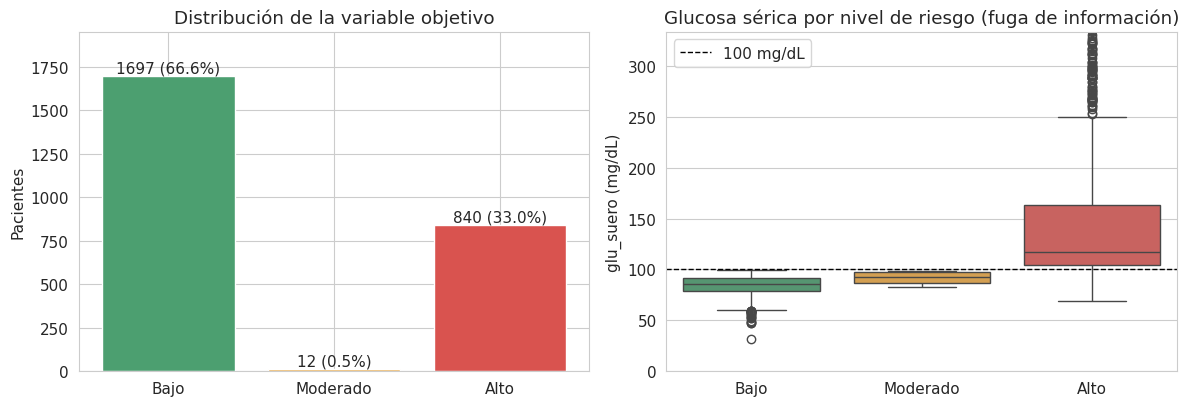

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
cnt_obj = df['riesgo_diabetes_cat'].value_counts().reindex(ORDEN)
axes[0].bar(NOMBRES_CLASES, cnt_obj.values, color=[PAL[n] for n in NOMBRES_CLASES])
for i, v in enumerate(cnt_obj.values):
    axes[0].text(i, v + 20, f'{v} ({v / len(df) * 100:.1f}%)', ha='center')
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_ylabel('Pacientes')
axes[0].set_ylim(0, cnt_obj.max() * 1.15)
sns.boxplot(x=df['riesgo_label'], y=num_crudo['glu_suero'], order=NOMBRES_CLASES, hue=df['riesgo_label'],
            palette=PAL, legend=False, ax=axes[1])
axes[1].set_ylim(0, num_crudo['glu_suero'].quantile(0.99) * 1.05)
axes[1].axhline(100, color='black', ls='--', lw=1, label='100 mg/dL')
axes[1].set_title('Glucosa sérica por nivel de riesgo (fuga de información)')
axes[1].set_xlabel(''); axes[1].set_ylabel('glu_suero (mg/dL)'); axes[1].legend()
plt.tight_layout(); guardar_fig('fig_objetivo_y_fuga'); plt.show()

## 4. Pipeline de preprocesamiento consolidado

Para que las mismas reglas se apliquen al entrenar y al predecir, la limpieza y la ingeniería de características
se escriben como transformadores de scikit-learn en el módulo `scripts/diabetes_transformers.py`. El módulo debe estar
disponible al cargar el modelo serializado (joblib guarda la referencia a las clases, no su código). La celda
siguiente escribe el módulo y lo importa, de modo que el notebook es autocontenido.

| Tipo de variable | Variables | Tratamiento |
|---|---|---|
| Numéricas | `edad`, `imc_calc`, `ac_urico`, `albu`, `col_hdl`, `col_ldl`, `colest`, `col_no_hdl` | Winsorización p0.5 a p99.5 (aprendida en entrenamiento), imputación por mediana, escalamiento estándar |
| Numéricas sesgadas | `creat`, `insulina`, `trig`, `ratio_trig_hdl` | Winsorización, imputación por mediana, transformación log1p, escalamiento estándar |
| Binaria | `sexo` | Imputación por moda, codificación 0/1 (`sexo_Mujer`) |
| Ordinales | `grupo_edad` (20-39 < 40-59 < 60+), `categoria_imc` (<25 < 25-29.9 < >=30) | Imputación por moda, codificación ordinal que respeta el orden |
| Categórica nominal | `entidad_cve` (solo modelo completo) | Imputación por moda, One-Hot con agrupación de entidades con menos de 50 registros y manejo de categorías desconocidas |

In [42]:
CODIGO_TRANSFORMADORES = r'''"""Transformadores propios del pipeline de riesgo de diabetes (entrega final).

Este modulo debe estar disponible (importable) tanto al entrenar como al cargar el
pipeline serializado, porque joblib guarda la referencia a estas clases, no su codigo.
"""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

# Columnas "crudas" de un paciente que recibe el pipeline completo (modelo con todas las variables)
COLUMNAS_ENTRADA = ['sexo', 'edad', 'Peso', 'Estatura', 'entidad_cve',
                    'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest',
                    'creat', 'insulina', 'trig']
# Columnas que requiere el modelo reducido (sin entidad federativa)
COLUMNAS_ENTRADA_REDUCIDAS = [c for c in COLUMNAS_ENTRADA if c != 'entidad_cve']

COLUMNAS_NUMERICAS_ENTRADA = ['edad', 'Peso', 'Estatura', 'ac_urico', 'albu', 'col_hdl',
                              'col_ldl', 'colest', 'creat', 'insulina', 'trig']

# Codigos centinela de dato faltante detectados en el dataset
# edad = -7975 ; Peso = 222.22 ; Estatura = 222.2  (estilo ENSANUT)
LIMITE_EDAD = (0, 120)
CENTINELA_ANTROPOMETRIA = 222.0

MAPA_SEXO = {'1': 'Hombre', '1.0': 'Hombre', '2': 'Mujer', '2.0': 'Mujer',
             'hombre': 'Hombre', 'mujer': 'Mujer', 'h': 'Hombre', 'm': 'Mujer'}

ORDEN_GRUPO_EDAD = ['20-39', '40-59', '60+']
ORDEN_CATEGORIA_IMC = ['<25', '25-29.9', '>=30']


def _a_numero(serie):
    """Convierte texto con coma decimal a numero; lo no convertible queda como NaN."""
    return pd.to_numeric(serie.astype(str).str.strip().str.replace(',', '.', regex=False)
                         .replace({'nan': np.nan, 'None': np.nan, '': np.nan}), errors='coerce')


class ConstructorCaracteristicas(BaseEstimator, TransformerMixin):
    """Limpieza determinista + ingenieria de caracteristicas.

    No aprende parametros de los datos (fit no hace nada), por lo que no puede
    introducir fuga de informacion. Aplica exactamente las mismas reglas en
    entrenamiento y en inferencia.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for c in COLUMNAS_NUMERICAS_ENTRADA:
            X[c] = _a_numero(X[c]) if c in X.columns else np.nan
        # Codigos centinela -> dato faltante
        X.loc[(X['edad'] < LIMITE_EDAD[0]) | (X['edad'] > LIMITE_EDAD[1]), 'edad'] = np.nan
        X.loc[X['Peso'] >= CENTINELA_ANTROPOMETRIA, 'Peso'] = np.nan
        X.loc[X['Estatura'] >= CENTINELA_ANTROPOMETRIA, 'Estatura'] = np.nan
        # Sexo: acepta 1/2 (glosario) o Hombre/Mujer (archivo)
        sexo = X['sexo'].astype(str).str.strip()
        X['sexo'] = sexo.map(lambda s: MAPA_SEXO.get(s.lower(), s if s in ('Hombre', 'Mujer') else np.nan))
        # Entidad como texto de 2 digitos (opcional: el modelo final no la utiliza)
        if 'entidad_cve' in X.columns:
            ent = _a_numero(X['entidad_cve'])
            X['entidad_cve'] = ent.map(lambda v: f'{int(v):02d}' if pd.notna(v) else np.nan)

        # ---------- Ingenieria de caracteristicas ----------
        # 1) IMC recalculado (kg/m2)
        X['imc_calc'] = X['Peso'] / (X['Estatura'] / 100) ** 2
        # 2) Cociente triglicéridos / HDL (marcador indirecto de resistencia a la insulina)
        X['ratio_trig_hdl'] = X['trig'] / X['col_hdl']
        # 3) Colesterol no-HDL (colesterol total menos HDL)
        X['col_no_hdl'] = X['colest'] - X['col_hdl']
        # 4) Grupo de edad (ordinal)
        X['grupo_edad'] = pd.cut(X['edad'], [0, 40, 60, np.inf], right=False,
                                 labels=ORDEN_GRUPO_EDAD).astype(object)
        # 5) Categoria de IMC segun OMS (ordinal)
        X['categoria_imc'] = pd.cut(X['imc_calc'], [0, 25, 30, np.inf], right=False,
                                    labels=ORDEN_CATEGORIA_IMC).astype(object)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(COLUMNAS_ENTRADA + ['imc_calc', 'ratio_trig_hdl', 'col_no_hdl',
                                            'grupo_edad', 'categoria_imc'], dtype=object)


class Winsorizador(BaseEstimator, TransformerMixin):
    """Recorta cada columna a los percentiles [inferior, superior] aprendidos SOLO en
    entrenamiento. Conserva los NaN para que el imputador posterior los trate."""

    def __init__(self, inferior=0.005, superior=0.995):
        self.inferior = inferior
        self.superior = superior

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.limites_inf_ = np.nanquantile(X, self.inferior, axis=0)
        self.limites_sup_ = np.nanquantile(X, self.superior, axis=0)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.limites_inf_, self.limites_sup_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)
'''

(DIR_SCRIPTS / 'diabetes_transformers.py').write_text(CODIGO_TRANSFORMADORES, encoding='utf-8')
import os
# Para que los procesos paralelos (n_jobs=-1) también encuentren el módulo
os.environ['PYTHONPATH'] = str(DIR_SCRIPTS.resolve()) + os.pathsep + os.environ.get('PYTHONPATH', '')
if str(DIR_SCRIPTS.resolve()) not in sys.path:
    sys.path.insert(0, str(DIR_SCRIPTS.resolve()))
import importlib, diabetes_transformers
importlib.reload(diabetes_transformers)
from diabetes_transformers import (ConstructorCaracteristicas, Winsorizador, COLUMNAS_ENTRADA,
                                   COLUMNAS_ENTRADA_REDUCIDAS, ORDEN_GRUPO_EDAD, ORDEN_CATEGORIA_IMC)
print('Módulo escrito en', (DIR_SCRIPTS / 'diabetes_transformers.py').resolve())

Módulo escrito en /home/claude/diabetes_final/scripts/diabetes_transformers.py


In [43]:
NUM_BASE = ['edad', 'imc_calc', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest']
LOG_BASE = ['creat', 'insulina', 'trig']
NUM_NUEVAS, LOG_NUEVAS, ORD_NUEVAS = ['col_no_hdl'], ['ratio_trig_hdl'], ['grupo_edad', 'categoria_imc']


def crear_pipeline_final(modelo, incluir_entidad=True, con_ingenieria=True, seleccion=None):
    """Pipeline completo: registro crudo -> limpieza/ingeniería -> preprocesamiento por tipo -> [selección] -> modelo."""
    num = NUM_BASE + (NUM_NUEVAS if con_ingenieria else [])
    log = LOG_BASE + (LOG_NUEVAS if con_ingenieria else [])
    transformadores = [
        ('num', Pipeline([('winsor', Winsorizador()), ('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())]), num),
        ('num_log', Pipeline([('winsor', Winsorizador()), ('imputer', SimpleImputer(strategy='median')),
                              ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
                              ('scaler', StandardScaler())]), log),
        ('bin', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(drop='if_binary', sparse_output=False))]), ['sexo']),
    ]
    if con_ingenieria:
        transformadores.append(('ord', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ordinal', OrdinalEncoder(categories=[ORDEN_GRUPO_EDAD, ORDEN_CATEGORIA_IMC],
                                       handle_unknown='use_encoded_value', unknown_value=-1))]), ORD_NUEVAS))
    if incluir_entidad:
        transformadores.append(('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=50,
                                     sparse_output=False))]), ['entidad_cve']))
    pasos = [('limpieza_ingenieria', ConstructorCaracteristicas()),
             ('preprocesamiento', ColumnTransformer(transformadores, remainder='drop'))]
    if seleccion is not None:
        pasos.append(('seleccion', seleccion))
    pasos.append(('modelo', modelo))
    return Pipeline(pasos)


def nombres_limpios(pipe):
    nombres = pipe.named_steps['preprocesamiento'].get_feature_names_out()
    return [n.split('__', 1)[1] for n in nombres]


# Registros "crudos" (tal como vienen en el CSV) y conjunto de desarrollo = entrenamiento + validación
X_crudo = df_crudo[COLUMNAS_ENTRADA].copy()
idx_dev = X_train.index.append(X_val.index)
X_dev, y_dev, g_dev = X_crudo.loc[idx_dev], y.loc[idx_dev], grupos.loc[idx_dev]
X_prueba, y_prueba = X_crudo.loc[X_test.index], y.loc[X_test.index]
assert not set(g_dev) & set(grupos.loc[X_test.index]), 'Hay hogares compartidos entre desarrollo y prueba'
print('Desarrollo:', X_dev.shape, '| Prueba:', X_prueba.shape)

# Verificación: el pipeline se ajusta SOLO con desarrollo y se aplica igual a prueba
pipe_demo = crear_pipeline_final(LogisticRegression(max_iter=3000, class_weight='balanced'))
pipe_demo.fit(X_dev, y_dev)
w = pipe_demo.named_steps['preprocesamiento'].named_transformers_['num_log'].named_steps['winsor']
print('Límites de winsorización aprendidos en desarrollo (creat, insulina, trig, ratio_trig_hdl):')
print('  inferior:', np.round(w.limites_inf_, 2), '\n  superior:', np.round(w.limites_sup_, 2))
Xt_prueba_demo = pipe_demo[:-1].transform(X_prueba)
print('Matriz transformada de prueba:', Xt_prueba_demo.shape, '| NaN restantes:', int(np.isnan(Xt_prueba_demo).sum()))
print('Columnas generadas:', nombres_limpios(pipe_demo))
pipe_demo

Desarrollo: (2184, 13) | Prueba: (365, 13)
Límites de winsorización aprendidos en desarrollo (creat, insulina, trig, ratio_trig_hdl):
  inferior: [ 0.29  1.07 37.    0.76] 
  superior: [  3.64  99.68 871.    32.29]
Matriz transformada de prueba: (365, 41) | NaN restantes: 0
Columnas generadas: ['edad', 'imc_calc', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest', 'col_no_hdl', 'creat', 'insulina', 'trig', 'ratio_trig_hdl', 'sexo_Mujer', 'grupo_edad', 'categoria_imc', 'entidad_cve_01', 'entidad_cve_02', 'entidad_cve_03', 'entidad_cve_04', 'entidad_cve_05', 'entidad_cve_06', 'entidad_cve_07', 'entidad_cve_10', 'entidad_cve_12', 'entidad_cve_13', 'entidad_cve_14', 'entidad_cve_15', 'entidad_cve_16', 'entidad_cve_17', 'entidad_cve_18', 'entidad_cve_19', 'entidad_cve_20', 'entidad_cve_22', 'entidad_cve_24', 'entidad_cve_27', 'entidad_cve_28', 'entidad_cve_29', 'entidad_cve_30', 'entidad_cve_31', 'entidad_cve_32', 'entidad_cve_infrequent_sklearn']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('limpieza_ingenieria', ...), ('preprocesamiento', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('num_log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

**Correspondencia columnas - pipeline.** La celda anterior verifica que (1) ningún hogar se comparte entre
desarrollo y prueba, (2) los parámetros aprendidos (límites de winsorización, medianas, categorías) salen solo del
conjunto de desarrollo, (3) la prueba se transforma sin valores faltantes y (4) las columnas de entrada son
exactamente las 13 del esquema crudo. El pipeline completo es un solo objeto `Pipeline`, por lo que puede
serializarse junto con el modelo.

## 5. Ingeniería de características

| Nueva característica | Variables de origen | Regla de construcción | Interpretación | Riesgo de fuga |
|---|---|---|---|---|
| `ratio_trig_hdl` | `trig`, `col_hdl` | trig / col_hdl | Cociente triglicéridos/HDL, marcador indirecto de resistencia a la insulina usado en la práctica clínica | Bajo: no usa glucosa ni HbA1c; ambas variables existen antes del diagnóstico |
| `col_no_hdl` | `colest`, `col_hdl` | colest - col_hdl | Colesterol "aterogénico" (LDL + VLDL); resume el perfil lipídico desfavorable | Bajo |
| `grupo_edad` (ordinal) | `edad` | 20-39, 40-59, 60+ | Etapas de vida con riesgo creciente de diabetes tipo 2 | Nulo |
| `categoria_imc` (ordinal) | `Peso`, `Estatura` (vía `imc_calc`) | <25, 25-29.9, >=30 (criterio OMS) | Peso normal, sobrepeso, obesidad | Nulo |
| `imc_calc` (del avance, corregido) | `Peso`, `Estatura` | Peso / (Estatura/100)^2 sin códigos centinela | Índice de masa corporal | Nulo |

**Características descartadas por fuga:** el índice TyG (triglicéridos x glucosa) y el HOMA-IR (glucosa x insulina)
son buenos marcadores de resistencia a la insulina, pero usan `glu_suero`, la variable con la que se construyó el
objetivo, así que no se crearon.

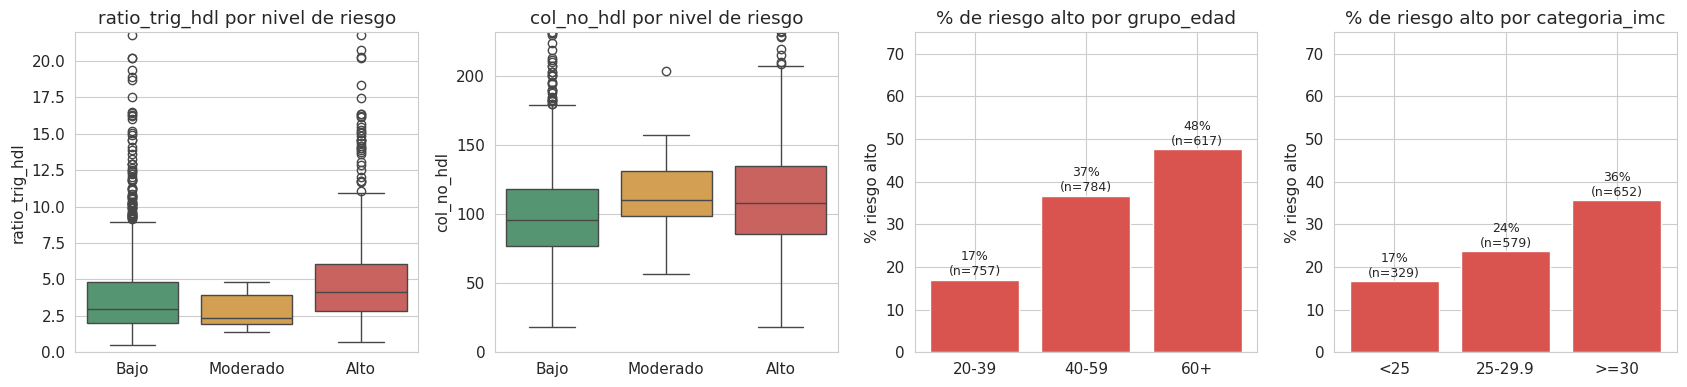

,Variable,Tipo,"AUC univariado (Alto vs resto, desarrollo)"
0,ratio_trig_hdl,Nueva,0.629
1,col_no_hdl,Nueva,0.596
2,imc_calc,Original,0.636
3,trig,Original,0.645
4,col_hdl,Original,0.512
5,colest,Original,0.583


In [44]:
fe_dev = ConstructorCaracteristicas().transform(X_dev)
fe_dev['riesgo'] = y_dev.map(ETIQ).values
fe_dev['alto'] = (y_dev.values == 2).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, col in zip(axes[:2], ['ratio_trig_hdl', 'col_no_hdl']):
    sns.boxplot(x='riesgo', y=col, data=fe_dev, order=NOMBRES_CLASES, hue='riesgo', palette=PAL, legend=False, ax=ax)
    ax.set_ylim(0, fe_dev[col].quantile(0.99) * 1.05); ax.set_xlabel(''); ax.set_title(f'{col} por nivel de riesgo')
for ax, col, orden in zip(axes[2:], ['grupo_edad', 'categoria_imc'], [ORDEN_GRUPO_EDAD, ORDEN_CATEGORIA_IMC]):
    tasa = fe_dev.groupby(col)['alto'].agg(['mean', 'size']).reindex(orden)
    ax.bar(orden, tasa['mean'] * 100, color=COLOR_ALTO)
    for i, (m, n) in enumerate(zip(tasa['mean'], tasa['size'])):
        ax.text(i, m * 100 + 1, f'{m*100:.0f}%\n(n={n})', ha='center', fontsize=9)
    ax.set_ylim(0, 75); ax.set_title(f'% de riesgo alto por {col}'); ax.set_ylabel('% riesgo alto')
plt.tight_layout(); guardar_fig('fig_ingenieria_caracteristicas'); plt.show()

auc_nuevas = []
for c in ['ratio_trig_hdl', 'col_no_hdl', 'imc_calc', 'trig', 'col_hdl', 'colest']:
    m = fe_dev[c].notna()
    auc = roc_auc_score(fe_dev.loc[m, 'alto'], fe_dev.loc[m, c])
    auc_nuevas.append([c, 'Nueva' if c in ('ratio_trig_hdl', 'col_no_hdl') else 'Original', round(max(auc, 1 - auc), 3)])
pd.DataFrame(auc_nuevas, columns=['Variable', 'Tipo', 'AUC univariado (Alto vs resto, desarrollo)'])

## 6. Estrategia de validación cruzada

| Parámetro | Valor |
|---|---|
| Método de validación | `StratifiedGroupKFold` repetido: estratificado por la variable objetivo y agrupado por hogar (`folio_i`) |
| Número de particiones | 5 |
| Número de repeticiones | 3 (semillas 42, 43 y 44), 15 ajustes por modelo |
| Semilla | 42 (partición prueba / desarrollo y primera repetición) |
| Conjunto usado | Desarrollo = entrenamiento + validación del avance (2,184 registros). La prueba (365) no participa |
| Métrica principal | ROC-AUC de la clase **riesgo alto** contra el resto (independiente del umbral) |
| Métricas secundarias | Recall, precision y F1 de la clase alto; F1 macro; accuracy; tiempo de entrenamiento e inferencia |

**Por qué es más estable que una sola partición.** Cada modelo se evalúa en 15 particiones distintas, así que se
obtiene una media y una desviación estándar en lugar de un número aislado; con 12 casos moderados y 840 altos, una
sola partición puede favorecer a un modelo por azar. La agrupación por hogar evita que una misma familia quede en
entrenamiento y evaluación. **Cómo se protege la prueba:** el conjunto de prueba se separó en la Parte I y solo se usa
en la sección 16, después de terminar la comparación, la selección de características, el ajuste de hiperparámetros
y la elección del umbral.

In [45]:
SEMILLAS_CV = [42, 43, 44]
SPLITS_REP = []
for s in SEMILLAS_CV:
    SPLITS_REP += list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=s).split(X_dev, y_dev, g_dev))
CV_5 = SPLITS_REP[:5]          # una repetición (para búsquedas de hiperparámetros y predicciones fuera de pliegue)
for tr, te in SPLITS_REP:
    assert not set(g_dev.iloc[tr]) & set(g_dev.iloc[te])
print('Particiones:', len(SPLITS_REP), '| casos alto por pliegue de evaluación:',
      sorted({int((y_dev.iloc[te] == 2).sum()) for _, te in SPLITS_REP}))


def _auc_alto(y_true, proba):
    return roc_auc_score((np.asarray(y_true) == 2).astype(int), proba[:, -1])   # última columna = clase 2

SCORER_AUC_ALTO = make_scorer(_auc_alto, response_method='predict_proba')
SCORERS = {
    'roc_auc_alto': SCORER_AUC_ALTO,
    'recall_alto': make_scorer(recall_score, labels=[2], average='macro', zero_division=0),
    'precision_alto': make_scorer(precision_score, labels=[2], average='macro', zero_division=0),
    'f1_alto': make_scorer(f1_score, labels=[2], average='macro', zero_division=0),
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy': 'accuracy',
}

REGISTRO = []          # registro de experimentos
RESULTADOS_CV = {}     # puntuaciones por pliegue para gráficas


def evaluar_cv(id_exp, nombre, pipe, hiper, pipeline_desc, splits=None, nota=''):
    """Valida con VC agrupada repetida, mide tiempos y agrega el experimento al registro."""
    splits = SPLITS_REP if splits is None else splits
    r = cross_validate(pipe, X_dev, y_dev, cv=splits, scoring=SCORERS, return_train_score=True)
    ajuste = clone(pipe).fit(X_dev, y_dev)
    t0 = time.perf_counter()
    for _ in range(3):
        ajuste.predict_proba(X_dev)
    inf_ms = (time.perf_counter() - t0) / 3 / len(X_dev) * 1000 * 1000     # ms por 1,000 registros
    fila = {'ID': id_exp, 'Modelo': nombre,
            'ROC-AUC alto (media)': r['test_roc_auc_alto'].mean(), 'ROC-AUC alto (desv.)': r['test_roc_auc_alto'].std(),
            'Recall alto': r['test_recall_alto'].mean(), 'Precision alto': r['test_precision_alto'].mean(),
            'F1 alto': r['test_f1_alto'].mean(), 'F1 macro': r['test_f1_macro'].mean(), 'Accuracy': r['test_accuracy'].mean(),
            'ROC-AUC alto (entren.)': r['train_roc_auc_alto'].mean(),
            'Tiempo entrenamiento (s)': r['fit_time'].mean(), 'Tiempo inferencia (ms/1000 reg.)': inf_ms,
            'Hiperparámetros': hiper}
    RESULTADOS_CV[nombre] = r['test_roc_auc_alto']
    REGISTRO.append({'ID': id_exp, 'Fecha': FECHA, 'Dataset': f'Diabetes_Mexico.csv (md5 {huella_csv[:10]}), desarrollo n={len(X_dev)}',
                     'Pipeline': pipeline_desc, 'Modelo': nombre, 'Hiperparámetros': hiper,
                     'Validación': f'StratifiedGroupKFold 5 x {len(splits) // 5} (hogar)',
                     'Métrica principal': 'ROC-AUC (alto vs resto)',
                     'Resultados': f"{fila['ROC-AUC alto (media)']:.3f} +/- {fila['ROC-AUC alto (desv.)']:.3f}; "
                                   f"recall {fila['Recall alto']:.3f}; F1 {fila['F1 alto']:.3f}" + (f' ({nota})' if nota else '')})
    return fila

PIPE_COMPLETO = 'Limpieza + ingeniería + winsor/log + One-Hot entidad (completo)'
PIPE_REDUCIDO = 'Limpieza + ingeniería + winsor/log, sin entidad (reducido)'
filas_comparacion = []

Particiones: 15 | casos alto por pliegue de evaluación: [144]


## 7. Modelos de referencia con el pipeline final

Se vuelven a ejecutar el `DummyClassifier`, la regresión logística y el árbol de decisión (segundo modelo inicial
del avance) con la misma configuración de hiperparámetros del avance, ahora con el pipeline consolidado y la
validación cruzada repetida.

In [46]:
REF = {
    'DummyClassifier': (DummyClassifier(strategy='stratified', random_state=RANDOM_STATE), "strategy='stratified'"),
    'Regresión logística': (LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
                            "C=1.0, class_weight='balanced'"),
    'Árbol de decisión': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, class_weight='balanced',
                                                 random_state=RANDOM_STATE), 'max_depth=5, min_samples_leaf=20, balanced'),
}
for i, (nombre, (mod, hip)) in enumerate(REF.items(), start=1):
    filas_comparacion.append(evaluar_cv(f'E{i:02d}', nombre, crear_pipeline_final(mod), hip, PIPE_COMPLETO))
pd.DataFrame(filas_comparacion).round(3)

,ID,Modelo,ROC-AUC alto (media),ROC-AUC alto (desv.),Recall alto,Precision alto,F1 alto,F1 macro,Accuracy,ROC-AUC alto (entren.),Tiempo entrenamiento (s),Tiempo inferencia (ms/1000 reg.),Hiperparámetros
0,E01,DummyClassifier,0.505,0.026,0.338,0.336,0.337,0.335,0.555,0.494,0.060,21.601,strategy='stratified'
1,E02,Regresión logística,0.723,0.022,0.642,0.507,0.566,0.416,0.599,0.746,0.096,23.088,"C=1.0, class_weight='balanced'"
2,E03,Árbol de decisión,0.674,0.033,0.608,0.467,0.525,0.395,0.566,0.749,0.057,18.466,"max_depth=5, min_samples_leaf=20, balanced"


## 8. Modelos de ensamble

**Random Forest.** Entrena cientos de árboles de decisión sobre muestras bootstrap y subconjuntos aleatorios de
variables, y promedia sus probabilidades. **Gradient Boosting (HistGradientBoosting).** Agrega árboles poco profundos
de forma secuencial; cada árbol corrige los errores de los anteriores.

| Aspecto | Random Forest | HistGradientBoosting |
|---|---|---|
| Ventaja frente a modelos iniciales | Captura interacciones y no linealidades (p. ej. triglicéridos altos + edad) y reduce la varianza del árbol individual | Suele lograr alta precisión con árboles pequeños y maneja faltantes de forma nativa |
| Riesgo de sobreajuste | Moderado: árboles profundos memorizan; se controla con `min_samples_leaf`, `max_depth`, `max_features` | Alto si hay muchas iteraciones o tasa de aprendizaje alta; se controla con `learning_rate`, `max_depth`, `max_iter` |
| Hiperparámetros principales | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`, `class_weight` | `learning_rate`, `max_iter`, `max_depth`, `l2_regularization` |
| Costo computacional | Medio (paraleliza por árbol) | Bajo a medio (histogramas) |
| Interpretabilidad | Media: importancias y SHAP exacto para árboles | Media: importancias y SHAP |

In [47]:
ENS = {
    'Random Forest': (RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight='balanced_subsample',
                                             random_state=RANDOM_STATE, n_jobs=-1),
                      "n_estimators=300, min_samples_leaf=5, balanced_subsample"),
    'Gradient Boosting (HGB)': (HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200,
                                                               class_weight='balanced', random_state=RANDOM_STATE),
                                'max_depth=3, learning_rate=0.05, max_iter=200, balanced'),
}
for i, (nombre, (mod, hip)) in enumerate(ENS.items(), start=4):
    filas_comparacion.append(evaluar_cv(f'E{i:02d}', nombre, crear_pipeline_final(mod), hip, PIPE_COMPLETO))
pd.DataFrame(filas_comparacion).round(3)

,ID,Modelo,ROC-AUC alto (media),ROC-AUC alto (desv.),Recall alto,Precision alto,F1 alto,F1 macro,Accuracy,ROC-AUC alto (entren.),Tiempo entrenamiento (s),Tiempo inferencia (ms/1000 reg.),Hiperparámetros
0,E01,DummyClassifier,0.505,0.026,0.338,0.336,0.337,0.335,0.555,0.494,0.060,21.601,strategy='stratified'
1,E02,Regresión logística,0.723,0.022,0.642,0.507,0.566,0.416,0.599,0.746,0.096,23.088,"C=1.0, class_weight='balanced'"
2,E03,Árbol de decisión,0.674,0.033,0.608,0.467,0.525,0.395,0.566,0.749,0.057,18.466,"max_depth=5, min_samples_leaf=20, balanced"
3,E04,Random Forest,0.756,0.026,0.579,0.546,0.561,0.444,0.699,0.978,1.001,75.189,"n_estimators=300, min_samples_leaf=5, balanced..."
4,E05,Gradient Boosting (HGB),0.746,0.026,0.642,0.515,0.571,0.439,0.679,0.932,0.485,37.784,"max_depth=3, learning_rate=0.05, max_iter=200,..."


## 9. Máquinas de soporte vectorial (SVM)

La SVM busca la frontera que separa las clases con el **margen** más amplio posible. Con kernel **lineal** la frontera
es un hiperplano; con kernel **RBF** los datos se proyectan implícitamente a un espacio de mayor dimensión y la frontera
puede ser curva. Se usa escalamiento estándar (ya incluido en el pipeline), `class_weight='balanced'` y
`probability=True` (calibración de Platt) para obtener probabilidades y poder aplicar un umbral.

In [48]:
SVMS = {
    'SVM lineal': (SVC(kernel='linear', C=0.1, probability=True, class_weight='balanced', random_state=RANDOM_STATE),
                   "kernel='linear', C=0.1, balanced"),
    'SVM RBF': (SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
                "kernel='rbf', C=1.0, gamma='scale', balanced"),
}
for i, (nombre, (mod, hip)) in enumerate(SVMS.items(), start=6):
    filas_comparacion.append(evaluar_cv(f'E{i:02d}', nombre, crear_pipeline_final(mod), hip, PIPE_COMPLETO))
pd.DataFrame(filas_comparacion).round(3)

,ID,Modelo,ROC-AUC alto (media),ROC-AUC alto (desv.),Recall alto,Precision alto,F1 alto,F1 macro,Accuracy,ROC-AUC alto (entren.),Tiempo entrenamiento (s),Tiempo inferencia (ms/1000 reg.),Hiperparámetros
0,E01,DummyClassifier,0.505,0.026,0.338,0.336,0.337,0.335,0.555,0.494,0.060,21.601,strategy='stratified'
1,E02,Regresión logística,0.723,0.022,0.642,0.507,0.566,0.416,0.599,0.746,0.096,23.088,"C=1.0, class_weight='balanced'"
2,E03,Árbol de decisión,0.674,0.033,0.608,0.467,0.525,0.395,0.566,0.749,0.057,18.466,"max_depth=5, min_samples_leaf=20, balanced"
3,E04,Random Forest,0.756,0.026,0.579,0.546,0.561,0.444,0.699,0.978,1.001,75.189,"n_estimators=300, min_samples_leaf=5, balanced..."
4,E05,Gradient Boosting (HGB),0.746,0.026,0.642,0.515,0.571,0.439,0.679,0.932,0.485,37.784,"max_depth=3, learning_rate=0.05, max_iter=200,..."
5,E06,SVM lineal,0.752,0.023,0.684,0.498,0.576,0.412,0.589,0.769,0.390,59.239,"kernel='linear', C=0.1, balanced"
6,E07,SVM RBF,0.764,0.026,0.734,0.509,0.601,0.443,0.674,0.841,0.491,122.672,"kernel='rbf', C=1.0, gamma='scale', balanced"


**Efecto de C y gamma.** Las curvas de validación muestran el ROC-AUC en entrenamiento y en validación cruzada
al variar un hiperparámetro y dejar fijo el otro.

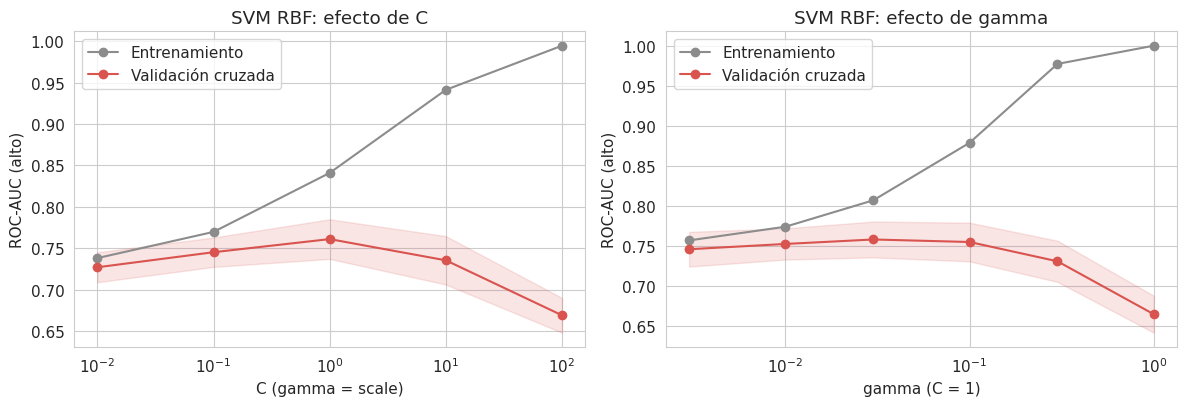

,C,AUC entrenamiento,AUC VC
0,0.01,0.738,0.727
1,0.10,0.770,0.745
2,1.00,0.841,0.761
3,10.00,0.941,0.735
4,100.00,0.995,0.669


In [49]:
base_rbf = crear_pipeline_final(SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE))
rango_C = [0.01, 0.1, 1, 10, 100]
rango_gamma = [0.003, 0.01, 0.03, 0.1, 0.3, 1]
tr_C, va_C = validation_curve(base_rbf, X_dev, y_dev, param_name='modelo__C', param_range=rango_C,
                              cv=CV_5, scoring=SCORER_AUC_ALTO)
tr_g, va_g = validation_curve(base_rbf.set_params(modelo__C=1.0), X_dev, y_dev, param_name='modelo__gamma',
                              param_range=rango_gamma, cv=CV_5, scoring=SCORER_AUC_ALTO)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, rango, tr, va, nom in [(axes[0], rango_C, tr_C, va_C, 'C (gamma = scale)'),
                               (axes[1], rango_gamma, tr_g, va_g, 'gamma (C = 1)')]:
    ax.semilogx(rango, tr.mean(1), 'o-', color=COLOR_GRIS, label='Entrenamiento')
    ax.semilogx(rango, va.mean(1), 'o-', color=COLOR_ALTO, label='Validación cruzada')
    ax.fill_between(rango, va.mean(1) - va.std(1), va.mean(1) + va.std(1), color=COLOR_ALTO, alpha=0.15)
    ax.set_xlabel(nom); ax.set_ylabel('ROC-AUC (alto)'); ax.set_title(f'SVM RBF: efecto de {nom.split()[0]}'); ax.legend()
plt.tight_layout(); guardar_fig('fig_svm_curvas_validacion'); plt.show()
pd.DataFrame({'C': rango_C, 'AUC entrenamiento': tr_C.mean(1).round(3), 'AUC VC': va_C.mean(1).round(3)})

## 10. Comparación de familias de modelos

Se agrega como modelo opcional una **red neuronal multicapa** (`MLPClassifier`): 2 capas ocultas (32 y 16 neuronas),
activación ReLU, optimizador Adam, regularización L2 (`alpha=0.01`) y parada temprana (`early_stopping=True`,
10% interno de validación, 10 iteraciones sin mejora). Limitación: `MLPClassifier` no admite `class_weight`, por lo
que no compensa el desbalance.

In [50]:
filas_comparacion.append(evaluar_cv(
    'E08', 'Red neuronal (MLP)',
    crear_pipeline_final(MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', alpha=1e-2,
                                       early_stopping=True, max_iter=500, random_state=RANDOM_STATE)),
    'capas=(32,16), relu, alpha=0.01, early_stopping', PIPE_COMPLETO))

tabla_comparacion = pd.DataFrame(filas_comparacion)
familia = {'DummyClassifier': 'Referencia trivial', 'Regresión logística': 'Lineal', 'Árbol de decisión': 'Árbol',
           'Random Forest': 'Ensamble', 'Gradient Boosting (HGB)': 'Ensamble', 'SVM lineal': 'Márgenes',
           'SVM RBF': 'Márgenes', 'Red neuronal (MLP)': 'Opcional (red neuronal)'}
tabla_comparacion.insert(2, 'Familia', tabla_comparacion['Modelo'].map(familia))
tabla_comparacion.to_csv(DIR_RES / 'comparacion_modelos.csv', index=False)
cols_ver = ['Modelo', 'Familia', 'ROC-AUC alto (media)', 'ROC-AUC alto (desv.)', 'Recall alto', 'Precision alto', 'F1 alto',
            'F1 macro', 'ROC-AUC alto (entren.)', 'Tiempo entrenamiento (s)', 'Tiempo inferencia (ms/1000 reg.)', 'Hiperparámetros']
tabla_comparacion[cols_ver].round(3)

,Modelo,Familia,ROC-AUC alto (media),ROC-AUC alto (desv.),Recall alto,Precision alto,F1 alto,F1 macro,ROC-AUC alto (entren.),Tiempo entrenamiento (s),Tiempo inferencia (ms/1000 reg.),Hiperparámetros
0,DummyClassifier,Referencia trivial,0.505,0.026,0.338,0.336,0.337,0.335,0.494,0.060,21.601,strategy='stratified'
1,Regresión logística,Lineal,0.723,0.022,0.642,0.507,0.566,0.416,0.746,0.096,23.088,"C=1.0, class_weight='balanced'"
2,Árbol de decisión,Árbol,0.674,0.033,0.608,0.467,0.525,0.395,0.749,0.057,18.466,"max_depth=5, min_samples_leaf=20, balanced"
3,Random Forest,Ensamble,0.756,0.026,0.579,0.546,0.561,0.444,0.978,1.001,75.189,"n_estimators=300, min_samples_leaf=5, balanced..."
4,Gradient Boosting (HGB),Ensamble,0.746,0.026,0.642,0.515,0.571,0.439,0.932,0.485,37.784,"max_depth=3, learning_rate=0.05, max_iter=200,..."
5,SVM lineal,Márgenes,0.752,0.023,0.684,0.498,0.576,0.412,0.769,0.390,59.239,"kernel='linear', C=0.1, balanced"
6,SVM RBF,Márgenes,0.764,0.026,0.734,0.509,0.601,0.443,0.841,0.491,122.672,"kernel='rbf', C=1.0, gamma='scale', balanced"
7,Red neuronal (MLP),Opcional (red neuronal),0.720,0.033,0.306,0.586,0.378,0.389,0.743,0.147,19.365,"capas=(32,16), relu, alpha=0.01, early_stopping"


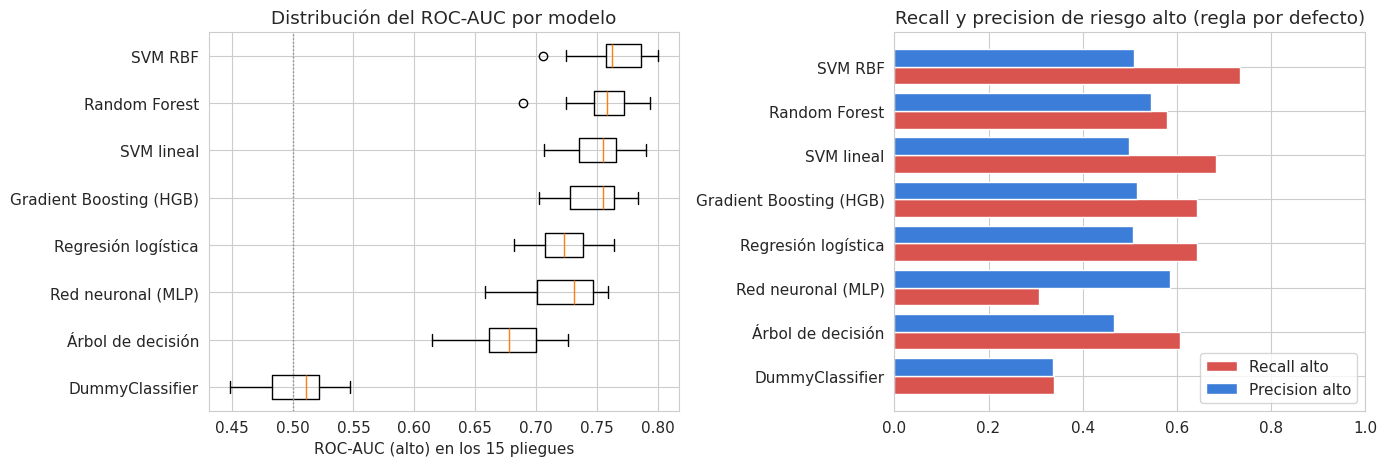

In [51]:
orden_m = tabla_comparacion.sort_values('ROC-AUC alto (media)')['Modelo']
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].boxplot([RESULTADOS_CV[m] for m in orden_m], vert=False, tick_labels=list(orden_m))
axes[0].axvline(0.5, color=COLOR_GRIS, ls=':', lw=1)
axes[0].set_xlabel('ROC-AUC (alto) en los 15 pliegues'); axes[0].set_title('Distribución del ROC-AUC por modelo')
t = tabla_comparacion.set_index('Modelo').loc[orden_m]
yy = np.arange(len(t))
axes[1].barh(yy - 0.2, t['Recall alto'], height=0.4, color=COLOR_ALTO, label='Recall alto')
axes[1].barh(yy + 0.2, t['Precision alto'], height=0.4, color=COLOR_RESTO, label='Precision alto')
axes[1].set_yticks(yy, t.index); axes[1].set_xlim(0, 1)
axes[1].set_title('Recall y precision de riesgo alto (regla por defecto)'); axes[1].legend(loc='lower right')
plt.tight_layout(); guardar_fig('fig_comparacion_modelos'); plt.show()

## 11. Selección y reducción de características

Se aplican dos enfoques, ambos **dentro del flujo de entrenamiento** (se ajustan en cada pliegue solo con los datos
de entrenamiento de ese pliegue):

1. **SelectFromModel** con la importancia de un Random Forest (umbral = mediana de las importancias): conserva la mitad
   de las columnas transformadas más importantes.
2. **Modelo reducido sin entidad federativa**: se quitan las columnas One-Hot de `entidad_cve` (la mayoría descartadas
   por SelectFromModel) y se conservan las 15 variables clínicas y demográficas.

Se comparan con el modelo completo usando los dos mejores modelos de la sección anterior.

In [52]:
def selector_rf():
    return SelectFromModel(RandomForestClassifier(n_estimators=200, min_samples_leaf=5, class_weight='balanced_subsample',
                                                  random_state=RANDOM_STATE, n_jobs=-1), threshold='median')

svm_rbf_base = lambda: SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
rf_base = lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight='balanced_subsample',
                                         random_state=RANDOM_STATE, n_jobs=-1)
configs_sel = [
    ('E09', 'SVM RBF + SelectFromModel(RF)', crear_pipeline_final(svm_rbf_base(), seleccion=selector_rf()),
     'SelectFromModel(RF, threshold=median)', PIPE_COMPLETO + ' + SelectFromModel'),
    ('E10', 'SVM RBF reducido (sin entidad)', crear_pipeline_final(svm_rbf_base(), incluir_entidad=False),
     "kernel='rbf', C=1.0, gamma='scale'", PIPE_REDUCIDO),
    ('E11', 'Random Forest reducido (sin entidad)', crear_pipeline_final(rf_base(), incluir_entidad=False),
     'n_estimators=300, min_samples_leaf=5', PIPE_REDUCIDO),
    ('E12', 'SVM RBF sin ingeniería de características', crear_pipeline_final(svm_rbf_base(), incluir_entidad=False,
                                                                                con_ingenieria=False),
     "kernel='rbf', C=1.0, gamma='scale'", 'Reducido sin variables nuevas (ablación)'),
]
filas_sel = [evaluar_cv(i, n, p, h, d) for i, n, p, h, d in configs_sel]


def n_columnas(pipe):
    p = clone(pipe).fit(X_dev, y_dev)
    n = p.named_steps['preprocesamiento'].transform(p.named_steps['limpieza_ingenieria'].transform(X_dev.head(2))).shape[1]
    if 'seleccion' in p.named_steps:
        sel = p.named_steps['seleccion'].get_support()
        return int(sel.sum()), [c for c, s in zip(nombres_limpios(p), sel) if s]
    return n, nombres_limpios(p)

n_sel, cols_sel = n_columnas(configs_sel[0][2])
n_full, _ = n_columnas(crear_pipeline_final(svm_rbf_base()))
n_red, cols_red = n_columnas(configs_sel[1][2])
print(f'SelectFromModel conservó {n_sel} de {n_full} columnas:', cols_sel)
entidades_descartadas = sum(c.startswith('entidad') for c in nombres_limpios(clone(configs_sel[0][2]).fit(X_dev, y_dev))) - \
    sum(c.startswith('entidad') for c in cols_sel)
print('Columnas de entidad descartadas por SelectFromModel:', entidades_descartadas)

fc = {f['Modelo']: f for f in filas_comparacion + filas_sel}
tabla_seleccion = pd.DataFrame([
    ['SVM RBF - modelo completo', n_full, fc['SVM RBF']['ROC-AUC alto (media)'], fc['SVM RBF']['ROC-AUC alto (desv.)'],
     fc['SVM RBF']['Tiempo entrenamiento (s)'], 'Media: 12 variables clínicas + entidades One-Hot'],
    ['SVM RBF + SelectFromModel', n_sel, fc['SVM RBF + SelectFromModel(RF)']['ROC-AUC alto (media)'],
     fc['SVM RBF + SelectFromModel(RF)']['ROC-AUC alto (desv.)'], fc['SVM RBF + SelectFromModel(RF)']['Tiempo entrenamiento (s)'],
     'Media: la selección cambia en cada reentrenamiento'],
    ['SVM RBF - modelo reducido (sin entidad)', n_red, fc['SVM RBF reducido (sin entidad)']['ROC-AUC alto (media)'],
     fc['SVM RBF reducido (sin entidad)']['ROC-AUC alto (desv.)'], fc['SVM RBF reducido (sin entidad)']['Tiempo entrenamiento (s)'],
     'Alta: solo variables clínicas y demográficas'],
    ['Random Forest - modelo completo', n_full, fc['Random Forest']['ROC-AUC alto (media)'], fc['Random Forest']['ROC-AUC alto (desv.)'],
     fc['Random Forest']['Tiempo entrenamiento (s)'], 'Media'],
    ['Random Forest - modelo reducido (sin entidad)', n_red, fc['Random Forest reducido (sin entidad)']['ROC-AUC alto (media)'],
     fc['Random Forest reducido (sin entidad)']['ROC-AUC alto (desv.)'], fc['Random Forest reducido (sin entidad)']['Tiempo entrenamiento (s)'],
     'Alta'],
    ['SVM RBF reducido sin ingeniería (ablación)', n_columnas(configs_sel[3][2])[0],
     fc['SVM RBF sin ingeniería de características']['ROC-AUC alto (media)'],
     fc['SVM RBF sin ingeniería de características']['ROC-AUC alto (desv.)'],
     fc['SVM RBF sin ingeniería de características']['Tiempo entrenamiento (s)'], 'Alta'],
], columns=['Configuración', 'Número de características', 'ROC-AUC alto (media)', 'ROC-AUC alto (desv.)',
            'Tiempo entrenamiento (s)', 'Interpretabilidad'])
tabla_seleccion.to_csv(DIR_RES / 'seleccion_caracteristicas.csv', index=False)
tabla_seleccion.round(3)

SelectFromModel conservó 21 de 41 columnas: ['edad', 'imc_calc', 'ac_urico', 'albu', 'col_hdl', 'col_ldl', 'colest', 'col_no_hdl', 'creat', 'insulina', 'trig', 'ratio_trig_hdl', 'sexo_Mujer', 'grupo_edad', 'categoria_imc', 'entidad_cve_01', 'entidad_cve_02', 'entidad_cve_10', 'entidad_cve_16', 'entidad_cve_20', 'entidad_cve_27']


Columnas de entidad descartadas por SelectFromModel: 20


,Configuración,Número de características,ROC-AUC alto (media),ROC-AUC alto (desv.),Tiempo entrenamiento (s),Interpretabilidad
0,SVM RBF - modelo completo,41,0.764,0.026,0.491,Media: 12 variables clínicas + entidades One-Hot
1,SVM RBF + SelectFromModel,21,0.761,0.027,1.103,Media: la selección cambia en cada reentrenami...
2,SVM RBF - modelo reducido (sin entidad),15,0.762,0.028,0.450,Alta: solo variables clínicas y demográficas
3,Random Forest - modelo completo,41,0.756,0.026,1.001,Media
4,Random Forest - modelo reducido (sin entidad),15,0.755,0.027,1.029,Alta
5,SVM RBF reducido sin ingeniería (ablación),11,0.763,0.028,0.411,Alta


## 12. Ajuste de hiperparámetros

Se ajustan los dos modelos avanzados sobre el **pipeline reducido**, con la primera repetición de la validación
cruzada agrupada (5 pliegues) y ROC-AUC de la clase alto como criterio. La prueba no se usa.

* **SVM RBF - GridSearchCV:** `C` en {0.1, 0.3, 1, 3, 10} x `gamma` en {scale, 0.01, 0.03, 0.1} = 20 combinaciones (100 ajustes).
* **SVM lineal - GridSearchCV:** `C` en {0.01, 0.03, 0.1, 0.3, 1} = 5 combinaciones (25 ajustes).
* **Random Forest - RandomizedSearchCV:** 20 combinaciones aleatorias de un espacio de 180 (`n_estimators`,
  `max_depth`, `min_samples_leaf`, `max_features`), 100 ajustes.

In [53]:
busquedas = {}
t0 = time.perf_counter()
gs_svm = GridSearchCV(crear_pipeline_final(SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
                                           incluir_entidad=False),
                      {'modelo__C': [0.1, 0.3, 1, 3, 10], 'modelo__gamma': ['scale', 0.01, 0.03, 0.1]},
                      scoring=SCORER_AUC_ALTO, cv=CV_5, n_jobs=-1)
gs_svm.fit(X_dev, y_dev); busquedas['SVM RBF'] = (gs_svm, time.perf_counter() - t0)

t0 = time.perf_counter()
gs_lin = GridSearchCV(crear_pipeline_final(SVC(kernel='linear', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
                                           incluir_entidad=False),
                      {'modelo__C': [0.01, 0.03, 0.1, 0.3, 1]}, scoring=SCORER_AUC_ALTO, cv=CV_5, n_jobs=-1)
gs_lin.fit(X_dev, y_dev); busquedas['SVM lineal'] = (gs_lin, time.perf_counter() - t0)

t0 = time.perf_counter()
rs_rf = RandomizedSearchCV(crear_pipeline_final(RandomForestClassifier(class_weight='balanced_subsample', random_state=RANDOM_STATE,
                                                                       n_jobs=1), incluir_entidad=False),
                           {'modelo__n_estimators': [200, 400, 600], 'modelo__max_depth': [None, 6, 10, 16],
                            'modelo__min_samples_leaf': [1, 3, 5, 10, 20], 'modelo__max_features': ['sqrt', 0.3, 0.5]},
                           n_iter=20, scoring=SCORER_AUC_ALTO, cv=CV_5, random_state=RANDOM_STATE, n_jobs=-1)
rs_rf.fit(X_dev, y_dev); busquedas['Random Forest'] = (rs_rf, time.perf_counter() - t0)

espacios = {'SVM RBF': 'C {0.1,0.3,1,3,10} x gamma {scale,0.01,0.03,0.1}', 'SVM lineal': 'C {0.01,0.03,0.1,0.3,1}',
            'Random Forest': 'n_estimators {200,400,600}, max_depth {None,6,10,16}, min_samples_leaf {1,3,5,10,20}, max_features {sqrt,0.3,0.5}'}
tabla_ajuste = pd.DataFrame([[m, espacios[m], len(b.cv_results_['params']),
                              {k.replace('modelo__', ''): v for k, v in b.best_params_.items()},
                              round(b.best_score_, 3), round(b.cv_results_['std_test_score'][b.best_index_], 3), round(t, 1)]
                             for m, (b, t) in busquedas.items()],
                            columns=['Modelo', 'Hiperparámetros explorados', 'Combinaciones', 'Mejor configuración',
                                     'ROC-AUC alto VC (mejor)', 'Desv.', 'Tiempo total (s)'])
tabla_ajuste.to_csv(DIR_RES / 'ajuste_hiperparametros.csv', index=False)
for m, (b, _) in busquedas.items():
    REGISTRO.append({'ID': f"B-{m.replace(' ', '')}", 'Fecha': FECHA, 'Dataset': f'Diabetes_Mexico.csv, desarrollo n={len(X_dev)}',
                     'Pipeline': PIPE_REDUCIDO, 'Modelo': f'{m} ({type(b).__name__})', 'Hiperparámetros': espacios[m],
                     'Validación': 'StratifiedGroupKFold 5 x 1 (hogar)', 'Métrica principal': 'ROC-AUC (alto vs resto)',
                     'Resultados': f"mejor {b.best_score_:.3f} con {({k.replace('modelo__', ''): v for k, v in b.best_params_.items()})}"})
tabla_ajuste

,Modelo,Hiperparámetros explorados,Combinaciones,Mejor configuración,ROC-AUC alto VC (mejor),Desv.,Tiempo total (s)
0,SVM RBF,"C {0.1,0.3,1,3,10} x gamma {scale,0.01,0.03,0.1}",20,"{'C': 3, 'gamma': 0.03}",0.760,0.027,31.4
1,SVM lineal,"C {0.01,0.03,0.1,0.3,1}",5,{'C': 0.1},0.747,0.023,7.3
2,Random Forest,"n_estimators {200,400,600}, max_depth {None,6,...",20,"{'n_estimators': 400, 'min_samples_leaf': 3, '...",0.757,0.024,67.1


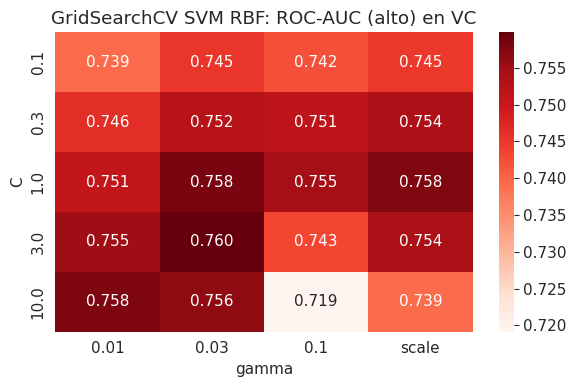

In [54]:
res_svm = pd.DataFrame(gs_svm.cv_results_)
mapa = res_svm.pivot_table(index='param_modelo__C', columns=res_svm['param_modelo__gamma'].astype(str), values='mean_test_score')
plt.figure(figsize=(6, 4))
sns.heatmap(mapa, annot=True, fmt='.3f', cmap='Reds')
plt.title('GridSearchCV SVM RBF: ROC-AUC (alto) en VC'); plt.xlabel('gamma'); plt.ylabel('C')
plt.tight_layout(); guardar_fig('fig_grid_svm'); plt.show()

Las mejores configuraciones se vuelven a validar con la VC **repetida** (15 pliegues) para compararlas en igualdad
de condiciones con el resto de los experimentos.

In [55]:
mejor_svm = gs_svm.best_estimator_
mejor_lin = gs_lin.best_estimator_
mejor_rf = rs_rf.best_estimator_
hp = lambda b: ', '.join(f"{k.replace('modelo__', '')}={v}" for k, v in b.best_params_.items())
filas_ajustados = [
    evaluar_cv('E13', 'SVM RBF ajustado (reducido)', clone(mejor_svm), hp(gs_svm), PIPE_REDUCIDO),
    evaluar_cv('E14', 'SVM lineal ajustado (reducido)', clone(mejor_lin), hp(gs_lin), PIPE_REDUCIDO),
    evaluar_cv('E15', 'Random Forest ajustado (reducido)', clone(mejor_rf), hp(rs_rf), PIPE_REDUCIDO),
    evaluar_cv('E16', 'Regresión logística (reducido)',
               crear_pipeline_final(LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
                                    incluir_entidad=False), "C=1.0, class_weight='balanced'", PIPE_REDUCIDO),
]
pd.DataFrame(filas_ajustados)[[c for c in cols_ver if c != 'Familia']].round(3)

,Modelo,ROC-AUC alto (media),ROC-AUC alto (desv.),Recall alto,Precision alto,F1 alto,F1 macro,ROC-AUC alto (entren.),Tiempo entrenamiento (s),Tiempo inferencia (ms/1000 reg.),Hiperparámetros
0,SVM RBF ajustado (reducido),0.764,0.027,0.710,0.506,0.590,0.434,0.818,0.462,79.939,"C=3, gamma=0.03"
1,SVM lineal ajustado (reducido),0.749,0.022,0.585,0.493,0.533,0.367,0.757,0.447,51.699,C=0.1
2,Random Forest ajustado (reducido),0.758,0.026,0.491,0.569,0.526,0.438,0.999,1.597,65.446,"n_estimators=400, min_samples_leaf=3, max_feat..."
3,Regresión logística (reducido),0.713,0.027,0.591,0.501,0.541,0.378,0.722,0.074,21.033,"C=1.0, class_weight='balanced'"


## 13. Registro de experimentos

Todos los experimentos anteriores quedaron registrados automáticamente (función `evaluar_cv` y búsquedas) y se
guardan en `results/registro_experimentos.csv`, de modo que otra persona pueda reconstruir qué se probó, con qué
configuración y con qué resultado.

In [56]:
registro_df = pd.DataFrame(REGISTRO)
registro_df.to_csv(DIR_RES / 'registro_experimentos.csv', index=False)
pd.set_option('display.max_colwidth', 90)
registro_df

,ID,Fecha,Dataset,Pipeline,Modelo,Hiperparámetros,Validación,Métrica principal,Resultados
0,E01,2026-09-30,"Diabetes_Mexico.csv (md5 eb696bc3e9), desarrollo n=2184",Limpieza + ingeniería + winsor/log + One-Hot entidad (completo),DummyClassifier,strategy='stratified',StratifiedGroupKFold 5 x 3 (hogar),ROC-AUC (alto vs resto),0.505 +/- 0.026; recall 0.338; F1 0.337
1,E02,2026-09-30,"Diabetes_Mexico.csv (md5 eb696bc3e9), desarrollo n=2184",Limpieza + ingeniería + winsor/log + One-Hot entidad (completo),Regresión logística,"C=1.0, class_weight='balanced'",StratifiedGroupKFold 5 x 3 (hogar),ROC-AUC (alto vs resto),0.723 +/- 0.022; recall 0.642; F1 0.566
2,E03,2026-09-30,"Diabetes_Mexico.csv (md5 eb696bc3e9), desarrollo n=2184",Limpieza + ingeniería + winsor/log + One-Hot entidad (completo),Árbol de decisión,"max_depth=5, min_samples_leaf=20, balanced",StratifiedGroupKFold 5 x 3 (hogar),ROC-AUC (alto vs resto),0.674 +/- 0.033; recall 0.608; F1 0.525
3,E04,2026-09-30,"Diabetes_Mexico.csv (md5 eb696bc3e9), desarrollo n=2184",Limpieza + ingeniería + winsor/log + One-Hot entidad (completo),Random Forest,"n_estimators=300, min_samples_leaf=5, balanced_subsample",StratifiedGroupKFold 5 x 3 (hogar),ROC-AUC (alto vs resto),0.756 +/- 0.026; recall 0.579; F1 0.561
4,E05,2026-09-30,"Diabetes_Mexico.csv (md5 eb696bc3e9), desarrollo n=2184",Limpieza + ingeniería + winsor/log + One-Hot entidad (completo),Gradient Boosting (HGB),"max_depth=3, learning_rate=0.05, max_iter=200, balanced",StratifiedGroupKFold 5 x 3 (hogar),ROC-AUC (alto vs resto),0.746 +/- 0.026; recall 0.642; F1 0.571
5,E06,2026-09-30,"Diabetes_Mexico.csv (md5 eb696bc3e9), desarrollo n=2184",Limpieza + ingeniería + winsor/log + One-Hot entidad (completo),SVM lineal,"kernel='linear', C=0.1, balanced",StratifiedGroupKFold 5 x 3 (hogar),ROC-AUC (alto vs resto),0.752 +/- 0.023; recall 0.684; F1 0.576
6,E07,2026-09-30,"Diabetes_Mexico.csv (md5 eb696bc3e9), desarrollo n=2184",Limpieza + ingeniería + winsor/log + One-Hot entidad (completo),SVM RBF,"kernel='rbf', C=1.0, gamma='scale', balanced",StratifiedGroupKFold 5 x 3 (hogar),ROC-AUC (alto vs resto),0.764 +/- 0.026; recall 0.734; F1 0.601
7,E08,2026-09-30,"Diabetes_Mexico.csv (md5 eb696bc3e9), desarrollo n=2184",Limpieza + ingeniería + winsor/log + One-Hot entidad (completo),Red neuronal (MLP),"capas=(32,16), relu, alpha=0.01, early_stopping",StratifiedGroupKFold 5 x 3 (hogar),ROC-AUC (alto vs resto),0.720 +/- 0.033; recall 0.306; F1 0.378
8,E09,2026-09-30,"Diabetes_Mexico.csv (md5 eb696bc3e9), desarrollo n=2184",Limpieza + ingeniería + winsor/log + One-Hot entidad (completo) + SelectFromModel,SVM RBF + SelectFromModel(RF),"SelectFromModel(RF, threshold=median)",StratifiedGroupKFold 5 x 3 (hogar),ROC-AUC (alto vs resto),0.761 +/- 0.027; recall 0.734; F1 0.600
9,E10,2026-09-30,"Diabetes_Mexico.csv (md5 eb696bc3e9), desarrollo n=2184","Limpieza + ingeniería + winsor/log, sin entidad (reducido)",SVM RBF reducido (sin entidad),"kernel='rbf', C=1.0, gamma='scale'",StratifiedGroupKFold 5 x 3 (hogar),ROC-AUC (alto vs resto),0.762 +/- 0.028; recall 0.731; F1 0.600


## 14. Modelos finalistas y matriz de decisión

Se eligen como finalistas los dos mejores modelos ajustados de familias distintas: **SVM RBF ajustado** (márgenes) y
**Random Forest ajustado** (ensamble), ambos con el pipeline reducido. La decisión no se toma solo por la métrica
más alta: se construye una matriz ponderada (suma de pesos = 100%).

**Regla de puntuación (escala 1 a 5).** Métricas de desempeño: 1 + 4 x (valor - valor del Dummy) / (mejor valor - valor del Dummy).
Estabilidad: 5 x (menor desviación / desviación del modelo). Interpretabilidad y costo operativo: valoración
justificada con evidencia medida (tiempo de inferencia, tamaño del artefacto y disponibilidad de explicaciones).

In [57]:
F = {f['Modelo']: f for f in filas_comparacion + filas_sel + filas_ajustados}
fin_a, fin_b = 'SVM RBF ajustado (reducido)', 'Random Forest ajustado (reducido)'
FINALISTAS = {fin_a: mejor_svm, fin_b: mejor_rf}
dummy = F['DummyClassifier']

def punt_metrica(clave):
    va, vb, vd = F[fin_a][clave], F[fin_b][clave], dummy[clave]
    mejor = max(va, vb)
    return [round(1 + 4 * (v - vd) / (mejor - vd), 2) for v in (va, vb)], (va, vb)

def tam_mb(pipe):
    ruta_tmp = DIR_ART / '_tmp.joblib'; joblib.dump(pipe, ruta_tmp); t = ruta_tmp.stat().st_size / 1e6; ruta_tmp.unlink(); return t

tam = {m: tam_mb(clone(p).fit(X_dev, y_dev)) for m, p in FINALISTAS.items()}
filas_md = []
pesos = {'Recall': 25, 'Precision': 10, 'F1-score': 15, 'ROC-AUC': 20, 'Estabilidad': 10, 'Interpretabilidad': 10, 'Costo operativo': 10}
for crit, clave in [('Recall', 'Recall alto'), ('Precision', 'Precision alto'), ('F1-score', 'F1 alto'), ('ROC-AUC', 'ROC-AUC alto (media)')]:
    (pa, pb), (va, vb) = punt_metrica(clave)
    filas_md.append([crit, pesos[crit], pa, pb, f'VC repetida: {va:.3f} vs {vb:.3f} (Dummy {dummy[clave]:.3f})'])
sa, sb = F[fin_a]['ROC-AUC alto (desv.)'], F[fin_b]['ROC-AUC alto (desv.)']
filas_md.append(['Estabilidad', pesos['Estabilidad'], round(5 * min(sa, sb) / sa, 2), round(5 * min(sa, sb) / sb, 2),
                 f'Desv. del ROC-AUC en 15 pliegues: {sa:.3f} vs {sb:.3f}'])
filas_md.append(['Interpretabilidad', pesos['Interpretabilidad'], 3, 4,
                 'RF: importancias nativas y SHAP exacto para árboles; SVM RBF: solo métodos agnósticos (permutación, KernelSHAP)'])
ia, ib = F[fin_a]['Tiempo inferencia (ms/1000 reg.)'], F[fin_b]['Tiempo inferencia (ms/1000 reg.)']
costo_a = 5 if (tam[fin_a] < tam[fin_b] and ia < ib) else 4
costo_b = 5 if costo_a == 4 else 4
filas_md.append(['Costo operativo', pesos['Costo operativo'], costo_a, costo_b,
                 f'Inferencia {ia:.0f} vs {ib:.0f} ms/1000 reg.; artefacto {tam[fin_a]:.2f} vs {tam[fin_b]:.2f} MB; '
                 f'entrenamiento {F[fin_a]["Tiempo entrenamiento (s)"]:.1f} vs {F[fin_b]["Tiempo entrenamiento (s)"]:.1f} s'])
matriz = pd.DataFrame(filas_md, columns=['Criterio', 'Peso (%)', fin_a, fin_b, 'Justificación / evidencia'])
assert matriz['Peso (%)'].sum() == 100
total = {m: round((matriz[m] * matriz['Peso (%)']).sum() / 100, 2) for m in (fin_a, fin_b)}
matriz.loc[len(matriz)] = ['TOTAL PONDERADO', 100, total[fin_a], total[fin_b], 'Suma de puntuación x peso / 100']
NOMBRE_PRELIM = max(total, key=total.get)
matriz.to_csv(DIR_RES / 'matriz_decision.csv', index=False)
print('Modelo preferido por la matriz de decisión:', NOMBRE_PRELIM)
matriz

Modelo preferido por la matriz de decisión: SVM RBF ajustado (reducido)


,Criterio,Peso (%),SVM RBF ajustado (reducido),Random Forest ajustado (reducido),Justificación / evidencia
0,Recall,25,5.00,2.64,VC repetida: 0.710 vs 0.491 (Dummy 0.338)
1,Precision,10,3.92,5.00,VC repetida: 0.506 vs 0.569 (Dummy 0.336)
2,F1-score,15,5.00,3.98,VC repetida: 0.590 vs 0.526 (Dummy 0.337)
3,ROC-AUC,20,5.00,4.91,VC repetida: 0.764 vs 0.758 (Dummy 0.505)
4,Estabilidad,10,4.90,5.00,Desv. del ROC-AUC en 15 pliegues: 0.027 vs 0.026
5,Interpretabilidad,10,3.00,4.00,RF: importancias nativas y SHAP exacto para árboles; SVM RBF: solo métodos agnósticos ...
6,Costo operativo,10,4.00,5.00,Inferencia 80 vs 65 ms/1000 reg.; artefacto 0.27 vs 18.16 MB; entrenamiento 0.5 vs 1.6 s
7,TOTAL PONDERADO,100,4.58,4.14,Suma de puntuación x peso / 100


## 15. Optimización del umbral de decisión (sin usar la prueba)

El umbral se elige con **predicciones fuera de pliegue** del conjunto de desarrollo (cada paciente es evaluado por un
modelo que no lo vio). La decisión operativa es binaria: *prioridad alta* si P(riesgo alto) >= umbral.

**Criterio principal (restricción mínima de recall):** detectar al menos el **80%** de los pacientes de riesgo alto
(un falso negativo deja sin seguimiento a una persona en riesgo), y entre los umbrales que lo cumplen elegir el más alto
(el que genera menos falsos positivos). Como referencia se calculan también el índice de Youden y el umbral de costo
mínimo suponiendo que un falso negativo cuesta 3 veces más que un falso positivo.

In [58]:
RECALL_MINIMO, COSTO_FN, COSTO_FP = 0.80, 3, 1
REJILLA = np.round(np.arange(0.05, 0.951, 0.01), 2)

def metricas_umbral(y_bin, p, u):
    pred = (p >= u).astype(int)
    tp = int(((pred == 1) & (y_bin == 1)).sum()); fp = int(((pred == 1) & (y_bin == 0)).sum())
    fn = int(((pred == 0) & (y_bin == 1)).sum()); tn = int(((pred == 0) & (y_bin == 0)).sum())
    prec = tp / (tp + fp) if tp + fp else 0; rec = tp / (tp + fn)
    return dict(Umbral=u, Precision=prec, Recall=rec, F1=2 * prec * rec / (prec + rec) if prec + rec else 0,
                FP=fp, FN=fn, VP=tp, VN=tn, FPR=fp / (fp + tn), Especificidad=tn / (fp + tn),
                **{'% señalados': (tp + fp) / len(y_bin) * 100, 'Costo': COSTO_FN * fn + COSTO_FP * fp})

OOF, UMBRALES, CURVAS_UMBRAL = {}, {}, {}
y_dev_alto = (y_dev.values == 2).astype(int)
for nombre, pipe in FINALISTAS.items():
    OOF[nombre] = cross_val_predict(clone(pipe), X_dev, y_dev, cv=CV_5, method='predict_proba')[:, 2]
    curva = pd.DataFrame([metricas_umbral(y_dev_alto, OOF[nombre], u) for u in REJILLA])
    cumple = curva[curva['Recall'] >= RECALL_MINIMO]
    u_rec = float(cumple['Umbral'].max())
    u_you = float(curva.loc[(curva['Recall'] - curva['FPR']).idxmax(), 'Umbral'])
    u_cos = float(curva.loc[curva['Costo'].idxmin(), 'Umbral'])
    UMBRALES[nombre] = {'recall_minimo': u_rec, 'youden': u_you, 'costo': u_cos}
    CURVAS_UMBRAL[nombre] = curva
pd.DataFrame(UMBRALES).T.rename(columns={'recall_minimo': 'Recall >= 0.80 (elegido)', 'youden': 'Youden', 'costo': 'Costo mínimo (FN=3, FP=1)'})

,Recall >= 0.80 (elegido),Youden,"Costo mínimo (FN=3, FP=1)"
SVM RBF ajustado (reducido),0.26,0.37,0.21
Random Forest ajustado (reducido),0.34,0.39,0.23


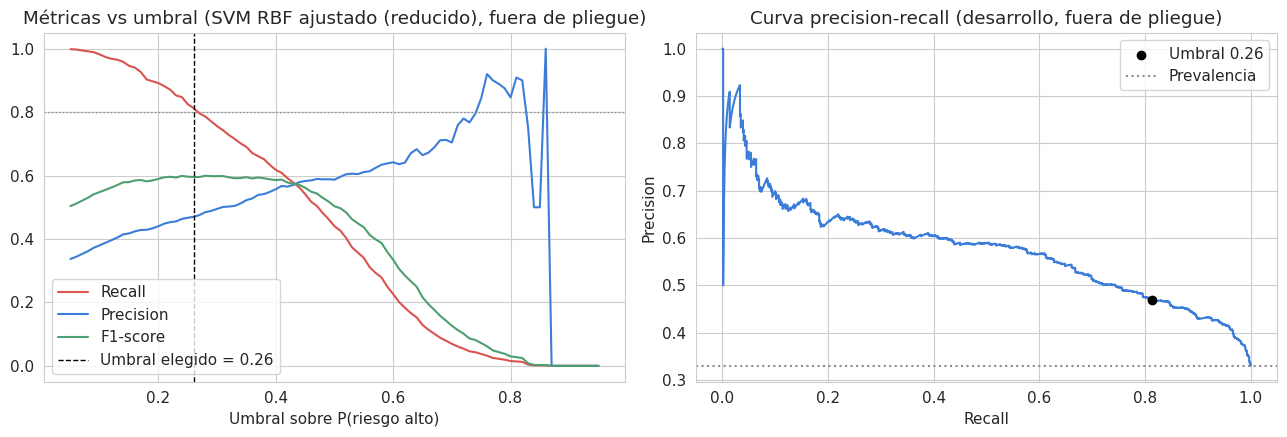

,Umbral,Precision,Recall,F1,FP,FN,% señalados,Costo,Criterio
15,0.20,0.440,0.892,0.590,816,78,66.758,1050,
16,0.21,0.448,0.882,0.595,781,85,64.835,1036,Costo mínimo
20,0.25,0.467,0.825,0.596,678,126,58.242,1056,
21,0.26,0.470,0.812,0.595,660,135,57.005,1065,ELEGIDO: recall >= 0.80
25,0.30,0.495,0.756,0.598,555,176,50.321,1083,
30,0.35,0.523,0.690,0.595,454,223,43.544,1123,
32,0.37,0.539,0.661,0.594,407,244,40.430,1139,Youden
35,0.40,0.557,0.618,0.586,354,275,36.584,1179,
40,0.45,0.583,0.542,0.562,279,330,30.632,1269,
45,0.50,0.587,0.440,0.503,223,403,24.725,1432,Por defecto


In [59]:
nombre_u = NOMBRE_PRELIM
curva = CURVAS_UMBRAL[nombre_u]
u_sel = UMBRALES[nombre_u]['recall_minimo']
filas_u = sorted(set([0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, u_sel, UMBRALES[nombre_u]['youden'], UMBRALES[nombre_u]['costo']]))
tabla_umbral_final = curva[curva['Umbral'].isin(filas_u)][['Umbral', 'Precision', 'Recall', 'F1', 'FP', 'FN', '% señalados', 'Costo']].copy()
tabla_umbral_final['Criterio'] = tabla_umbral_final['Umbral'].map(
    lambda u: ' / '.join([n for n, v in [('ELEGIDO: recall >= 0.80', u_sel), ('Youden', UMBRALES[nombre_u]['youden']),
                                         ('Costo mínimo', UMBRALES[nombre_u]['costo']), ('Por defecto', 0.50)] if abs(u - v) < 1e-9]))
tabla_umbral_final.to_csv(DIR_RES / 'tabla_umbral.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(curva['Umbral'], curva['Recall'], color=COLOR_ALTO, label='Recall')
axes[0].plot(curva['Umbral'], curva['Precision'], color=COLOR_RESTO, label='Precision')
axes[0].plot(curva['Umbral'], curva['F1'], color='#4C9F70', label='F1-score')
axes[0].axvline(u_sel, color='black', ls='--', lw=1, label=f'Umbral elegido = {u_sel:.2f}')
axes[0].axhline(RECALL_MINIMO, color=COLOR_GRIS, ls=':', lw=1)
axes[0].set_xlabel('Umbral sobre P(riesgo alto)'); axes[0].set_title(f'Métricas vs umbral ({nombre_u}, fuera de pliegue)')
axes[0].legend()
prec_c, rec_c, _ = precision_recall_curve(y_dev_alto, OOF[nombre_u])
axes[1].plot(rec_c, prec_c, color=COLOR_RESTO)
fila_sel = curva[curva['Umbral'] == u_sel].iloc[0]
axes[1].scatter([fila_sel['Recall']], [fila_sel['Precision']], color='black', zorder=3, label=f'Umbral {u_sel:.2f}')
axes[1].axhline(y_dev_alto.mean(), color=COLOR_GRIS, ls=':', label='Prevalencia')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Curva precision-recall (desarrollo, fuera de pliegue)')
axes[1].legend()
plt.tight_layout(); guardar_fig('fig_umbral'); plt.show()
tabla_umbral_final.round(3)

## 16. Evaluación de los finalistas en el conjunto de prueba

Solo ahora se usa el conjunto de prueba (365 pacientes de hogares nunca vistos). Cada finalista se entrena con todo
el conjunto de desarrollo y se evalúa (a) como clasificador binario de riesgo alto con su umbral operativo elegido en
la sección 15 y (b) como clasificador de 3 clases con la regla por defecto (clase más probable).

In [60]:
y_prueba_alto = (y_prueba.values == 2).astype(int)
AJUSTADOS, PROBA_PRUEBA, filas_prueba = {}, {}, []
for nombre, pipe in FINALISTAS.items():
    m = clone(pipe).fit(X_dev, y_dev)
    AJUSTADOS[nombre] = m
    proba = m.predict_proba(X_prueba)
    PROBA_PRUEBA[nombre] = proba
    u = UMBRALES[nombre]['recall_minimo']
    pred_bin = (proba[:, 2] >= u).astype(int)
    pred_mc = proba.argmax(1)
    filas_prueba.append({'Modelo finalista': nombre, 'Umbral': u,
                         'Accuracy': accuracy_score(y_prueba_alto, pred_bin),
                         'Precision': precision_score(y_prueba_alto, pred_bin),
                         'Recall': recall_score(y_prueba_alto, pred_bin),
                         'F1-score': f1_score(y_prueba_alto, pred_bin),
                         'ROC-AUC': roc_auc_score(y_prueba_alto, proba[:, 2]),
                         'PR-AUC': average_precision_score(y_prueba_alto, proba[:, 2]),
                         'ROC-AUC VC (media +/- desv.)': f"{F[nombre]['ROC-AUC alto (media)']:.3f} +/- {F[nombre]['ROC-AUC alto (desv.)']:.3f}",
                         'Accuracy 3 clases': accuracy_score(y_prueba, pred_mc),
                         'F1 macro 3 clases': f1_score(y_prueba, pred_mc, average='macro', zero_division=0),
                         'ROC-AUC macro OvR 3 clases': roc_auc_score(y_prueba, proba, multi_class='ovr', average='macro')})
tabla_prueba = pd.DataFrame(filas_prueba)
tabla_prueba.to_csv(DIR_RES / 'evaluacion_prueba_finalistas.csv', index=False)
tabla_prueba.round(3)

,Modelo finalista,Umbral,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,ROC-AUC VC (media +/- desv.),Accuracy 3 clases,F1 macro 3 clases,ROC-AUC macro OvR 3 clases
0,SVM RBF ajustado (reducido),0.26,0.649,0.481,0.825,0.607,0.765,0.588,0.764 +/- 0.027,0.696,0.429,0.612
1,Random Forest ajustado (reducido),0.34,0.660,0.490,0.808,0.610,0.759,0.589,0.758 +/- 0.026,0.701,0.440,0.783


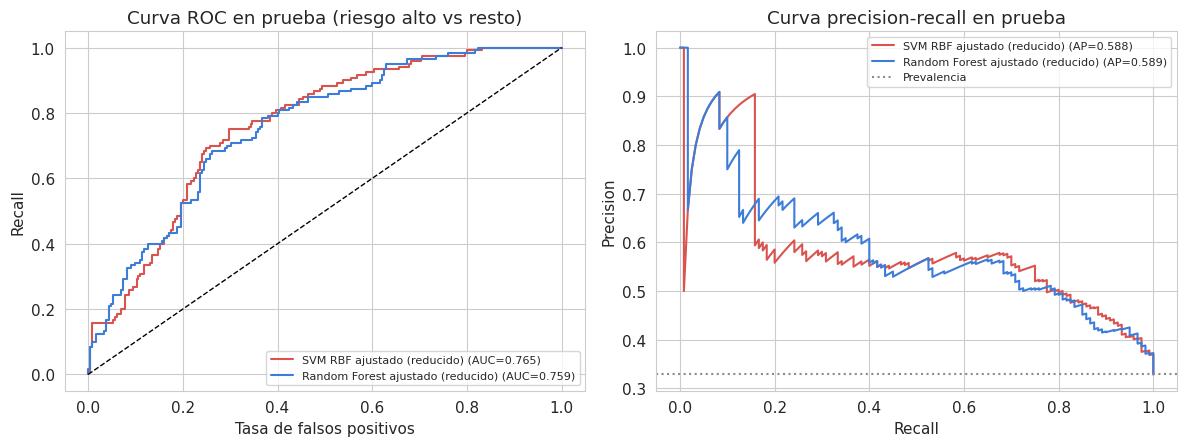

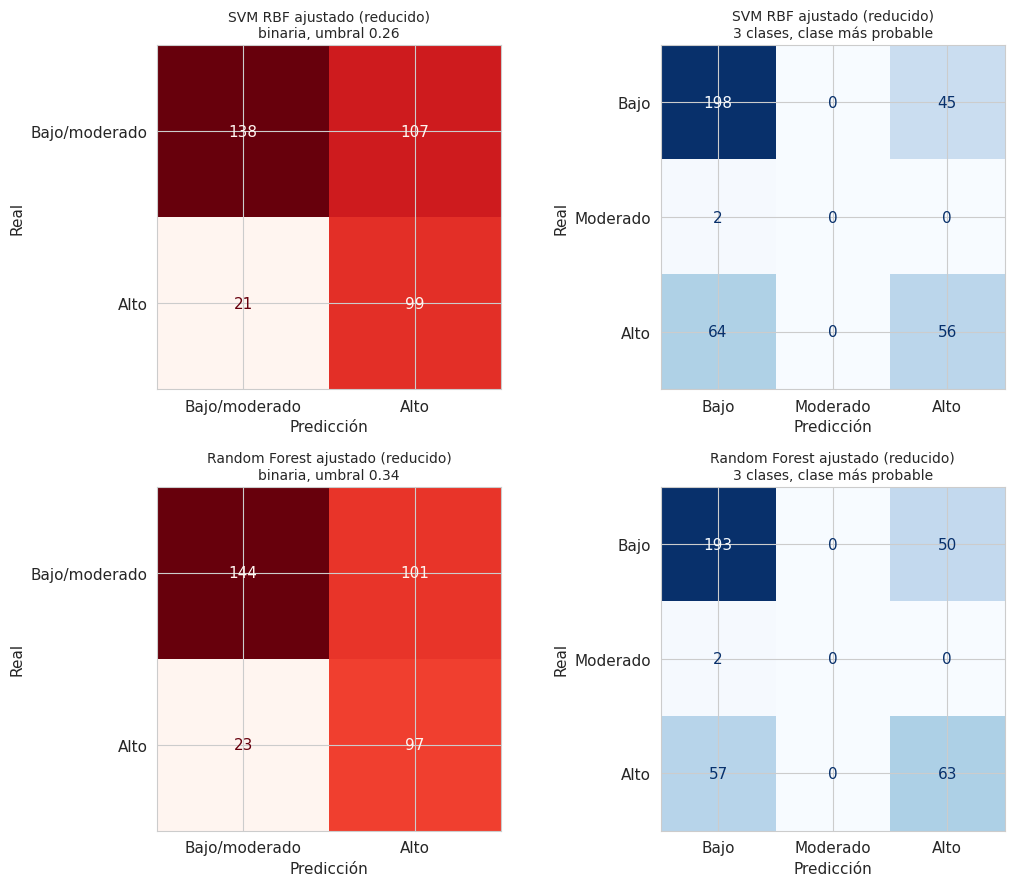

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
colores_fin = {fin_a: COLOR_ALTO, fin_b: COLOR_RESTO}
for nombre, proba in PROBA_PRUEBA.items():
    fpr, tpr, _ = roc_curve(y_prueba_alto, proba[:, 2])
    axes[0].plot(fpr, tpr, color=colores_fin[nombre], label=f'{nombre} (AUC={roc_auc_score(y_prueba_alto, proba[:, 2]):.3f})')
    p_, r_, _ = precision_recall_curve(y_prueba_alto, proba[:, 2])
    axes[1].plot(r_, p_, color=colores_fin[nombre], label=f'{nombre} (AP={average_precision_score(y_prueba_alto, proba[:, 2]):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1); axes[0].set_xlabel('Tasa de falsos positivos'); axes[0].set_ylabel('Recall')
axes[0].set_title('Curva ROC en prueba (riesgo alto vs resto)'); axes[0].legend(fontsize=8, loc='lower right')
axes[1].axhline(y_prueba_alto.mean(), color=COLOR_GRIS, ls=':', label='Prevalencia')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Curva precision-recall en prueba')
axes[1].legend(fontsize=8)
plt.tight_layout(); guardar_fig('fig_roc_pr_prueba'); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for fila_ax, (nombre, proba) in zip(axes, PROBA_PRUEBA.items()):
    u = UMBRALES[nombre]['recall_minimo']
    ConfusionMatrixDisplay(confusion_matrix(y_prueba_alto, (proba[:, 2] >= u).astype(int)),
                           display_labels=['Bajo/moderado', 'Alto']).plot(ax=fila_ax[0], colorbar=False, cmap='Reds')
    fila_ax[0].set_title(f'{nombre}\nbinaria, umbral {u:.2f}', fontsize=10)
    ConfusionMatrixDisplay(confusion_matrix(y_prueba, proba.argmax(1), labels=ORDEN),
                           display_labels=NOMBRES_CLASES).plot(ax=fila_ax[1], colorbar=False, cmap='Blues')
    fila_ax[1].set_title(f'{nombre}\n3 clases, clase más probable', fontsize=10)
for ax in axes.flat:
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout(); guardar_fig('fig_matrices_confusion_prueba'); plt.show()

## 17. Análisis de errores del modelo final

Se analizan los falsos positivos y falsos negativos del modelo preferido, con su umbral operativo, en el conjunto de prueba.

In [62]:
NOMBRE_FINAL = NOMBRE_PRELIM
PIPE_FINAL = AJUSTADOS[NOMBRE_FINAL]
UMBRAL_FINAL = UMBRALES[NOMBRE_FINAL]['recall_minimo']
p_alto = PROBA_PRUEBA[NOMBRE_FINAL][:, 2]
pred_final = (p_alto >= UMBRAL_FINAL).astype(int)
fe_prueba = ConstructorCaracteristicas().transform(X_prueba)
analisis = fe_prueba.assign(real=y_prueba.map(ETIQ).values, alto_real=y_prueba_alto, p_alto=p_alto, pred=pred_final,
                            folio_int=df_crudo.loc[X_prueba.index, 'folio_int'].values)
analisis['resultado'] = np.select([(analisis.alto_real == 1) & (analisis.pred == 1), (analisis.alto_real == 0) & (analisis.pred == 0),
                                   (analisis.alto_real == 0) & (analisis.pred == 1)], ['VP', 'VN', 'FP'], 'FN')
print(analisis['resultado'].value_counts().to_string())

vars_perfil = ['edad', 'imc_calc', 'trig', 'col_hdl', 'ratio_trig_hdl', 'insulina', 'colest', 'ac_urico', 'creat']
perfil_errores = analisis.groupby('resultado')[vars_perfil].median().reindex(['VP', 'FN', 'VN', 'FP']).round(2)
perfil_errores['n'] = analisis['resultado'].value_counts().reindex(perfil_errores.index)
perfil_errores['% sin IMC'] = analisis.groupby('resultado')['imc_calc'].apply(lambda s: s.isna().mean() * 100).reindex(perfil_errores.index).round(1)
perfil_errores['% mujeres'] = analisis.groupby('resultado')['sexo'].apply(lambda s: (s == 'Mujer').mean() * 100).reindex(perfil_errores.index).round(1)
print('\nMedianas por tipo de resultado (prueba):')
perfil_errores

resultado
VN    138
FP    107
VP     99
FN     21

Medianas por tipo de resultado (prueba):


,edad,imc_calc,trig,col_hdl,ratio_trig_hdl,insulina,colest,ac_urico,creat,n,% sin IMC,% mujeres
resultado,,,,,,,,,,,,
VP,61.0,31.68,162.0,37.0,4.04,13.0,149.0,4.9,0.70,99,55.6,59.6
FN,41.0,27.87,129.0,34.0,3.42,8.5,127.0,4.4,0.68,21,4.8,61.9
VN,33.0,27.87,94.0,36.0,2.54,6.2,122.0,4.3,0.62,138,8.0,71.7
FP,55.0,31.51,147.0,38.0,3.75,10.8,153.0,5.2,0.69,107,41.1,61.7


In [63]:
med_dev = ConstructorCaracteristicas().transform(X_dev)[vars_perfil].median()

def describir(fila, n=4):
    z = {v: (fila[v] - med_dev[v]) / (ConstructorCaracteristicas().transform(X_dev)[v].std()) for v in vars_perfil if pd.notna(fila[v])}
    top = sorted(z, key=lambda v: -abs(z[v]))[:n]
    txt = ', '.join(f"{v} {fila[v]:.1f} ({'alto' if z[v] > 0 else 'bajo'})" for v in top)
    return txt + (', sin IMC' if pd.isna(fila['imc_calc']) else '') + f", {fila['sexo']}"

fn_casos = analisis[analisis.resultado == 'FN'].sort_values('p_alto').head(3)
fp_casos = analisis[analisis.resultado == 'FP'].sort_values('p_alto', ascending=False).head(3)
cerca = analisis.iloc[(analisis['p_alto'] - UMBRAL_FINAL).abs().argsort()[:1]]
casos_err = pd.concat([fn_casos, fp_casos, cerca])
tabla_casos_err = pd.DataFrame({
    'Caso': casos_err['folio_int'].values, 'Clase real': casos_err['real'].values,
    'Predicción': np.where(casos_err['pred'] == 1, 'Prioridad alta', 'Sin prioridad alta'),
    'P(riesgo alto)': casos_err['p_alto'].round(3).values, 'Tipo de error': casos_err['resultado'].values,
    'Características relevantes (vs mediana)': [describir(f) for _, f in casos_err.iterrows()]})
tabla_casos_err.to_csv(DIR_RES / 'casos_error.csv', index=False)
tabla_casos_err

,Caso,Clase real,Predicción,P(riesgo alto),Tipo de error,Características relevantes (vs mediana)
0,2024_15059005_03,Alto,Sin prioridad alta,0.079,FN,"col_hdl 25.0 (bajo), edad 30.0 (bajo), colest 101.0 (bajo), creat 0.4 (bajo), Mujer"
1,2024_13046007_02,Alto,Sin prioridad alta,0.089,FN,"imc_calc 40.1 (alto), colest 94.0 (bajo), edad 32.0 (bajo), col_hdl 30.0 (bajo), Mujer"
2,2024_19041025_01,Alto,Sin prioridad alta,0.090,FN,"edad 34.0 (bajo), colest 106.0 (bajo), col_hdl 30.0 (bajo), ac_urico 3.9 (bajo), Mujer"
3,2024_06002047_01,Bajo,Prioridad alta,0.836,FP,"insulina 60.2 (alto), colest 106.0 (bajo), edad 57.0 (alto), ac_urico 5.4 (alto), Mujer"
4,2024_01001269_02,Bajo,Prioridad alta,0.708,FP,"col_hdl 64.0 (alto), insulina 38.2 (alto), ac_urico 7.2 (alto), colest 187.0 (alto), s..."
5,2024_08037122_01,Bajo,Prioridad alta,0.666,FP,"trig 346.0 (alto), imc_calc 39.2 (alto), colest 209.0 (alto), col_hdl 49.0 (alto), Mujer"
6,2024_22014146_04,Bajo,Prioridad alta,0.260,FP,"col_hdl 27.0 (bajo), edad 35.0 (bajo), insulina 20.3 (alto), ratio_trig_hdl 5.2 (alto)..."


In [64]:
# ¿Falla más el modelo en perfiles específicos? Tasa de falsos negativos por subgrupo (prueba)
alto_p = analisis[analisis.alto_real == 1]
fn_perfil = pd.DataFrame({
    'Subgrupo de pacientes de riesgo alto': ['Con IMC medido', 'Sin IMC (peso/estatura faltantes)', 'Triglicéridos < 150', 'Triglicéridos >= 150',
                                             'Edad < 40', 'Edad >= 40'],
    'n': [alto_p.imc_calc.notna().sum(), alto_p.imc_calc.isna().sum(), (alto_p.trig < 150).sum(), (alto_p.trig >= 150).sum(),
          (alto_p.edad < 40).sum(), (alto_p.edad >= 40).sum()],
    'Tasa de falsos negativos (%)': [(alto_p[m].resultado == 'FN').mean() * 100 for m in
                                     [alto_p.imc_calc.notna(), alto_p.imc_calc.isna(), alto_p.trig < 150, alto_p.trig >= 150,
                                      alto_p.edad < 40, alto_p.edad >= 40]]})
fn_perfil.round(1)

,Subgrupo de pacientes de riesgo alto,n,Tasa de falsos negativos (%)
0,Con IMC medido,64,31.2
1,Sin IMC (peso/estatura faltantes),56,1.8
2,Triglicéridos < 150,59,27.1
3,Triglicéridos >= 150,61,8.2
4,Edad < 40,19,52.6
5,Edad >= 40,100,11.0


## 18. Selección del modelo final

In [65]:
fa, fb = (F[NOMBRE_FINAL], F[fin_b if NOMBRE_FINAL == fin_a else fin_a])
otro = fin_b if NOMBRE_FINAL == fin_a else fin_a
tp_final = tabla_prueba.set_index('Modelo finalista')
seleccion_final = pd.DataFrame([
    ['Desempeño', f"VC: ROC-AUC {fa['ROC-AUC alto (media)']:.3f} vs {fb['ROC-AUC alto (media)']:.3f}; prueba: "
                  f"{tp_final.loc[NOMBRE_FINAL, 'ROC-AUC']:.3f} vs {tp_final.loc[otro, 'ROC-AUC']:.3f}",
     'Mejor o equivalente al otro finalista y muy superior al Dummy (0.49)'],
    ['Generalización', f"ROC-AUC prueba {tp_final.loc[NOMBRE_FINAL, 'ROC-AUC']:.3f} dentro de VC {fa['ROC-AUC alto (media)']:.3f} "
                       f"+/- {fa['ROC-AUC alto (desv.)']:.3f}; brecha entrenamiento-VC {fa['ROC-AUC alto (entren.)'] - fa['ROC-AUC alto (media)']:.3f}",
     'Sin señales de sobreajuste relevante'],
    ['Errores', f"Recall prueba {tp_final.loc[NOMBRE_FINAL, 'Recall']:.3f} con umbral {UMBRAL_FINAL:.2f}; "
                f"FN = {(analisis.resultado == 'FN').sum()}, FP = {(analisis.resultado == 'FP').sum()}",
     'Cumple la prioridad de no perder casos de riesgo alto; el costo son falsos positivos'],
    ['Interpretabilidad', 'Importancia por permutación y SHAP (secciones 19 y 20)', 'Explicable a nivel global y local con métodos agnósticos'],
    ['Complejidad', f"{n_red} variables transformadas; entrenamiento {fa['Tiempo entrenamiento (s)']:.1f} s",
     'Complejidad moderada, sin variables regionales'],
    ['Operación', f"Inferencia {fa['Tiempo inferencia (ms/1000 reg.)']:.0f} ms por 1,000 registros; 12 campos de entrada",
     'Apto para un script de inferencia por lotes'],
    ['Riesgo', 'Falsos negativos, sesgo por subgrupos y deriva de datos (secciones 21 y 22)', 'Aceptable para una prueba controlada con revisión humana'],
], columns=['Criterio', 'Evidencia', 'Conclusión'])
print('MODELO FINAL:', NOMBRE_FINAL, '| umbral operativo:', UMBRAL_FINAL)
seleccion_final

MODELO FINAL: SVM RBF ajustado (reducido) | umbral operativo: 0.26


,Criterio,Evidencia,Conclusión
0,Desempeño,VC: ROC-AUC 0.764 vs 0.758; prueba: 0.765 vs 0.759,Mejor o equivalente al otro finalista y muy superior al Dummy (0.49)
1,Generalización,ROC-AUC prueba 0.765 dentro de VC 0.764 +/- 0.027; brecha entrenamiento-VC 0.054,Sin señales de sobreajuste relevante
2,Errores,"Recall prueba 0.825 con umbral 0.26; FN = 21, FP = 107",Cumple la prioridad de no perder casos de riesgo alto; el costo son falsos positivos
3,Interpretabilidad,Importancia por permutación y SHAP (secciones 19 y 20),Explicable a nivel global y local con métodos agnósticos
4,Complejidad,15 variables transformadas; entrenamiento 0.5 s,"Complejidad moderada, sin variables regionales"
5,Operación,"Inferencia 80 ms por 1,000 registros; 12 campos de entrada",Apto para un script de inferencia por lotes
6,Riesgo,"Falsos negativos, sesgo por subgrupos y deriva de datos (secciones 21 y 22)",Aceptable para una prueba controlada con revisión humana


## 19. Interpretación global del modelo final

Se usan dos métodos complementarios:

* **Importancia por permutación** sobre el pipeline completo (variables de entrada originales): cuánto cae el
  ROC-AUC de riesgo alto en prueba al desordenar aleatoriamente cada variable (20 repeticiones).
* **SHAP** sobre las variables transformadas: contribución de cada variable a la probabilidad de riesgo alto de cada
  paciente (KernelSHAP para la SVM, TreeSHAP para árboles).

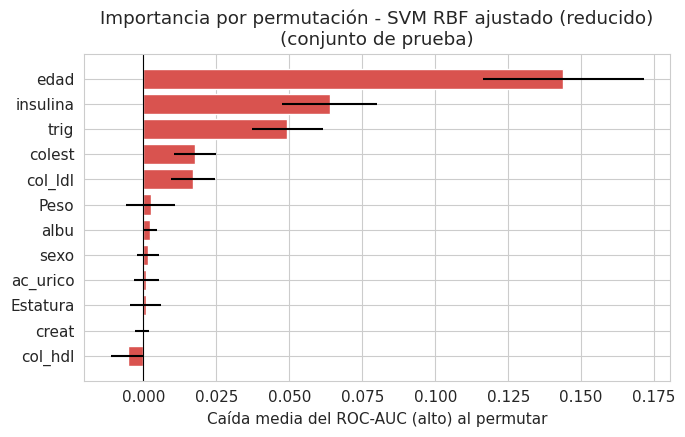

,Variable,Importancia (caída de ROC-AUC),Desv.,Ranking
1,edad,0.1439,0.0275,1
10,insulina,0.0638,0.0162,2
11,trig,0.0494,0.0122,3
8,colest,0.0176,0.0072,4
7,col_ldl,0.0170,0.0076,5
2,Peso,0.0025,0.0085,6
5,albu,0.0021,0.0024,7
0,sexo,0.0016,0.0038,8
4,ac_urico,0.0010,0.0044,9
3,Estatura,0.0008,0.0053,10


In [66]:
cols_modelo = COLUMNAS_ENTRADA_REDUCIDAS
perm = permutation_importance(PIPE_FINAL, X_prueba[cols_modelo], y_prueba, scoring=SCORER_AUC_ALTO,
                              n_repeats=20, random_state=RANDOM_STATE)
imp_perm = pd.DataFrame({'Variable': cols_modelo, 'Importancia (caída de ROC-AUC)': perm.importances_mean,
                         'Desv.': perm.importances_std}).sort_values('Importancia (caída de ROC-AUC)', ascending=False)
imp_perm['Ranking'] = range(1, len(imp_perm) + 1)
imp_perm.to_csv(DIR_RES / 'importancia_permutacion.csv', index=False)

plt.figure(figsize=(7, 4.5))
ip = imp_perm.sort_values('Importancia (caída de ROC-AUC)')
plt.barh(ip['Variable'], ip['Importancia (caída de ROC-AUC)'], xerr=ip['Desv.'], color=COLOR_ALTO)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Caída media del ROC-AUC (alto) al permutar'); plt.title(f'Importancia por permutación - {NOMBRE_FINAL}\n(conjunto de prueba)')
plt.tight_layout(); guardar_fig('fig_importancia_permutacion'); plt.show()
imp_perm.round(4)

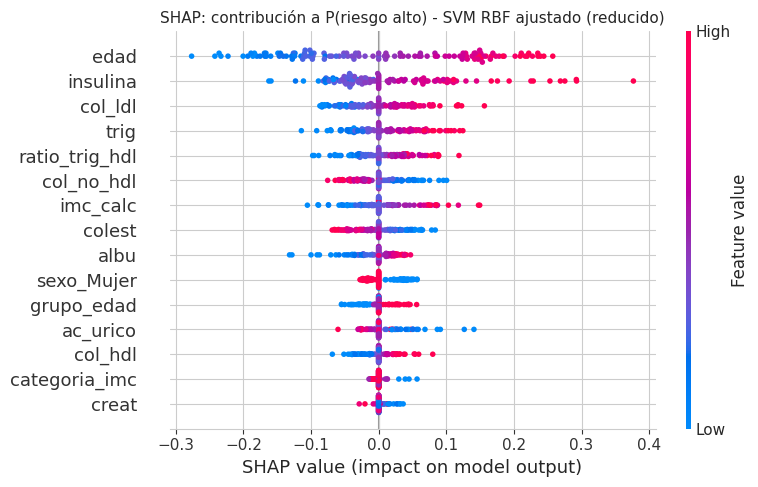

,Variable (transformada),|SHAP| medio,Ranking
0,edad,0.1226,1
1,insulina,0.0687,2
2,col_ldl,0.0397,3
3,trig,0.0373,4
4,ratio_trig_hdl,0.0315,5
5,col_no_hdl,0.0281,6
6,imc_calc,0.0276,7
7,colest,0.0260,8
8,albu,0.0217,9
9,sexo_Mujer,0.0195,10


In [67]:
pre_final = PIPE_FINAL[:-1]
clf_final = PIPE_FINAL.named_steps['modelo']
nombres_t = nombres_limpios(PIPE_FINAL)
Xt_dev = pd.DataFrame(pre_final.transform(X_dev), columns=nombres_t)
Xt_prueba = pd.DataFrame(pre_final.transform(X_prueba), columns=nombres_t, index=X_prueba.index)

if isinstance(clf_final, RandomForestClassifier):
    explicador = shap.TreeExplainer(clf_final)
    def shap_alto(Z):
        sv = explicador.shap_values(Z)
        return sv[:, :, 2] if np.ndim(sv) == 3 else sv[2]
    valor_base = explicador.expected_value[2]
else:
    fondo = shap.kmeans(Xt_dev.values, 25)
    f_alto = lambda Z: clf_final.predict_proba(Z)[:, 2]
    explicador = shap.KernelExplainer(f_alto, fondo)
    def shap_alto(Z):
        return explicador.shap_values(Z, nsamples=400, silent=True)
    valor_base = explicador.expected_value

rng = np.random.RandomState(RANDOM_STATE)
idx_muestra = rng.choice(len(Xt_prueba), size=120, replace=False)
sv_muestra = shap_alto(Xt_prueba.iloc[idx_muestra])
shap_global = pd.Series(np.abs(sv_muestra).mean(0), index=nombres_t).sort_values(ascending=False)

shap.summary_plot(sv_muestra, Xt_prueba.iloc[idx_muestra], feature_names=nombres_t, show=False, plot_size=(8, 5))
plt.title(f'SHAP: contribución a P(riesgo alto) - {NOMBRE_FINAL}', fontsize=11)
plt.tight_layout(); guardar_fig('fig_shap_global'); plt.show()
pd.DataFrame({'Variable (transformada)': shap_global.index, '|SHAP| medio': shap_global.values.round(4),
              'Ranking': range(1, len(shap_global) + 1)})

**Limitaciones de los métodos.** La importancia por permutación subestima variables correlacionadas entre sí (al
permutar una, la otra conserva parte de la información: por ejemplo `trig` y `ratio_trig_hdl`, o `colest` y `col_ldl`).
KernelSHAP es una aproximación por muestreo con un fondo resumido (25 centroides) y supone independencia entre
variables. **Ninguno de los dos demuestra causalidad**: indican qué variables usa el modelo para estimar el riesgo,
no qué cambiaría el riesgo real de un paciente si se modificara esa variable.

## 20. Explicación de predicciones individuales

Se explica un verdadero positivo, un verdadero negativo, un falso positivo y un falso negativo del conjunto de prueba
(el caso más representativo de cada tipo: el de probabilidad más cercana a la mediana de su grupo).

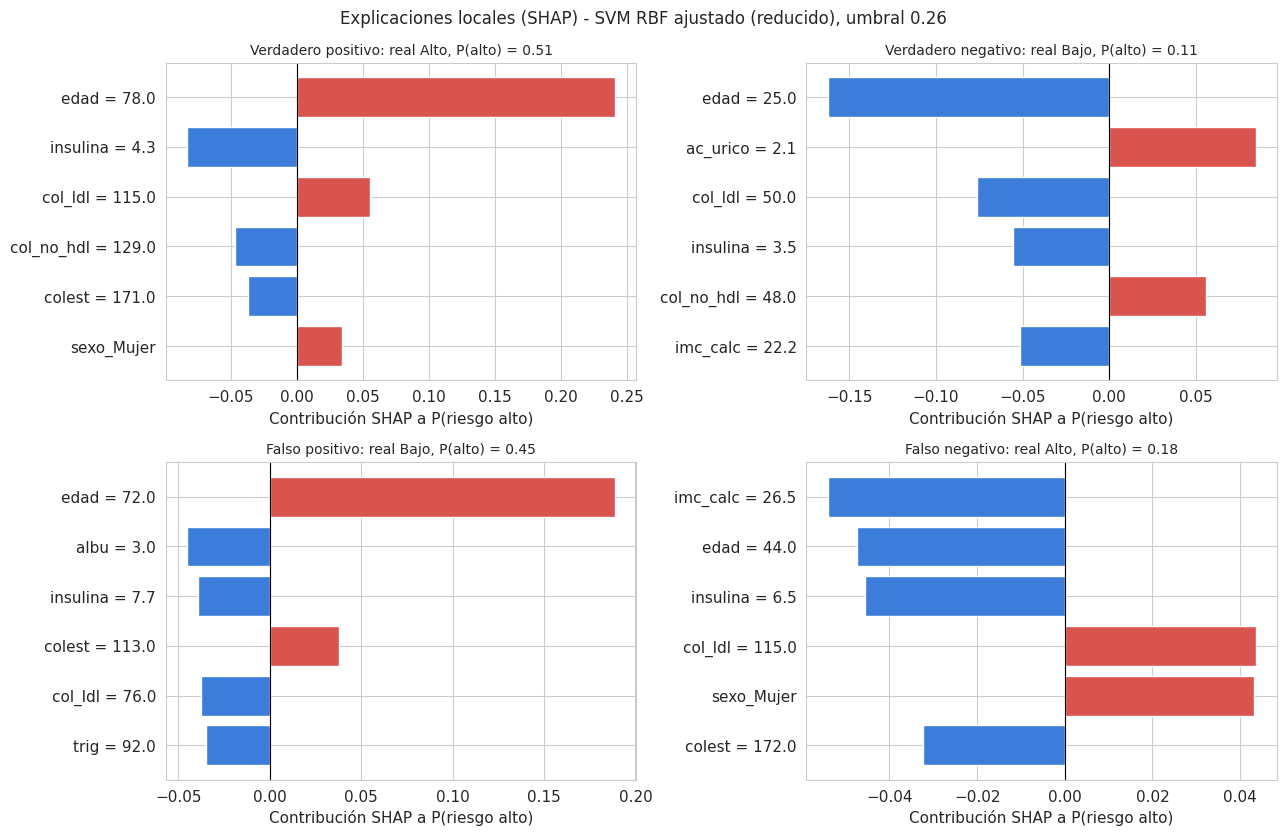

,Caso,Paciente,Resultado real,Predicción,Factores principales
0,Verdadero positivo,2024_06007113_01,Alto,Prioridad alta (P = 0.51),"Suben: edad (78.0), col_ldl (115.0), sexo_Mujer | Bajan: insulina (4.3), col_no_hdl (1..."
1,Verdadero negativo,2024_20021020_02,Bajo,Sin prioridad alta (P = 0.11),"Suben: ac_urico (2.1), col_no_hdl (48.0), colest (80.0) | Bajan: edad (25.0), col_ldl ..."
2,Falso positivo,2024_16075015_01,Bajo,Prioridad alta (P = 0.45),"Suben: edad (72.0), colest (113.0), grupo_edad | Bajan: albu (3.0), insulina (7.7), co..."
3,Falso negativo,2024_14067019_01,Alto,Sin prioridad alta (P = 0.18),"Suben: col_ldl (115.0), sexo_Mujer, albu (4.1) | Bajan: imc_calc (26.5), edad (44.0), ..."


In [68]:
casos_locales = {}
for tipo in ['VP', 'VN', 'FP', 'FN']:
    sub = analisis[analisis.resultado == tipo]
    casos_locales[tipo] = sub.iloc[(sub['p_alto'] - sub['p_alto'].median()).abs().argsort()[:1]].index[0]
idx_loc = list(casos_locales.values())
sv_loc = shap_alto(Xt_prueba.loc[idx_loc])
nombres_tipo = {'VP': 'Verdadero positivo', 'VN': 'Verdadero negativo', 'FP': 'Falso positivo', 'FN': 'Falso negativo'}

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
filas_loc = []
for ax, (tipo, idx), sv in zip(axes.flat, casos_locales.items(), sv_loc):
    s = pd.Series(sv, index=nombres_t)
    top = s.reindex(s.abs().sort_values(ascending=False).index[:6])[::-1]
    crudo = analisis.loc[idx]
    etiquetas = [f"{v} = {crudo[v]:.1f}" if v in crudo and pd.notna(crudo[v]) and not isinstance(crudo[v], str)
                 else (f"{v} = {crudo[v]}" if v in crudo else v) for v in top.index]
    ax.barh(etiquetas, top.values, color=[COLOR_ALTO if v > 0 else COLOR_RESTO for v in top.values])
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f"{nombres_tipo[tipo]}: real {crudo['real']}, P(alto) = {crudo['p_alto']:.2f}", fontsize=10)
    ax.set_xlabel('Contribución SHAP a P(riesgo alto)')
    sube = [f"{v} ({crudo[v]:.1f})" if pd.notna(crudo.get(v, np.nan)) and not isinstance(crudo.get(v), str) else v
            for v in s.sort_values(ascending=False).index[:3] if s[v] > 0]
    baja = [f"{v} ({crudo[v]:.1f})" if pd.notna(crudo.get(v, np.nan)) and not isinstance(crudo.get(v), str) else v
            for v in s.sort_values().index[:3] if s[v] < 0]
    filas_loc.append([nombres_tipo[tipo], crudo['folio_int'], crudo['real'],
                      f"{'Prioridad alta' if crudo['pred'] == 1 else 'Sin prioridad alta'} (P = {crudo['p_alto']:.2f})",
                      'Suben: ' + (', '.join(sube) or 'ninguno') + ' | Bajan: ' + (', '.join(baja) or 'ninguno')])
plt.suptitle(f'Explicaciones locales (SHAP) - {NOMBRE_FINAL}, umbral {UMBRAL_FINAL:.2f}', fontsize=12)
plt.tight_layout(); guardar_fig('fig_shap_local'); plt.show()
tabla_local = pd.DataFrame(filas_loc, columns=['Caso', 'Paciente', 'Resultado real', 'Predicción', 'Factores principales'])
tabla_local.to_csv(DIR_RES / 'explicaciones_locales.csv', index=False)
tabla_local

## 21. Evaluación de posibles sesgos

Se comparan grupos por **sexo** (Hombre / Mujer) y por **grupo de edad** (20-39, 40-59, 60+). Se usan dos fuentes:
el conjunto de prueba (evaluación final, pero con grupos pequeños) y las predicciones fuera de pliegue del conjunto
de desarrollo (más pacientes y por lo tanto más estables).

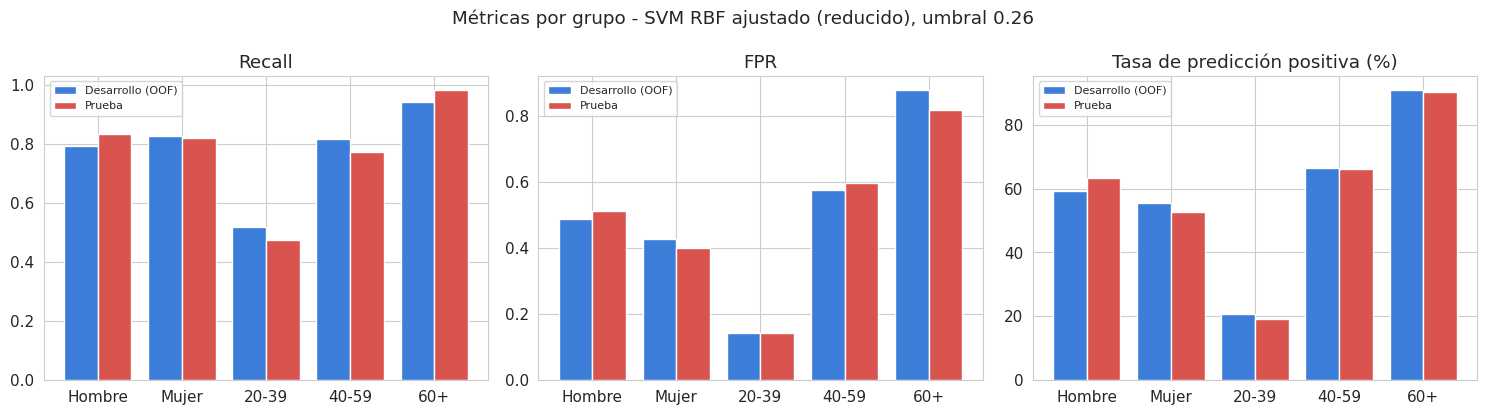

,Fuente,Grupo,Tamaño,Tasa real de riesgo alto (%),Tasa de predicción positiva (%),Recall,Precision,FPR,FNR
0,Prueba,Hombre,128,37.500,63.281,0.833,0.494,0.512,0.167
1,Prueba,Mujer,237,30.380,52.743,0.819,0.472,0.400,0.181
2,Desarrollo (fuera de pliegue),Hombre,874,34.439,59.382,0.794,0.461,0.489,0.206
3,Desarrollo (fuera de pliegue),Mujer,1310,31.985,55.420,0.826,0.477,0.426,0.174
4,Prueba,20-39,130,14.615,19.231,0.474,0.360,0.144,0.526
5,Prueba,40-59,121,36.364,66.116,0.773,0.425,0.597,0.227
6,Prueba,60+,111,50.450,90.090,0.982,0.550,0.818,0.018
7,Desarrollo (fuera de pliegue),20-39,757,17.041,20.608,0.519,0.429,0.142,0.481
8,Desarrollo (fuera de pliegue),40-59,784,36.735,66.327,0.816,0.452,0.575,0.184
9,Desarrollo (fuera de pliegue),60+,617,47.650,90.762,0.942,0.495,0.876,0.058


In [69]:
def metricas_grupo(y_bin, p, u, grupos_s, fuente):
    filas = []
    for gname in [g for g in ['Hombre', 'Mujer', '20-39', '40-59', '60+'] if g in set(grupos_s)]:
        m = (grupos_s == gname)
        yb, pr = y_bin[m], (p[m] >= u).astype(int)
        tp = ((pr == 1) & (yb == 1)).sum(); fp = ((pr == 1) & (yb == 0)).sum()
        fn = ((pr == 0) & (yb == 1)).sum(); tn = ((pr == 0) & (yb == 0)).sum()
        filas.append([fuente, gname, int(m.sum()), yb.mean() * 100, pr.mean() * 100,
                      tp / (tp + fn) if tp + fn else np.nan, tp / (tp + fp) if tp + fp else np.nan,
                      fp / (fp + tn) if fp + tn else np.nan, fn / (fn + tp) if fn + tp else np.nan])
    return filas

oof_final = OOF[NOMBRE_FINAL]
fe_dev_s = ConstructorCaracteristicas().transform(X_dev)
filas_sesgo = []
for var in ['sexo', 'grupo_edad']:
    filas_sesgo += metricas_grupo(y_prueba_alto, p_alto, UMBRAL_FINAL, fe_prueba[var].fillna('ND').values, 'Prueba')
    filas_sesgo += metricas_grupo(y_dev_alto, oof_final, UMBRAL_FINAL, fe_dev_s[var].fillna('ND').values, 'Desarrollo (fuera de pliegue)')
tabla_sesgo = pd.DataFrame(filas_sesgo, columns=['Fuente', 'Grupo', 'Tamaño', 'Tasa real de riesgo alto (%)',
                                                 'Tasa de predicción positiva (%)', 'Recall', 'Precision', 'FPR', 'FNR'])
tabla_sesgo.to_csv(DIR_RES / 'analisis_sesgos.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
td = tabla_sesgo[tabla_sesgo.Fuente == 'Desarrollo (fuera de pliegue)']
tp_ = tabla_sesgo[tabla_sesgo.Fuente == 'Prueba']
for ax, met in zip(axes, ['Recall', 'FPR', 'Tasa de predicción positiva (%)']):
    x = np.arange(len(td))
    ax.bar(x - 0.2, td[met], width=0.4, color=COLOR_RESTO, label='Desarrollo (OOF)')
    ax.bar(x + 0.2, tp_.set_index('Grupo').reindex(td['Grupo'])[met], width=0.4, color=COLOR_ALTO, label='Prueba')
    ax.set_xticks(x, td['Grupo']); ax.set_title(met); ax.legend(fontsize=8)
plt.suptitle(f'Métricas por grupo - {NOMBRE_FINAL}, umbral {UMBRAL_FINAL:.2f}')
plt.tight_layout(); guardar_fig('fig_sesgos'); plt.show()
tabla_sesgo.round(3)

## 22. Registro de riesgos y condiciones de uso

| Riesgo | Causa | Consecuencia | Probabilidad | Impacto | Mitigación |
|---|---|---|---|---|---|
| Falsos negativos | Pacientes de riesgo alto con perfil lipídico y edad "normales"; sin IMC medido | Persona en riesgo sin prueba confirmatoria ni seguimiento | Media (aprox. 1 de cada 5 casos altos) | Alto | Umbral con recall >= 0.80; el modelo no sustituye la tamización habitual; quien no sea señalado sigue en el flujo normal |
| Falsos positivos | Umbral bajo para favorecer el recall; síndrome metabólico sin alteración de glucosa | Pruebas confirmatorias adicionales y preocupación del paciente | Alta | Bajo a medio | Comunicar como "prioridad de revisión", no diagnóstico; confirmar con glucosa/HbA1c |
| Drift (deriva de datos) | Cambios en la población, en laboratorios o en métodos de medición | Probabilidades descalibradas y caída de recall | Media | Alto | Monitoreo mensual de PSI y recall (sección 28) |
| Datos incompletos | Peso/estatura faltantes (28% en el dataset), campos sin capturar | Imputación por mediana, estimación menos confiable | Alta | Medio | Validación de entradas con advertencias; mostrar el aviso al usuario; campos obligatorios |
| Uso automático | Tomar la clasificación como decisión final | Negar o retrasar atención por un error del modelo | Media | Alto | Revisión humana obligatoria; mensaje en cada resultado; prohibido para negar servicios |
| Sesgo | Diferencias de prevalencia y de calidad de datos por sexo y edad | Desempeño desigual entre grupos (p. ej. menor recall en jóvenes) | Media | Medio a alto | Reporte trimestral de métricas por grupo; revisión si la diferencia de recall supera 0.10 |

**Usos permitidos.** Priorizar, dentro de una población que ya cuenta con perfil de lípidos, qué pacientes deben recibir
primero una prueba confirmatoria (glucosa en ayuno / HbA1c) y acciones preventivas; apoyo a la planeación de campañas.

**Usos no recomendados.** Diagnosticar diabetes; negar, retrasar o condicionar atención, seguros o empleo; aplicarlo a
menores de 20 años, embarazadas o poblaciones distintas de la encuesta; usarlo sin las 12 variables de entrada o con
unidades distintas; estimar el riesgo *moderado* (la clase tiene 12 casos y el modelo no la detecta).

**Revisión humana.** Todo resultado lo revisa personal de salud (médico de primer contacto o enfermería) antes de
cualquier acción; los resultados cercanos al umbral (+/- 0.05) y los registros con advertencias se revisan con mayor cuidado.

**Responsables de supervisión.** Responsable técnico del modelo (mantenimiento, monitoreo, versiones) y un responsable
clínico (coordinación de epidemiología) que valida el uso y las decisiones.

**Condiciones para suspender el modelo.** Recall de riesgo alto menor a 0.70 en dos cortes mensuales consecutivos;
PSI mayor a 0.25 en alguna variable principal; diferencia de recall entre grupos mayor a 0.15; cambio en la definición
de la variable objetivo o en los métodos de laboratorio; falla de integridad del artefacto (huella SHA-256 distinta).

## 23. Serialización del pipeline y del modelo

Se guarda el **pipeline completo** (limpieza + ingeniería + preprocesamiento + modelo) con joblib, más el
clasificador por separado, la codificación del objetivo, el umbral y un archivo de metadatos con el esquema de
entrada, rangos válidos, métricas, versiones de librerías y la huella SHA-256 de cada artefacto.

In [70]:
RANGOS_VALIDOS = {'edad': (18, 110), 'Peso': (25, 250), 'Estatura': (100, 220), 'ac_urico': (0.5, 20),
                  'albu': (1.0, 7.0), 'col_hdl': (5, 150), 'col_ldl': (5, 500), 'colest': (20, 800),
                  'creat': (0.1, 20), 'insulina': (0.1, 500), 'trig': (10, 5000)}
OBLIGATORIOS = ['sexo', 'edad', 'col_hdl', 'colest', 'trig', 'insulina']
fe_dev_limpio = ConstructorCaracteristicas().transform(X_dev)
esquema = {'sexo': {'tipo': 'categorica', 'valores': ['Hombre', 'Mujer', '1', '2'], 'obligatorio': True}}
for c in COLUMNAS_ENTRADA_REDUCIDAS:
    if c == 'sexo':
        continue
    regla = {'tipo': 'numerica', 'obligatorio': c in OBLIGATORIOS,
             'min_valido': RANGOS_VALIDOS[c][0], 'max_valido': RANGOS_VALIDOS[c][1],
             'p_inf_entrenamiento': float(fe_dev_limpio[c].quantile(0.005)),
             'p_sup_entrenamiento': float(fe_dev_limpio[c].quantile(0.995))}
    if c in ('Peso', 'Estatura'):
        regla['centinela'] = [222.22, 222.2]
    esquema[c] = regla

def sha256(ruta_a):
    return hashlib.sha256(Path(ruta_a).read_bytes()).hexdigest()

arch = {'pipeline': 'pipeline_riesgo_diabetes_v1.joblib', 'modelo': 'modelo_clasificador_v1.joblib',
        'objetivo': 'codificacion_objetivo_v1.json', 'umbral': 'umbral_v1.json', 'meta': 'metadatos_modelo_v1.json'}
joblib.dump(PIPE_FINAL, DIR_ART / arch['pipeline'])
joblib.dump(PIPE_FINAL.named_steps['modelo'], DIR_ART / arch['modelo'])
(DIR_ART / arch['objetivo']).write_text(json.dumps({'0': 'Riesgo bajo', '1': 'Riesgo moderado', '2': 'Riesgo alto'},
                                                   ensure_ascii=False, indent=2), encoding='utf-8')
(DIR_ART / arch['umbral']).write_text(json.dumps({'umbral_riesgo_alto': UMBRAL_FINAL,
                                                  'criterio': f'Umbral más alto con recall >= {RECALL_MINIMO} (fuera de pliegue, desarrollo)',
                                                  'clase_positiva': 2}, ensure_ascii=False, indent=2), encoding='utf-8')
metricas_prueba_final = tp_final.loc[NOMBRE_FINAL, ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']].astype(float).round(4).to_dict()
meta = {
    'nombre': 'Modelo de priorización de riesgo de diabetes', 'version': VERSION_MODELO, 'modelo': NOMBRE_FINAL,
    'fecha_entrenamiento': FECHA, 'responsable': RESPONSABLE,
    'archivo_pipeline': arch['pipeline'], 'sha256_pipeline': sha256(DIR_ART / arch['pipeline']),
    'sha256_modelo': sha256(DIR_ART / arch['modelo']),
    'umbral_riesgo_alto': UMBRAL_FINAL, 'codificacion_objetivo': {'0': 'Riesgo bajo', '1': 'Riesgo moderado', '2': 'Riesgo alto'},
    'hiperparametros': {k: (v if isinstance(v, (int, float, str)) or v is None else str(v))
                        for k, v in PIPE_FINAL.named_steps['modelo'].get_params().items()},
    'esquema_entrada': esquema, 'dataset': {'archivo': 'Diabetes_Mexico.csv', 'md5': huella_csv, 'n_desarrollo': len(X_dev),
                                            'n_prueba': len(X_prueba)},
    'metricas_vc': {k: round(float(F[NOMBRE_FINAL][k]), 4) for k in ['ROC-AUC alto (media)', 'ROC-AUC alto (desv.)', 'Recall alto', 'F1 alto']},
    'metricas_prueba': metricas_prueba_final,
    'librerias': {'python': platform.python_version(), 'scikit-learn': sklearn.__version__, 'pandas': pd.__version__,
                  'numpy': np.__version__, 'joblib': joblib.__version__},
    'modulo_requerido': 'diabetes_transformers.py',
}
(DIR_ART / arch['meta']).write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')

artefactos = pd.DataFrame([
    ['Pipeline final (preprocesamiento + modelo)', arch['pipeline'], VERSION_MODELO, FECHA, f'joblib {joblib.__version__} / scikit-learn {sklearn.__version__}'],
    ['Modelo (clasificador)', arch['modelo'], VERSION_MODELO, FECHA, f'joblib {joblib.__version__} / scikit-learn {sklearn.__version__}'],
    ['Codificación del objetivo', arch['objetivo'], VERSION_MODELO, FECHA, 'json (biblioteca estándar)'],
    ['Umbral', arch['umbral'], VERSION_MODELO, FECHA, 'json (biblioteca estándar)'],
    ['Metadatos, esquema de entrada y huellas', arch['meta'], VERSION_MODELO, FECHA, 'json (biblioteca estándar)'],
    ['Módulo de transformadores (requerido al cargar)', 'scripts/diabetes_transformers.py', VERSION_MODELO, FECHA, 'Python'],
], columns=['Artefacto', 'Archivo', 'Versión', 'Fecha', 'Biblioteca'])
artefactos['Tamaño (KB)'] = [round((DIR_ART / a).stat().st_size / 1024, 1) if (DIR_ART / a).exists() else
                             round((DIR_SCRIPTS / 'diabetes_transformers.py').stat().st_size / 1024, 1) for a in artefactos['Archivo']]
artefactos['SHA-256 (inicio)'] = [sha256(DIR_ART / a)[:16] if (DIR_ART / a).exists() else sha256(DIR_SCRIPTS / 'diabetes_transformers.py')[:16]
                                  for a in artefactos['Archivo']]
artefactos.to_csv(DIR_RES / 'tabla_artefactos.csv', index=False)
artefactos

,Artefacto,Archivo,Versión,Fecha,Biblioteca,Tamaño (KB),SHA-256 (inicio)
0,Pipeline final (preprocesamiento + modelo),pipeline_riesgo_diabetes_v1.joblib,1.0.0,2026-09-30,joblib 1.5.3 / scikit-learn 1.8.0,258.9,0dbda4aafa099037
1,Modelo (clasificador),modelo_clasificador_v1.joblib,1.0.0,2026-09-30,joblib 1.5.3 / scikit-learn 1.8.0,252.1,a14aeb35ab0d0469
2,Codificación del objetivo,codificacion_objetivo_v1.json,1.0.0,2026-09-30,json (biblioteca estándar),0.1,66226703404be1e5
3,Umbral,umbral_v1.json,1.0.0,2026-09-30,json (biblioteca estándar),0.1,c036e1069414d6dc
4,"Metadatos, esquema de entrada y huellas",metadatos_modelo_v1.json,1.0.0,2026-09-30,json (biblioteca estándar),4.1,e65905a447fbb33d
5,Módulo de transformadores (requerido al cargar),scripts/diabetes_transformers.py,1.0.0,2026-09-30,Python,4.8,2d086ae12b13403b


> **Advertencia de seguridad.** Los archivos `.joblib` / `.pkl` pueden ejecutar código arbitrario al cargarse.
> Nunca se debe cargar un artefacto recibido de una fuente desconocida o no verificada. El script de inferencia
> compara la huella SHA-256 del pipeline con la registrada en `metadatos_modelo_v1.json` y se niega a cargarlo si no
> coincide. Además, el artefacto debe cargarse con las mismas versiones de scikit-learn y joblib registradas.

## 24. Script independiente de inferencia y verificación de la carga

El script `scripts/inferencia_riesgo_diabetes.py` es independiente del notebook: carga el artefacto (verificando su
huella), recibe uno o varios registros (JSON, CSV o lista de diccionarios), valida la estructura, aplica el
preprocesamiento dentro del pipeline, calcula la probabilidad, aplica el umbral y devuelve la clasificación. La celda
lo escribe en disco y lo ejecuta en un **proceso de Python nuevo** (sin las variables del notebook) sobre los 365
pacientes de prueba, para comparar las predicciones con las obtenidas antes de serializar.

In [71]:
CODIGO_INFERENCIA = r'''"""Mecanismo minimo de inferencia - Riesgo de diabetes (entrega final).

Uso desde terminal:
    python inferencia_riesgo_diabetes.py --entrada registros.json
    python inferencia_riesgo_diabetes.py --entrada registros.csv --salida resultados.csv

Uso desde Python / notebook:
    from inferencia_riesgo_diabetes import cargar_modelo, predecir
    modelo = cargar_modelo('../artifacts')
    resultados = predecir(modelo, [ {...registro...} ])

ADVERTENCIA DE SEGURIDAD: joblib/pickle puede ejecutar codigo arbitrario al cargar un
archivo. Solo cargue artefactos generados por el propio equipo y cuya huella SHA-256
coincida con la registrada en metadatos_modelo_v1.json (este script la verifica).
"""
import argparse
import hashlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

AQUI = Path(__file__).resolve().parent
if str(AQUI) not in sys.path:
    sys.path.insert(0, str(AQUI))  # diabetes_transformers.py debe estar junto a este script

MENSAJE_REVISION = ('Resultado estimado por un modelo estadistico. NO es un diagnostico: '
                    'requiere revision de personal de salud antes de cualquier decision.')


def _sha256(ruta):
    h = hashlib.sha256()
    with open(ruta, 'rb') as f:
        for bloque in iter(lambda: f.read(1 << 20), b''):
            h.update(bloque)
    return h.hexdigest()


def cargar_modelo(dir_artefactos=None):
    """Carga metadatos, verifica la huella del pipeline y lo deserializa."""
    import joblib
    dir_artefactos = Path(dir_artefactos) if dir_artefactos else AQUI.parent / 'artifacts'
    meta = json.loads((dir_artefactos / 'metadatos_modelo_v1.json').read_text(encoding='utf-8'))
    ruta_pipe = dir_artefactos / meta['archivo_pipeline']
    huella = _sha256(ruta_pipe)
    if huella != meta['sha256_pipeline']:
        raise RuntimeError('La huella SHA-256 del pipeline no coincide con los metadatos: '
                           'el archivo pudo ser modificado. No se carga por seguridad.')
    pipeline = joblib.load(ruta_pipe)
    return {'pipeline': pipeline, 'meta': meta}


def validar_registros(registros, meta):
    """Valida estructura, tipos, rangos y categorias.

    Devuelve (DataFrame limpio con las columnas esperadas, lista de diagnosticos por registro).
    Nunca lanza excepciones por datos malos: los reporta.
    """
    esquema = meta['esquema_entrada']
    esperadas = list(esquema.keys())
    if isinstance(registros, dict):
        registros = [registros]
    df = pd.DataFrame(registros) if not isinstance(registros, pd.DataFrame) else registros.copy()
    df = df.reset_index(drop=True)

    diagnosticos = [{'errores': [], 'advertencias': []} for _ in range(len(df))]

    adicionales = [c for c in df.columns if c not in esperadas and c != 'id']
    for d in diagnosticos:
        if adicionales:
            d['advertencias'].append(f'Columnas adicionales ignoradas: {adicionales}')

    faltantes_estructura = [c for c in esperadas if c not in df.columns]
    for c in faltantes_estructura:
        df[c] = np.nan

    limpio = pd.DataFrame(index=df.index, columns=esperadas, dtype=object)
    for c, regla in esquema.items():
        for i, v in df[c].items():
            vacio = v is None or (isinstance(v, float) and np.isnan(v)) or (isinstance(v, str) and v.strip() == '')
            if vacio:
                if c in faltantes_estructura:
                    msg = f'Estructura incompleta: falta la columna "{c}"'
                else:
                    msg = f'Campo faltante: "{c}"'
                if regla['obligatorio']:
                    diagnosticos[i]['errores'].append(msg + ' (obligatorio)')
                else:
                    diagnosticos[i]['advertencias'].append(msg + ' (se imputara con la mediana de entrenamiento)')
                limpio.at[i, c] = np.nan
                continue
            if regla['tipo'] == 'categorica':
                valor = str(v).strip()
                if valor not in regla['valores']:
                    diagnosticos[i]['errores'].append(
                        f'Categoria no reconocida en "{c}": {valor!r} (validas: {regla["valores"]})')
                    limpio.at[i, c] = np.nan
                else:
                    limpio.at[i, c] = valor
            else:  # numerica
                if isinstance(v, bool):
                    num = np.nan
                else:
                    try:
                        num = float(str(v).replace(',', '.'))
                    except ValueError:
                        num = np.nan
                if np.isnan(num):
                    diagnosticos[i]['errores'].append(f'Tipo incorrecto en "{c}": {v!r} no es numerico')
                    limpio.at[i, c] = np.nan
                    continue
                if 'centinela' in regla and num in regla['centinela']:
                    diagnosticos[i]['advertencias'].append(
                        f'"{c}" = {num} es un codigo de dato faltante; se tratara como faltante')
                    limpio.at[i, c] = np.nan
                    continue
                if num < regla['min_valido'] or num > regla['max_valido']:
                    diagnosticos[i]['errores'].append(
                        f'Valor fuera de rango en "{c}": {num} (rango valido {regla["min_valido"]} a {regla["max_valido"]})')
                    limpio.at[i, c] = np.nan
                    continue
                if num < regla['p_inf_entrenamiento'] or num > regla['p_sup_entrenamiento']:
                    diagnosticos[i]['advertencias'].append(
                        f'Valor extremo en "{c}": {num} (fuera del rango habitual de entrenamiento '
                        f'{regla["p_inf_entrenamiento"]:.2f} a {regla["p_sup_entrenamiento"]:.2f}); '
                        'el pipeline lo recorta y la estimacion es menos confiable')
                limpio.at[i, c] = num
    return limpio, diagnosticos


def predecir(modelo, registros):
    """Valida, preprocesa (dentro del pipeline), estima probabilidades y aplica el umbral."""
    meta, pipe = modelo['meta'], modelo['pipeline']
    ids = None
    if isinstance(registros, pd.DataFrame) and 'id' in registros.columns:
        ids = registros['id'].tolist()
    elif isinstance(registros, list) and registros and isinstance(registros[0], dict):
        ids = [r.get('id') for r in registros]
    limpio, diagnosticos = validar_registros(registros, meta)
    umbral = meta['umbral_riesgo_alto']
    etiquetas = {int(k): v for k, v in meta['codificacion_objetivo'].items()}
    salida = []
    validos = [i for i, d in enumerate(diagnosticos) if not d['errores']]
    proba = {}
    if validos:
        X = limpio.loc[validos].copy()
        for c, regla in meta['esquema_entrada'].items():
            if regla['tipo'] == 'numerica':
                X[c] = pd.to_numeric(X[c], errors='coerce')
        p = pipe.predict_proba(X)
        proba = {i: p[k] for k, i in enumerate(validos)}
    for i, d in enumerate(diagnosticos):
        r = {'id': ids[i] if ids else i + 1,
             'estado': 'RECHAZADO' if d['errores'] else ('VALIDO CON ADVERTENCIAS' if d['advertencias'] else 'VALIDO'),
             'errores': d['errores'], 'advertencias': d['advertencias'],
             'umbral': umbral, 'version_modelo': meta['version'],
             'fecha_entrenamiento': meta['fecha_entrenamiento'], 'mensaje': MENSAJE_REVISION}
        if i in proba:
            pr = proba[i]
            r['prob_riesgo_bajo'] = round(float(pr[0]), 4)
            r['prob_riesgo_moderado'] = round(float(pr[1]), 4)
            r['prob_riesgo_alto'] = round(float(pr[2]), 4)
            r['categoria_mas_probable'] = etiquetas[int(np.argmax(pr))]
            r['clasificacion'] = ('PRIORIDAD ALTA: canalizar a prueba confirmatoria'
                                  if pr[2] >= umbral else 'SIN PRIORIDAD ALTA: seguimiento habitual')
        else:
            r.update({'prob_riesgo_bajo': None, 'prob_riesgo_moderado': None, 'prob_riesgo_alto': None,
                      'categoria_mas_probable': None,
                      'clasificacion': 'NO EVALUADO: corregir los errores de entrada'})
        salida.append(r)
    return salida


def _imprimir(resultados):
    for r in resultados:
        print('=' * 72)
        print(f"Registro: {r['id']}   Estado de la entrada: {r['estado']}")
        for e in r['errores']:
            print(f'  [ERROR] {e}')
        for a in r['advertencias']:
            print(f'  [AVISO] {a}')
        if r['prob_riesgo_alto'] is not None:
            print(f"  Probabilidad estimada de riesgo alto: {r['prob_riesgo_alto']:.1%}")
        print(f"  Clasificacion: {r['clasificacion']}")
        print(f"  Umbral utilizado: {r['umbral']:.2f}   Modelo: v{r['version_modelo']} "
              f"(entrenado el {r['fecha_entrenamiento']})")
        print(f"  {r['mensaje']}")


def main(argv=None):
    ap = argparse.ArgumentParser(description='Inferencia del modelo de riesgo de diabetes')
    ap.add_argument('--entrada', required=True, help='Archivo .json (lista de registros) o .csv')
    ap.add_argument('--artefactos', default=None, help='Carpeta con los artefactos (por defecto ../artifacts)')
    ap.add_argument('--salida', default=None, help='Archivo .csv o .json para guardar los resultados')
    args = ap.parse_args(argv)
    ruta = Path(args.entrada)
    if ruta.suffix.lower() == '.json':
        registros = json.loads(ruta.read_text(encoding='utf-8'))
    else:
        registros = pd.read_csv(ruta, dtype=str)
    modelo = cargar_modelo(args.artefactos)
    resultados = predecir(modelo, registros)
    _imprimir(resultados)
    if args.salida:
        if args.salida.endswith('.json'):
            Path(args.salida).write_text(json.dumps(resultados, ensure_ascii=False, indent=2), encoding='utf-8')
        else:
            pd.DataFrame(resultados).to_csv(args.salida, index=False)
    return resultados


if __name__ == '__main__':
    main()
'''

(DIR_SCRIPTS / 'inferencia_riesgo_diabetes.py').write_text(CODIGO_INFERENCIA, encoding='utf-8')
print('Script escrito en', (DIR_SCRIPTS / 'inferencia_riesgo_diabetes.py').resolve())

Script escrito en /home/claude/diabetes_final/scripts/inferencia_riesgo_diabetes.py


In [72]:
entrada_prueba = X_prueba[COLUMNAS_ENTRADA_REDUCIDAS].copy()
entrada_prueba.insert(0, 'id', df_crudo.loc[X_prueba.index, 'folio_int'].values)
ruta_entrada = DIR_RES / 'entrada_prueba_365.csv'
ruta_salida = DIR_RES / 'salida_inferencia_prueba_365.csv'
entrada_prueba.to_csv(ruta_entrada, index=False)

proc = subprocess.run([sys.executable, str(DIR_SCRIPTS / 'inferencia_riesgo_diabetes.py'), '--entrada', str(ruta_entrada),
                       '--artefactos', str(DIR_ART), '--salida', str(ruta_salida)], capture_output=True, text=True)
print('Código de salida del proceso independiente:', proc.returncode)
print(proc.stderr[-2000:] if proc.returncode else 'Ejecución correcta.')

salida = pd.read_csv(ruta_salida)
print(f'Registros procesados: {len(salida)} | estados: {salida.estado.value_counts().to_dict()}')
rech = salida[salida.estado == 'RECHAZADO']
if len(rech):
    print('Registros rechazados por la validación (no se estiman):')
    print(rech[['id', 'errores']].to_string(index=False))
acept = (salida.estado != 'RECHAZADO').values
dif = np.abs(salida.loc[acept, 'prob_riesgo_alto'].values - np.round(p_alto[acept], 4))
misma_clase = (salida.loc[acept, 'clasificacion'].str.startswith('PRIORIDAD ALTA').astype(int).values == pred_final[acept])
print(f'\n[Proceso independiente] diferencia máxima de probabilidad vs. antes de serializar: {dif.max():.2e}')
print(f'[Proceso independiente] clasificaciones idénticas: {misma_clase.sum()} de {acept.sum()} registros aceptados')

# Verificación adicional: el artefacto cargado reproduce exactamente los 365 registros (sin filtro de validación)
pipe_cargado = joblib.load(DIR_ART / arch['pipeline'])
p_cargado = pipe_cargado.predict_proba(X_prueba[COLUMNAS_ENTRADA_REDUCIDAS])[:, 2]
print(f'[joblib.load] diferencia máxima en los 365 registros: {np.abs(p_cargado - p_alto).max():.2e}; '
      f'clasificaciones idénticas: {((p_cargado >= UMBRAL_FINAL).astype(int) == pred_final).sum()} de {len(pred_final)}')
assert dif.max() < 1e-3 and misma_clase.all() and np.allclose(p_cargado, p_alto), 'Las predicciones del artefacto no coinciden'

Código de salida del proceso independiente: 0
Ejecución correcta.
Registros procesados: 365 | estados: {'VALIDO': 235, 'VALIDO CON ADVERTENCIAS': 127, 'RECHAZADO': 3}
Registros rechazados por la validación (no se estiman):
              id                                                             errores
2024_19021037_02                            ['Campo faltante: "edad" (obligatorio)']
2024_20397053_01                            ['Campo faltante: "edad" (obligatorio)']
2024_31048043_02 ['Valor fuera de rango en "edad": -7975.0 (rango valido 18 a 110)']

[Proceso independiente] diferencia máxima de probabilidad vs. antes de serializar: 0.00e+00
[Proceso independiente] clasificaciones idénticas: 362 de 362 registros aceptados
[joblib.load] diferencia máxima en los 365 registros: 0.00e+00; clasificaciones idénticas: 365 de 365


## 25. Mecanismo mínimo de inferencia

Ejemplo de uso del script desde la línea de comandos con un registro nuevo en JSON. La salida muestra la probabilidad
estimada, la clasificación, el umbral, la versión y fecha del modelo y el mensaje de revisión humana, sin exponer
detalles internos del pipeline.

In [73]:
nuevo = [{'id': 'PAC-0001', 'sexo': 'Mujer', 'edad': 52, 'Peso': 81.5, 'Estatura': 156, 'ac_urico': 5.6, 'albu': 3.6,
          'col_hdl': 34, 'col_ldl': 101, 'colest': 178, 'creat': 0.7, 'insulina': 16.2, 'trig': 212}]
ruta_json = DIR_RES / 'ejemplo_registro_nuevo.json'
ruta_json.write_text(json.dumps(nuevo, ensure_ascii=False, indent=2), encoding='utf-8')
proc = subprocess.run([sys.executable, str(DIR_SCRIPTS / 'inferencia_riesgo_diabetes.py'),
                       '--entrada', str(ruta_json), '--artefactos', str(DIR_ART)], capture_output=True, text=True)
print(proc.stdout)

Registro: PAC-0001   Estado de la entrada: VALIDO
  Probabilidad estimada de riesgo alto: 52.7%
  Clasificacion: PRIORIDAD ALTA: canalizar a prueba confirmatoria
  Umbral utilizado: 0.26   Modelo: v1.0.0 (entrenado el 2026-09-30)
  Resultado estimado por un modelo estadistico. NO es un diagnostico: requiere revision de personal de salud antes de cualquier decision.



## 26. Validación de los datos de entrada: casos de prueba

La función `validar_registros` detecta campos faltantes, tipos incorrectos, valores fuera de rango, categorías no
reconocidas, columnas adicionales y estructura incompleta, y **reporta el problema sin detener la ejecución**: los
registros con errores se marcan como RECHAZADO y el resto se procesa.

In [74]:
import importlib, inferencia_riesgo_diabetes as inf
importlib.reload(inf)
MODELO_CARGADO = inf.cargar_modelo(DIR_ART)

base = dict(nuevo[0]); base.pop('id')
def con(**cambios):
    r = dict(base); r.update(cambios); return {k: v for k, v in r.items() if v is not ...}

casos = [
    ('Registro válido', con(), 'VALIDO'),
    ('Campo faltante obligatorio (trig)', con(trig=...), 'RECHAZADO'),
    ('Campo faltante opcional (Peso)', con(Peso=None), 'VALIDO CON ADVERTENCIAS'),
    ('Categoría desconocida (sexo = "Otro")', con(sexo='Otro'), 'RECHAZADO'),
    ('Tipo incorrecto (edad = "cuarenta")', con(edad='cuarenta'), 'RECHAZADO'),
    ('Valor fuera de rango (edad = 150)', con(edad=150), 'RECHAZADO'),
    ('Valor extremo plausible (trig = 2500)', con(trig=2500), 'VALIDO CON ADVERTENCIAS'),
    ('Código centinela (Estatura = 222.2)', con(Estatura=222.2), 'VALIDO CON ADVERTENCIAS'),
    ('Columna adicional (glu_suero)', con(glu_suero=135), 'VALIDO CON ADVERTENCIAS'),
    ('Estructura incompleta (solo 3 columnas)', {'sexo': 'Hombre', 'edad': 45, 'trig': 180}, 'RECHAZADO'),
]
res_casos = inf.predecir(MODELO_CARGADO, [c[1] for c in casos])
tabla_validacion = pd.DataFrame([{
    'Caso': nombre, 'Entrada (cambio respecto al válido)': ('registro completo' if nombre == 'Registro válido' else
                                                           str({k: v for k, v in entrada.items() if base.get(k, '__') != v} or
                                                               ('sin ' + ', '.join(sorted(set(base) - set(entrada)))))),
    'Resultado esperado': esperado, 'Resultado obtenido': r['estado'],
    'Mensaje': '; '.join(r['errores'] + r['advertencias'])[:160],
    'P(alto)': r['prob_riesgo_alto'], '¿Coincide?': 'Sí' if r['estado'] == esperado else 'No'}
    for (nombre, entrada, esperado), r in zip(casos, res_casos)])
tabla_validacion.to_csv(DIR_RES / 'casos_validacion_entradas.csv', index=False)
print('Casos que coinciden con lo esperado:', (tabla_validacion['¿Coincide?'] == 'Sí').sum(), 'de', len(tabla_validacion))
tabla_validacion

Casos que coinciden con lo esperado: 9 de 10


,Caso,Entrada (cambio respecto al válido),Resultado esperado,Resultado obtenido,Mensaje,P(alto),¿Coincide?
0,Registro válido,registro completo,VALIDO,VALIDO CON ADVERTENCIAS,Columnas adicionales ignoradas: ['glu_suero'],0.5274,No
1,Campo faltante obligatorio (trig),sin trig,RECHAZADO,RECHAZADO,"Campo faltante: ""trig"" (obligatorio); Columnas adicionales ignoradas: ['glu_suero']",NaN,Sí
2,Campo faltante opcional (Peso),{'Peso': None},VALIDO CON ADVERTENCIAS,VALIDO CON ADVERTENCIAS,"Columnas adicionales ignoradas: ['glu_suero']; Campo faltante: ""Peso"" (se imputara con...",0.3998,Sí
3,"Categoría desconocida (sexo = ""Otro"")",{'sexo': 'Otro'},RECHAZADO,RECHAZADO,"Categoria no reconocida en ""sexo"": 'Otro' (validas: ['Hombre', 'Mujer', '1', '2']); Co...",NaN,Sí
4,"Tipo incorrecto (edad = ""cuarenta"")",{'edad': 'cuarenta'},RECHAZADO,RECHAZADO,"Tipo incorrecto en ""edad"": 'cuarenta' no es numerico; Columnas adicionales ignoradas: ...",NaN,Sí
5,Valor fuera de rango (edad = 150),{'edad': 150},RECHAZADO,RECHAZADO,"Valor fuera de rango en ""edad"": 150.0 (rango valido 18 a 110); Columnas adicionales ig...",NaN,Sí
6,Valor extremo plausible (trig = 2500),{'trig': 2500},VALIDO CON ADVERTENCIAS,VALIDO CON ADVERTENCIAS,"Columnas adicionales ignoradas: ['glu_suero']; Valor extremo en ""trig"": 2500.0 (fuera ...",0.5172,Sí
7,Código centinela (Estatura = 222.2),{'Estatura': 222.2},VALIDO CON ADVERTENCIAS,VALIDO CON ADVERTENCIAS,"Columnas adicionales ignoradas: ['glu_suero']; ""Estatura"" = 222.2 es un codigo de dato...",0.3998,Sí
8,Columna adicional (glu_suero),{'glu_suero': 135},VALIDO CON ADVERTENCIAS,VALIDO CON ADVERTENCIAS,Columnas adicionales ignoradas: ['glu_suero'],0.5274,Sí
9,Estructura incompleta (solo 3 columnas),"{'sexo': 'Hombre', 'edad': 45, 'trig': 180}",RECHAZADO,RECHAZADO,"Campo faltante: ""col_hdl"" (obligatorio); Campo faltante: ""colest"" (obligatorio); Campo...",NaN,Sí


## 27. Simulación de inferencias sobre nuevos pacientes

Se simulan cinco perfiles distintos. Los tres primeros son pacientes construidos con valores clínicos típicos;
el cuarto pertenece a una combinación poco frecuente en los datos de desarrollo (sexo x grupo de edad x categoría de IMC);
el quinto es un paciente real de prueba (anonimizado) cuya probabilidad es la más cercana al umbral.

In [75]:
fe_comb = ConstructorCaracteristicas().transform(X_dev)
comb = fe_comb.groupby(['sexo', 'grupo_edad', 'categoria_imc']).size().sort_values()
rara = comb.index[0]
print('Combinación menos frecuente en desarrollo:', rara, '->', int(comb.iloc[0]), 'pacientes de', len(fe_comb))
edad_rara = {'20-39': 27, '40-59': 50, '60+': 68}[rara[1]]
imc_objetivo = {'<25': 22.0, '25-29.9': 27.5, '>=30': 33.0}[rara[2]]
est_rara = 172 if rara[0] == 'Hombre' else 158
cercano = X_prueba.iloc[int(np.argmin(np.abs(p_alto - UMBRAL_FINAL)))][COLUMNAS_ENTRADA_REDUCIDAS].to_dict()

perfiles = [
    ('Bajo riesgo', {'sexo': 'Mujer', 'edad': 29, 'Peso': 58, 'Estatura': 163, 'ac_urico': 3.9, 'albu': 3.9, 'col_hdl': 52,
                     'col_ldl': 88, 'colest': 150, 'creat': 0.6, 'insulina': 5.5, 'trig': 85}),
    ('Riesgo medio', {'sexo': 'Hombre', 'edad': 47, 'Peso': 80, 'Estatura': 170, 'ac_urico': 5.6, 'albu': 3.5, 'col_hdl': 38,
                      'col_ldl': 95, 'colest': 150, 'creat': 0.8, 'insulina': 10.0, 'trig': 150}),
    ('Alto riesgo', {'sexo': 'Hombre', 'edad': 64, 'Peso': 92, 'Estatura': 165, 'ac_urico': 6.8, 'albu': 3.4, 'col_hdl': 29,
                     'col_ldl': 90, 'colest': 190, 'creat': 1.0, 'insulina': 28.0, 'trig': 380}),
    (f'Categoría poco frecuente ({rara[0]}, {rara[1]}, IMC {rara[2]})',
     {'sexo': rara[0], 'edad': edad_rara, 'Peso': round(imc_objetivo * (est_rara / 100) ** 2, 1), 'Estatura': est_rara,
      'ac_urico': 5.0, 'albu': 3.5, 'col_hdl': 40, 'col_ldl': 90, 'colest': 150, 'creat': 0.7, 'insulina': 9.0, 'trig': 130}),
    ('Cercano al umbral (paciente real de prueba)', cercano),
]
res_perf = inf.predecir(MODELO_CARGADO, [p for _, p in perfiles])
Xt_perf = pre_final.transform(pd.DataFrame([p for _, p in perfiles])[COLUMNAS_ENTRADA_REDUCIDAS])
sv_perf = shap_alto(pd.DataFrame(Xt_perf, columns=nombres_t))
uso = {0: 'Sin prioridad: seguimiento habitual y consejo preventivo general.',
       1: 'Revisar en consulta: el personal decide si adelanta la prueba confirmatoria.',
       2: 'Priorizar prueba confirmatoria (glucosa/HbA1c) y consejería; no es un diagnóstico.',
       3: 'Estimación menos respaldada por datos (combinación rara): revisión clínica completa.',
       4: 'Caso frontera: la decisión debe tomarla el personal de salud con información adicional.'}
tabla_perfiles = pd.DataFrame([{
    'Perfil': nombre, 'P(riesgo alto)': r['prob_riesgo_alto'], 'Clasificación': r['clasificacion'].split(':')[0],
    'Estado de entrada': r['estado'],
    'Factores relevantes (SHAP)': ', '.join(f"{v} ({'+' if s > 0 else '-'})" for v, s in
                                            sorted(zip(nombres_t, sv), key=lambda t: -abs(t[1]))[:3]),
    'Observación / uso en revisión humana': uso[i]}
    for i, ((nombre, _), r, sv) in enumerate(zip(perfiles, res_perf, sv_perf))])
tabla_perfiles.to_csv(DIR_RES / 'simulacion_perfiles.csv', index=False)
tabla_perfiles

Combinación menos frecuente en desarrollo: ('Hombre', '60+', '<25') -> 1 pacientes de 2184


,Perfil,P(riesgo alto),Clasificación,Estado de entrada,Factores relevantes (SHAP),Observación / uso en revisión humana
0,Bajo riesgo,0.0608,SIN PRIORIDAD ALTA,VALIDO,"edad (-), imc_calc (-), insulina (-)",Sin prioridad: seguimiento habitual y consejo preventivo general.
1,Riesgo medio,0.2770,PRIORIDAD ALTA,VALIDO,"sexo_Mujer (+), imc_calc (-), ac_urico (-)",Revisar en consulta: el personal decide si adelanta la prueba confirmatoria.
2,Alto riesgo,0.6971,PRIORIDAD ALTA,VALIDO,"edad (+), insulina (+), trig (+)",Priorizar prueba confirmatoria (glucosa/HbA1c) y consejería; no es un diagnóstico.
3,"Categoría poco frecuente (Hombre, 60+, IMC <25)",0.3699,PRIORIDAD ALTA,VALIDO,"edad (+), imc_calc (-), sexo_Mujer (+)",Estimación menos respaldada por datos (combinación rara): revisión clínica completa.
4,Cercano al umbral (paciente real de prueba),0.2602,PRIORIDAD ALTA,VALIDO,"edad (-), insulina (+), col_ldl (+)",Caso frontera: la decisión debe tomarla el personal de salud con información adicional.


## 28. Plan de monitoreo

| Indicador | Tipo | Frecuencia | Umbral de alerta | Acción |
|---|---|---|---|---|
| Valores faltantes por campo | Calidad de datos | Cada lote / semanal | > 10 puntos porcentuales sobre lo observado en entrenamiento (p. ej. Peso > 38%) | Revisar captura con la unidad médica; advertir en resultados |
| Registros rechazados por validación | Calidad de datos | Semanal | > 5% de los registros | Revisar formatos, unidades y catálogos |
| Categorías nuevas o no reconocidas | Calidad de datos | Cada lote | Cualquier categoría nueva en `sexo`; > 1% de valores fuera de rango | Corregir catálogo o reentrenar si es legítima |
| Volumen de registros | Operación | Semanal | Variación > 50% respecto a la media | Verificar la fuente de datos |
| Data drift (PSI) en edad, IMC, trig, HDL, insulina | Distribución | Mensual | PSI > 0.10 aviso; PSI > 0.25 alerta | Analizar causa; recalibrar o reentrenar |
| % de pacientes señalados como prioridad alta | Distribución | Mensual | Fuera de +/- 10 puntos de lo esperado en desarrollo | Revisar umbral y población atendida |
| Recall de riesgo alto (con resultados confirmatorios) | Desempeño | Mensual / trimestral | < 0.75 aviso; < 0.70 en 2 cortes seguidos: suspender | Recalibrar, ajustar umbral o reentrenar |
| Precision, F1, ROC-AUC, FPR y FNR | Desempeño | Trimestral | Caída > 0.05 respecto a la prueba | Revisión técnica del modelo |
| Diferencia de recall entre grupos (sexo, edad) | Equidad | Trimestral | > 0.10 aviso; > 0.15 suspender | Análisis de sesgo y mitigación |
| Tiempo de respuesta | Operación | Continuo | > 2 s por lote de 1,000 registros | Revisar infraestructura |
| Errores de predicción / disponibilidad / versión activa | Operación | Continuo | Cualquier error de carga o huella distinta | Detener y restaurar versión verificada |

A continuación se simula el monitoreo de distribución con el **PSI** (Population Stability Index): primero entre
desarrollo y prueba (misma población, se espera estabilidad) y después con un lote simulado con deriva
(triglicéridos 30% más altos, 35% de faltantes en peso/estatura y población de mayor edad).

In [76]:
def psi(ref, act, bins=10):
    ref, act = pd.Series(ref).dropna(), pd.Series(act).dropna()
    cortes = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    cortes[0], cortes[-1] = -np.inf, np.inf
    r = np.clip(np.histogram(ref, cortes)[0] / len(ref), 1e-4, None)
    a = np.clip(np.histogram(act, cortes)[0] / len(act), 1e-4, None)
    return float(np.sum((a - r) * np.log(a / r)))

rng = np.random.RandomState(RANDOM_STATE)
lote_drift = ConstructorCaracteristicas().transform(X_prueba).copy()
lote_drift['trig'] = lote_drift['trig'] * 1.3
lote_drift['edad'] = np.clip(lote_drift['edad'] + 8, 20, 95)
falt = rng.rand(len(lote_drift)) < 0.35
lote_drift.loc[falt, ['Peso', 'Estatura']] = np.nan
lote_drift = ConstructorCaracteristicas().transform(lote_drift[COLUMNAS_ENTRADA_REDUCIDAS])
ref_fe = ConstructorCaracteristicas().transform(X_dev)
prueba_fe = ConstructorCaracteristicas().transform(X_prueba)
filas_mon = []
for v in ['edad', 'imc_calc', 'trig', 'col_hdl', 'insulina', 'ratio_trig_hdl']:
    for nombre_lote, lote in [('Prueba (sin deriva)', prueba_fe), ('Lote simulado con deriva', lote_drift)]:
        valor = psi(ref_fe[v], lote[v])
        filas_mon.append([v, nombre_lote, round(valor, 3), 'ALERTA' if valor > 0.25 else ('AVISO' if valor > 0.10 else 'OK')])
p_lote = PIPE_FINAL.predict_proba(lote_drift[COLUMNAS_ENTRADA_REDUCIDAS])[:, 2]
for nombre_lote, faltantes, senal in [('Prueba (sin deriva)', prueba_fe['Peso'].isna().mean(), (p_alto >= UMBRAL_FINAL).mean()),
                                      ('Lote simulado con deriva', lote_drift['Peso'].isna().mean(), (p_lote >= UMBRAL_FINAL).mean())]:
    filas_mon.append(['% faltantes en Peso', nombre_lote, round(faltantes * 100, 1),
                      'ALERTA' if faltantes - ref_fe['Peso'].isna().mean() > 0.10 else 'OK'])
    esperado = (OOF[NOMBRE_FINAL] >= UMBRAL_FINAL).mean()
    filas_mon.append(['% señalados como prioridad alta', nombre_lote, round(senal * 100, 1),
                      'ALERTA' if abs(senal - esperado) > 0.10 else 'OK'])
tabla_monitoreo = pd.DataFrame(filas_mon, columns=['Indicador', 'Lote', 'Valor', 'Estado'])
tabla_monitoreo.to_csv(DIR_RES / 'simulacion_monitoreo.csv', index=False)
print(f'Referencia: % faltantes en Peso en desarrollo = {ref_fe.Peso.isna().mean()*100:.1f}%, '
      f'% señalados esperado = {(OOF[NOMBRE_FINAL] >= UMBRAL_FINAL).mean()*100:.1f}%')
tabla_monitoreo.pivot(index='Indicador', columns='Lote', values=['Valor', 'Estado'])

Referencia: % faltantes en Peso en desarrollo = 28.4%, % señalados esperado = 57.0%


Valor                      \
Lote                            Lote simulado con deriva Prueba (sin deriva)   
Indicador                                                                      
% faltantes en Peso                                 53.7                30.4   
% señalados como prioridad alta                     74.8                56.4   
col_hdl                                            0.022               0.022   
edad                                               0.827               0.021   
imc_calc                                           0.061               0.073   
insulina                                           0.035               0.035   
ratio_trig_hdl                                     0.238               0.017   
trig                                               0.285               0.034   

                                                  Estado                      
Lote                            Lote simulado con deriva Prueba (sin deriva)  
Indicador                                                                     
% faltantes en Peso                               ALERTA                  OK  
% señalados como prioridad alta                   ALERTA                  OK  
col_hdl                                               OK                  OK  
edad                                              ALERTA                  OK  
imc_calc                                              OK                  OK  
insulina                                              OK                  OK  
ratio_trig_hdl                                     AVISO                  OK  
trig                                              ALERTA                  OK

## 29. Criterios de actualización

| Señal | Criterio concreto | Quién revisa | Acción |
|---|---|---|---|
| Caída sostenida de recall | Recall de riesgo alto < 0.75 en 2 cortes mensuales | Responsable técnico + responsable clínico | Revisar; bajar el umbral de forma temporal; reentrenar con datos recientes |
| Aumento de falsos negativos | FNR > 0.25 o aumento de 5 puntos respecto a la prueba | Responsable clínico | Revisar casos perdidos; ajustar umbral |
| Cambio en la distribución | PSI > 0.25 en edad, IMC, trig, HDL o insulina | Responsable técnico | Recalibrar probabilidades; si persiste, reentrenar |
| Nuevas categorías | Valores nuevos en `sexo` o nuevos campos capturados | Responsable técnico | Actualizar validación y reentrenar si aplica |
| Pérdida de disponibilidad | Error de carga, huella SHA-256 distinta o más de 1 día sin servicio | Responsable técnico | Suspender y restaurar la versión verificada |
| Diferencias excesivas entre grupos | Diferencia de recall entre grupos > 0.15 | Comité de ética / responsable clínico | Suspender en el grupo afectado y analizar sesgo |
| Cambio en el proceso de atención | Nuevo protocolo de tamización o nueva capacidad de pruebas | Coordinación de epidemiología | Recalcular umbral con la nueva capacidad |
| Cambio en la definición del riesgo | Nuevo criterio para `riesgo_diabetes_cat` o nuevos métodos de laboratorio | Responsable clínico + técnico | Suspender y reentrenar desde cero |
| Revisión periódica | Cada 12 meses aunque no haya alertas | Ambos responsables | Reentrenar y comparar contra la versión activa |

## 30. Trazabilidad final

In [77]:
trazabilidad_final = pd.DataFrame([
    ['Versión del dataset', f'Diabetes_Mexico.csv, 2,549 registros x 24 columnas, md5 {huella_csv}'],
    ['Fuente', 'Encuesta de salud poblacional tipo ENSANUT, proporcionada por la institución (uso académico)'],
    ['Fecha de consulta', '01 de septiembre de 2026 (verificada de nuevo el ' + FECHA + ')'],
    ['Variables utilizadas', ', '.join(COLUMNAS_ENTRADA_REDUCIDAS) + ' + derivadas: imc_calc, ratio_trig_hdl, col_no_hdl, grupo_edad, categoria_imc'],
    ['Variables excluidas', 'glu_suero y hb1ac (fuga); folio_i, folio_int (identificadores); Ciudad y entidad_cve (alta cardinalidad / selección); '
                            'imc (98.6% faltante); muestra_suero (constante); ponde_venosa, estrato, est_sel, ponde_hemo (diseño muestral)'],
    ['Pipeline', 'ConstructorCaracteristicas -> ColumnTransformer(num: winsor+mediana+escala; num_log: winsor+mediana+log1p+escala; '
                 'bin: One-Hot; ord: OrdinalEncoder) -> modelo'],
    ['Partición', f'StratifiedGroupKFold por hogar, semilla {RANDOM_STATE}: desarrollo {len(X_dev)} / prueba {len(X_prueba)}'],
    ['Modelos evaluados', ', '.join(dict.fromkeys(r['Modelo'] for r in REGISTRO))],
    ['Hiperparámetros del modelo final', hp(gs_svm) if NOMBRE_FINAL == fin_a else hp(rs_rf)],
    ['Métricas de validación', f"ROC-AUC alto {F[NOMBRE_FINAL]['ROC-AUC alto (media)']:.3f} +/- {F[NOMBRE_FINAL]['ROC-AUC alto (desv.)']:.3f} (VC 5x3)"],
    ['Métricas de prueba', ', '.join(f'{k} {v:.3f}' for k, v in metricas_prueba_final.items())],
    ['Umbral', f'{UMBRAL_FINAL:.2f} sobre P(riesgo alto); criterio: recall >= {RECALL_MINIMO} fuera de pliegue'],
    ['Modelo final', f'{NOMBRE_FINAL}, versión {VERSION_MODELO}'],
    ['Archivo serializado', f"artifacts/{arch['pipeline']} (SHA-256 {meta['sha256_pipeline'][:16]}...)"],
    ['Bibliotecas', f"Python {platform.python_version()}, scikit-learn {sklearn.__version__}, pandas {pd.__version__}, "
                    f"numpy {np.__version__}, joblib {joblib.__version__}, shap {shap.__version__}"],
    ['Fecha de entrenamiento', FECHA],
    ['Archivo principal', 'notebooks/Proyecto_Final_Riesgo_Diabetes.ipynb; inferencia: scripts/inferencia_riesgo_diabetes.py'],
    ['Registro de experimentos', 'results/registro_experimentos.csv'],
    ['Responsable', RESPONSABLE],
], columns=['Elemento', 'Detalle'])
trazabilidad_final.to_csv(DIR_RES / 'trazabilidad_final.csv', index=False)
trazabilidad_final

,Elemento,Detalle
0,Versión del dataset,"Diabetes_Mexico.csv, 2,549 registros x 24 columnas, md5 eb696bc3e9a018f03290f6265e7cabfe"
1,Fuente,"Encuesta de salud poblacional tipo ENSANUT, proporcionada por la institución (uso acad..."
2,Fecha de consulta,01 de septiembre de 2026 (verificada de nuevo el 2026-09-30)
3,Variables utilizadas,"sexo, edad, Peso, Estatura, ac_urico, albu, col_hdl, col_ldl, colest, creat, insulina,..."
4,Variables excluidas,"glu_suero y hb1ac (fuga); folio_i, folio_int (identificadores); Ciudad y entidad_cve (..."
5,Pipeline,ConstructorCaracteristicas -> ColumnTransformer(num: winsor+mediana+escala; num_log: w...
6,Partición,"StratifiedGroupKFold por hogar, semilla 42: desarrollo 2184 / prueba 365"
7,Modelos evaluados,"DummyClassifier, Regresión logística, Árbol de decisión, Random Forest, Gradient Boost..."
8,Hiperparámetros del modelo final,"C=3, gamma=0.03"
9,Métricas de validación,ROC-AUC alto 0.764 +/- 0.027 (VC 5x3)


## 31. Ficha del modelo

La ficha se genera a partir de los resultados y se guarda también en `docs/ficha_modelo_v1.md`.

In [78]:
fs = tabla_sesgo[tabla_sesgo.Fuente == 'Desarrollo (fuera de pliegue)'].set_index('Grupo')
ficha = pd.DataFrame([
    ['Nombre y versión', f'Modelo de priorización de riesgo de diabetes, v{VERSION_MODELO} ({NOMBRE_FINAL})'],
    ['Propósito', 'Ordenar a qué pacientes adultos conviene realizar primero una prueba confirmatoria de diabetes, usando datos demográficos, antropométricos y un perfil bioquímico sin glucosa ni HbA1c'],
    ['Usuarios previstos', 'Personal de epidemiología y planeación en salud, médicos de primer contacto y coordinadores de programas preventivos'],
    ['Usos permitidos', 'Priorización de pruebas confirmatorias y acciones preventivas con revisión humana'],
    ['Usos no recomendados', 'Diagnóstico; negar o condicionar atención; menores de 20 años; poblaciones distintas; estimar el riesgo moderado'],
    ['Dataset', f'Diabetes_Mexico.csv (2,549 adultos, 2,055 hogares); desarrollo {len(X_dev)}, prueba {len(X_prueba)}'],
    ['Variable objetivo', 'riesgo_diabetes_cat (0 = bajo, 1 = moderado, 2 = alto); decisión operativa: riesgo alto vs resto'],
    ['Métricas', f"VC: ROC-AUC {F[NOMBRE_FINAL]['ROC-AUC alto (media)']:.3f} +/- {F[NOMBRE_FINAL]['ROC-AUC alto (desv.)']:.3f}. Prueba: "
                 + ', '.join(f'{k} {v:.3f}' for k, v in metricas_prueba_final.items())],
    ['Umbral', f'{UMBRAL_FINAL:.2f} sobre P(riesgo alto), elegido para recall >= 0.80'],
    ['Limitaciones', 'Desempeño moderado (ROC-AUC ~0.75); no detecta la clase moderada (12 casos); requiere perfil de lípidos e insulina; 28% sin peso/estatura; datos de una sola encuesta'],
    ['Riesgos', 'Falsos negativos, falsos positivos, deriva de datos, datos incompletos, uso automático, sesgo por subgrupos'],
    ['Análisis de sesgos', f"Recall OOF: Hombre {fs.loc['Hombre','Recall']:.2f}, Mujer {fs.loc['Mujer','Recall']:.2f}; "
                           f"20-39 {fs.loc['20-39','Recall']:.2f}, 40-59 {fs.loc['40-59','Recall']:.2f}, 60+ {fs.loc['60+','Recall']:.2f}"],
    ['Mecanismo de inferencia', 'scripts/inferencia_riesgo_diabetes.py (CLI y funciones Python) con validación de entradas y verificación SHA-256'],
    ['Plan de monitoreo', 'Calidad de datos semanal; PSI y % señalados mensual; recall, FPR/FNR y equidad trimestral'],
    ['Criterios de actualización', 'Recall < 0.75 (2 cortes), PSI > 0.25, brecha de recall entre grupos > 0.15, cambio de definición o protocolo, revisión anual'],
    ['Responsable de revisión', RESPONSABLE + ' (técnico) y coordinación de epidemiología (clínico)'],
], columns=['Campo', 'Contenido'])
lineas = ['# Ficha del modelo - Priorización de riesgo de diabetes', '', '| Campo | Contenido |', '|---|---|'] + \
         [f'| {c} | {t} |' for c, t in ficha.values]
(DIR_DOCS / 'ficha_modelo_v1.md').write_text('\n'.join(lineas) + '\n', encoding='utf-8')
ficha.to_csv(DIR_RES / 'ficha_modelo.csv', index=False)
ficha

,Campo,Contenido
0,Nombre y versión,"Modelo de priorización de riesgo de diabetes, v1.0.0 (SVM RBF ajustado (reducido))"
1,Propósito,Ordenar a qué pacientes adultos conviene realizar primero una prueba confirmatoria de ...
2,Usuarios previstos,"Personal de epidemiología y planeación en salud, médicos de primer contacto y coordina..."
3,Usos permitidos,Priorización de pruebas confirmatorias y acciones preventivas con revisión humana
4,Usos no recomendados,Diagnóstico; negar o condicionar atención; menores de 20 años; poblaciones distintas; ...
5,Dataset,"Diabetes_Mexico.csv (2,549 adultos, 2,055 hogares); desarrollo 2184, prueba 365"
6,Variable objetivo,"riesgo_diabetes_cat (0 = bajo, 1 = moderado, 2 = alto); decisión operativa: riesgo alt..."
7,Métricas,"VC: ROC-AUC 0.764 +/- 0.027. Prueba: Accuracy 0.649, Precision 0.481, Recall 0.825, F1..."
8,Umbral,"0.26 sobre P(riesgo alto), elegido para recall >= 0.80"
9,Limitaciones,Desempeño moderado (ROC-AUC ~0.75); no detecta la clase moderada (12 casos); requiere ...


In [79]:
# Resumen de cifras clave (usadas en el informe final) y lista de archivos generados
resumen_final = {'modelo_final': NOMBRE_FINAL, 'umbral': UMBRAL_FINAL, 'metricas_prueba': metricas_prueba_final,
                 'metricas_vc': meta['metricas_vc'], 'hiperparametros_finales': hp(gs_svm) if NOMBRE_FINAL == fin_a else hp(rs_rf),
                 'matriz_total': total, 'umbrales': UMBRALES}
(DIR_RES / 'resumen_final.json').write_text(json.dumps(resumen_final, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
for carpeta in (DIR_ART, DIR_RES, DIR_FIG):
    print(carpeta, '->', sorted(p.name for p in carpeta.iterdir() if p.is_file()))

../artifacts -> ['codificacion_objetivo_v1.json', 'metadatos_modelo_v1.json', 'modelo_clasificador_v1.joblib', 'pipeline_riesgo_diabetes_v1.joblib', 'umbral_v1.json']
../results -> ['ajuste_hiperparametros.csv', 'analisis_sesgos.csv', 'casos_error.csv', 'casos_validacion_entradas.csv', 'comparacion_modelos.csv', 'ejemplo_registro_nuevo.json', 'entrada_prueba_365.csv', 'evaluacion_prueba_finalistas.csv', 'explicaciones_locales.csv', 'ficha_modelo.csv', 'importancia_permutacion.csv', 'matriz_decision.csv', 'registro_experimentos.csv', 'reproduccion_avance.csv', 'resumen_final.json', 'salida_inferencia_prueba_365.csv', 'seleccion_caracteristicas.csv', 'simulacion_monitoreo.csv', 'simulacion_perfiles.csv', 'tabla_artefactos.csv', 'tabla_umbral.csv', 'tabla_verificacion_inicial.csv', 'trazabilidad_final.csv']
../results/figuras -> ['fig_comparacion_modelos.png', 'fig_grid_svm.png', 'fig_importancia_permutacion.png', 'fig_ingenieria_caracteristicas.png', 'fig_matrices_confusion_prueba.png', 